# S&P 500 안정군 추천 모델: 5개 가설의 검증 보고서
### 프로젝트 발표용 · 실험 설계와 실행 결과

**연구 목표:** 안정적인 후보군에서 수익 가능성이 높은 종목을 추천할 수 있는지, 타깃·피처·학습 방식·포트폴리오·강건성의 다섯 질문으로 검증한다.

**구성 근거:** `실험.txt`의 5개 연구 가설을 발표 순서로 사용하고 `실험_1.txt`의 1~26번 상세 기록을 연결한다. 구현 기반은 같은 폴더의 `maybe_final_상대수익률테스트.ipynb`와 그 연구 모듈이다.

**결과 읽는 법:** 표와 그림은 아래 코드를 실행하여 생성한다. 텍스트 문서의 과거 수치는 참고 대조표로 분리한다. 실제 미정산 결과는 빈칸으로 남기되 H4는 종목별 -50% 손실 가정을 별도 표시하며 미실행 가설에 실험값을 만들지 않는다. 본 보고서는 재사용 평가기간에 대한 탐색적 연구로, 5개 가설은 각각의 표에서 판단하고 최고 성과 모델을 자동 채택하지 않는다.

## 발표 흐름과 원문 연결

| 구분 | 발표 질문 | 상세 기록 번호 |
|---|---|---|
| 공통 파이프라인 | 데이터·시간·체결·정산의 비교 조건은 같은가? | 1, 1-1, 16~19 |
| H1 | 상대수익률 타깃과 20·60·120일 기간이 선별력에 영향을 주는가? | 2~4, 15, 24 |
| H2 | 모멘텀 차분·거래량이 추가 정보를 주는가? | 5, 7, 25 |
| H3 | 학습 범위·학습창·모델·방향이 성과를 바꾸는가? | 8\~11, 21~22 |
| H4 | 안정군 추천은 단순 저변동성보다 좋은가? | 6, 19, 24, 26 |
| H5 | 성과는 요인 노출·집중·우연으로만 설명되지 않는가? | 12~14, 20, 23 |

공통 파이프라인은 가설로 집계하지 않는다. 같은 결과를 여러 질문에 참고하더라도 독립적인 실험 횟수로 중복 계산하지 않는다.

## 공통 분석 파이프라인

- **데이터:** 로컬 가격·거래량과 편입 구간 `[start,end)`을 사용한다. 피처 준비 여부로 워밍업을 결정하고, 미래 정답 존재 여부로 추천 후보를 거르지 않는다.
- **체결:** 신호일 t 종가 관측 → t+1 종가 진입 → H거래일 후 종가 청산. H=20/60/120별로 라벨·보유·리밸런싱을 일치시킨다.
- **학습:** 신호일 이전에 종료되고 확정된 라벨만 학습한다. 스케일러·군집도 과거 데이터에만 적합한다.
- **추천:** 안정군 우선 Top10, Top20은 민감도; 최초 동일가중·업종 최대 50%. 부족하면 전체 Q5의 비안정군으로 보충하고 건수를 공개한다.
- **성과:** 단순수익률로 손익을 계산한다. 연결된 일별 경로가 완전하지 않으면 누적성과·전체 MDD를 보류한다. 일부 정산 평균은 조건부 통계다.
- **설정:** 고정 LightGBM 100 trees, learning_rate 0.05, leaves 15, depth 4, min_child_samples 100, L2=5, seed 42. 학습 날짜는 5일 간격이다. 이번 실행에서 최적값 탐색을 하지 않는다.
- **한계:** 정적 섹터, 미확인 정산, 공급자 조정가격과 ^GSPC 가격지수의 배당 기준 차이, 재사용 평가기간. MDD 15%는 선호 기준이며 보장이 아니다.

기간 비교는 원본과 같이 기간별 수익·위험 피처도 함께 변경한 **설정 묶음 비교**다. 따라서 보유기간만의 인과 효과라고 해석하지 않는다. H2·H3의 추가 비교는 120일·동일 공통 피처 가용 표본을 고정해 한 요소씩 변경한다.

In [38]:
import os,sys,json,gc,hashlib,platform,importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display,Markdown
from threadpoolctl import threadpool_limits

# 사용자가 지정한 프로젝트만 참조한다. main/first_plan 사본은 사용하지 않는다.
# 초기화 수정본: final/src 패키지 사용
PROJECT_ROOT=Path(r'C:\workspaces\middle\final').resolve()
os.environ['VALIDATION_PROJECT_ROOT']=str(PROJECT_ROOT)
required=[PROJECT_ROOT/'src/research_data.py',PROJECT_ROOT/'src/quant_validation.py',PROJECT_ROOT/'data']
if not all(p.exists() for p in required):
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. VALIDATION_PROJECT_ROOT를 지정하세요: '+str(PROJECT_ROOT))
sys.path.insert(0,str(PROJECT_ROOT))
from src import research_data as rd
from src import quant_validation as qv
from src import research_protocol as protocol
from src import training_scope as ts
import lightgbm as lgb
for module in [rd,qv,protocol,ts]:
    importlib.reload(module)
    assert Path(module.__file__).resolve().parent==(PROJECT_ROOT/'src').resolve()
plt.rcParams['font.family']='Malgun Gothic' if platform.system()=='Windows' else 'DejaVu Sans'
plt.rcParams['axes.unicode_minus']=False
RAW_PATH=PROJECT_ROOT/'data/processed/final_df.parquet'
BENCHMARK_PATH=PROJECT_ROOT/'data/raw/sp500_beta_df.parquet'
MEMBERSHIP_PATH=PROJECT_ROOT/'data/raw/cache/sp500_membership_history.csv'
SECTOR_PATH=PROJECT_ROOT/'data/raw/sp500_universe.csv'
INPUTS=[RAW_PATH,BENCHMARK_PATH,MEMBERSHIP_PATH,SECTOR_PATH]
INPUT_HASHES={str(p.relative_to(PROJECT_ROOT)):rd.fingerprint(p) for p in INPUTS}
SOURCE_HASHES={p.name:rd.fingerprint(p) for p in [Path(m.__file__) for m in [rd,qv,protocol,ts]]}
FIGURES=[]
TABLES={}
def show(title,frame,percent=(),pp=()):
    display(Markdown('**'+title+'**'))
    fmt={c:'{:.4f}' for c in frame.select_dtypes(include='floating').columns}
    fmt.update({c:'{:.2%}' for c in percent if c in frame})
    fmt.update({c:lambda x:f'{x*100:+.2f}%p' for c in pp if c in frame})
    display(frame.style.format(fmt,na_rep='미확정 / 해당 없음').hide(axis='index'))
def record_figure(fig):
    FIGURES.append(fig);plt.show()
print('입력 프로젝트:',PROJECT_ROOT)
print('외부 다운로드 없음. 추가 재무·정산 자료 없음.')
MACRO_PATH=Path(os.environ.get('VALIDATION_MACRO_PATH',str(PROJECT_ROOT/'data/raw/validation_macro_market_raw.csv')))
INPUT_HASHES['validation_macro_market_raw.csv']=rd.fingerprint(MACRO_PATH)
reference_candidates=[PROJECT_ROOT.parent/'second_after60_120.ipynb',
    PROJECT_ROOT.parent.parent/'second_after60_120.ipynb']
REFERENCE_PATH=next((p for p in reference_candidates if p.exists()),None)
SOURCE_HASHES['second_after60_120.ipynb']=rd.fingerprint(REFERENCE_PATH) if REFERENCE_PATH else 'reference_not_available'

입력 프로젝트: C:\workspaces\middle\final
외부 다운로드 없음. 추가 재무·정산 자료 없음.


In [39]:
features=rd.build_features(RAW_PATH,BENCHMARK_PATH)
membership=rd.load_membership(MEMBERSHIP_PATH)
frame=rd.mark_membership(features,membership,'2026-06-30')
del features
coverage=rd.coverage(frame,membership,'2026-06-30')
coverage['coverage_ratio']=coverage.price_available/coverage.expected
TABLES['coverage']=coverage.groupby(coverage.Date.dt.year).agg(
    mean_price_coverage=('coverage_ratio','mean'),min_price_coverage=('coverage_ratio','min'),
    mean_missing_securities=('missing','mean')).reset_index()
show('연도별 가격 커버리지',TABLES['coverage'],percent=['mean_price_coverage','min_price_coverage'])
sectors=pd.read_csv(SECTOR_PATH)
market=pd.read_parquet(BENCHMARK_PATH).assign(Date=lambda x:pd.to_datetime(x.Date)).set_index('Date').Close.sort_index()
show('실제 입력 범위',pd.DataFrame([{'가격행':len(frame),'종목수':frame.Ticker.nunique(),
    '시작':frame.Date.min(),'종료':frame.Date.max(),'신호적격행':int(frame.eligible_signal.sum()),
    '미확인증권행':int(frame.identity_unresolved.sum())}]))

**연도별 가격 커버리지**

Date,mean_price_coverage,min_price_coverage,mean_missing_securities
2016,93.09%,91.47%,34.9405
2017,94.91%,93.87%,25.7410
2018,95.83%,95.64%,21.0916
2019,96.50%,95.84%,17.6667
2020,97.34%,96.83%,13.4545
2021,98.04%,97.43%,9.9048
2022,98.53%,98.22%,7.4223
2023,98.90%,98.61%,5.5480
2024,99.27%,99.01%,3.6944
2025,99.40%,99.20%,3.0200


**실제 입력 범위**

가격행,종목수,시작,종료,신호적격행,미확인증권행
1668612,710,2016-01-04 00:00:00,2026-06-30 00:00:00,1292906,2637


### 결과를 읽기 위한 설명

이 보고서에서 IC는 예측 점수가 높은 종목이 실제로도 더 높은 수익률을 기록했는지를 보는 **종목 순위의 일치도**다. IC 0.05를 수익률 5% 또는 예측 정확도 5%라고 읽으면 안 된다. 반면 누적수익률은 추천 종목을 실제 규칙에 따라 보유한 결과이고, MDD는 그 자산 경로에서 고점 대비 가장 크게 하락한 폭이다. MDD가 -15%에서 -10%로 바뀌면 낙폭이 5%p 줄어든 것이다. 아래 누적수익률은 각 평가구간 전체의 성과이며 연수익률이 아니다.

기간별 수익 차이의 평균과 전체 누적수익률 차이는 서로 다른 통계다. 누적수익률은 복리로 연결하고, 전체 MDD는 기간 사이의 고점도 고려한다. 따라서 기간별 평균 낙폭이 개선되어도 전체 MDD는 악화될 수 있다. 또한 전체 후보의 순서를 평가하는 IC와 상위 10개 종목의 성과는 반드시 함께 움직이지 않는다.

가격 커버리지는 2016년 평균 93.09%에서 2026년 관측 구간 평균 99.62%로 높아졌다. 이는 최근 데이터가 더 많이 확보되어 있다는 뜻이며, 과거 S&P 500 전체를 빠짐없이 검증했다는 뜻은 아니다. **공통 파이프라인의 결론은 비교 가능한 관측 표본을 만들었다는 것이며, 데이터 완전성을 확보했다는 것은 아니다.** 이하 설명은 저장된 실행 `20260907T131934799610Z`의 수치를 해석한다.

### 실행 함수

다음 셀은 추가 통제 실험의 공통 함수다. 피처 비교는 기준·차분·거래량 피처의 **합집합이 준비된 동일 표본**을 사용하므로 원본 기본 실험과 약간 다를 수 있다. 각 비교의 기준 모델도 그 표본에서 다시 학습한다.

내부 CV는 2020·2021·2022년 첫 120거래일을 각 검증 창으로 고정하고 20일 간격 스냅샷을 평가한다. 각 창의 학습은 창 시작 전 확정 라벨만 사용한다. 이는 120일 라벨이 중첩되는 **개발 진단**이며 ICIR을 유의성으로 해석하지 않는다. 2024년 이후는 외부 평가 구간이다.

In [40]:
"""Notebook-embedded controlled experiments; uses the selected project's modules."""
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNet
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
from src import training_scope as ts
from src import research_protocol as protocol
from src import quant_validation as qv

BASE=['ma_gap_120d','momentum_120d','relative_momentum_120d','rsi_56d']
DIFF=[f'{p}_diff_{span}' for p in ['momentum','relative_momentum'] for span in ['short','mid','long']]
VOLUME=['relative_volume_20d','volume_trend_20_120']
RISK=[f'{p}_{h}d' for h in [120,252] for p in ['vol_ann','mdd','downside_vol','beta']]
COMMON=list(dict.fromkeys(BASE+DIFF+VOLUME+RISK))
PARAMS=dict(n_estimators=100,learning_rate=.05,num_leaves=15,max_depth=4,
            min_child_samples=100,reg_lambda=5,random_state=42,n_jobs=4,verbosity=-1)
CASE_LABELS={'base':'초과수익률·확장 LGBM','absolute':'절대수익률 타깃',
    'price':'미래 종가 타깃','difference':'모멘텀 차분 추가','volume':'거래량 추가',
    'rolling':'최근 3년 롤링','ranker':'LGBMRanker','mlp':'MLP (32,16)',
    'elasticnet':'ElasticNet (α=0.001, L1=0.5)',
    'cv_direction':'내부 CV 방향 고정'}
DIRECTION_FEATURES=BASE.copy()  # H3-3은 120일 기준 피처만 사용한다.


def prepare_fold(frame, cols, day, test_dates):
    tr=frame.loc[frame.eligible_signal & frame.Date.lt(day) & frame[cols['end']].lt(day)
                 & frame.label_available_at.lt(day)].copy()
    dates=pd.DatetimeIndex(tr.Date.unique()).sort_values()[::5]
    tr=tr.loc[tr.Date.isin(dates)].copy()
    ready=np.isfinite(tr[RISK].to_numpy(float)).all(axis=1)
    scaler=RobustScaler().fit(tr.loc[ready,RISK])
    with threadpool_limits(limits=1):
        km=KMeans(n_clusters=3,n_init=10,random_state=42).fit(scaler.transform(tr.loc[ready,RISK]))
    centers=pd.DataFrame(km.cluster_centers_,columns=RISK)
    risk=centers.mul([-1 if c.startswith('mdd') else 1 for c in RISK],axis=1).sum(axis=1)
    tr['stable']=False;tr.loc[ready,'stable']=km.labels_==int(risk.idxmin())
    te=frame.loc[frame.eligible_signal & frame.Date.isin(test_dates)].copy()
    total=len(te)
    te=te.loc[np.isfinite(te[COMMON].to_numpy(float)).all(axis=1)].copy()
    te['stable']=km.predict(scaler.transform(te[RISK]))==int(risk.idxmin())
    # Every ablation shares the same rows, including baseline feature availability.
    tr=tr.loc[tr.stable & np.isfinite(tr[COMMON+[cols['target'],cols['simple'],'future_price']].to_numpy(float)).all(axis=1)].copy()
    tr=tr.sort_values(['Date','Ticker']);te=te.sort_values(['Date','Ticker'])
    if len(tr)<50 or not len(te):raise ValueError('Insufficient common train/candidates')
    return tr,te,dict(train_rows=len(tr),train_dates=tr.Date.nunique(),
                     max_label_end=tr[cols['end']].max(),max_available=tr.label_available_at.max(),
                     candidates=len(te),eligible_candidates=total)


def fit_case(tr,te,cols,case,day):
    features=BASE+(DIFF if case=='difference' else VOLUME if case=='volume' else [])
    a=tr.loc[tr.Date.ge(day-pd.DateOffset(years=3))].copy() if case=='rolling' else tr
    target=cols['simple'] if case=='absolute' else 'future_price' if case=='price' else cols['target']
    y=a[target]
    if case=='ranker':
        model=lgb.LGBMRanker(**PARAMS,objective='lambdarank',label_gain=[0,1,3,7,15])
        y=(a.groupby('Date')[target].rank(method='first',pct=True)*5).apply(np.ceil).clip(1,5).astype(int)-1
        kwargs={'group':a.groupby('Date',sort=False).size().to_list()}
    elif case=='mlp':
        model=make_pipeline(RobustScaler(),MLPRegressor(hidden_layer_sizes=(32,16),
            max_iter=100,early_stopping=False,shuffle=False,random_state=42,
            alpha=.1,batch_size=1024,learning_rate_init=.001))
        kwargs={}
    elif case=='elasticnet':
        # Scale only X inside each past-only fold; fixed hyperparameters avoid OOS tuning.
        model=make_pipeline(RobustScaler(),ElasticNet(alpha=.001,l1_ratio=.5,
            max_iter=5000,tol=1e-5,selection='cyclic'))
        kwargs={}
    else:
        model=lgb.LGBMRegressor(**PARAMS,force_col_wise=True);kwargs={}
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=4):
        warnings.simplefilter('always',ConvergenceWarning)
        model.fit(a[features],y,**kwargs)
        pred=model.predict(te[features])
    info=dict(fit_rows=len(a),fit_dates=a.Date.nunique(),train_start=a.Date.min(),
              train_end=a.Date.max(),convergence_warning=any(issubclass(w.category,ConvergenceWarning) for w in caught))
    return pred,info


def metric_row(g, cols):
    # Evaluate every case against SAME realized return; ranker score is not a return.
    report,ic,_=qv.evaluation(g,'pred',cols['target'])
    valid=g[['pred',cols['target']]].dropna()
    ratio=valid.pred.std()/valid[cols['target']].std() if valid[cols['target']].std()>0 else np.nan
    report['prediction_std_ratio']=ratio
    return report,ic


def run_controls(frame,calendar,cols,sectors,progress=print):
    d=frame.copy()
    lookup=d.set_index(['Date','Ticker']).Close
    keys=pd.MultiIndex.from_arrays([d[cols['end']],d.Ticker],names=['Date','Ticker'])
    d['future_price']=lookup.reindex(keys).to_numpy()
    mapping=sectors.rename(columns={'ticker':'Ticker','sector':'Sector'}).set_index('Ticker')['Sector'].to_dict()
    # Three fixed past validation windows. No external 2024+ labels for selection.
    cv_rows=[];cv_ics=[]
    for year in [2020,2021,2022]:
        days=calendar[calendar>=pd.Timestamp(f'{year}-01-01')][:120:20]
        day=days[0];tr,te,audit=prepare_fold(d,cols,day,days)
        assert te[cols['end']].max()<pd.Timestamp('2024-07-01')
        for case in ['base','difference','volume']:
            progress(f'내부 CV {year} / {case}',flush=True)
            pred,info=fit_case(tr,te,cols,case,day)
            ev=te.loc[te.stable].copy();ev['pred']=pred[te.stable.to_numpy()]
            metrics,ic=metric_row(ev,cols)
            cv_rows.append(dict(fold=year,case=case,validation_start=day,validation_end=days[-1],**audit,**info,**metrics))
            cv_ics.extend(dict(fold=year,case=case,Date=t,ic=v) for t,v in ic.items())
    cv=pd.DataFrame(cv_rows);ic_table=pd.DataFrame(cv_ics)
    # H3-3 direction is selected only from the 120-day BASE features.
    assert BASE==DIRECTION_FEATURES
    mean_ic=ic_table.loc[ic_table.case.eq('base'),'ic'].mean()
    direction=-1 if np.isfinite(mean_ic) and mean_ic<0 else 1
    price_panel=d.pivot(index='Date',columns='Ticker',values='Close')
    pos=np.arange(calendar.searchsorted(pd.Timestamp('2024-07-01')),len(calendar),120)
    pos=pos[pos+121<len(calendar)]
    periods=[];metrics=[];holdings=[];predictions=[];paths={}
    for fold,p in enumerate(pos,1):
        day,entry,end=calendar[p],calendar[p+1],calendar[p+121]
        tr,te,audit=prepare_fold(d,cols,day,[day])
        te['Sector']=te.Ticker.map(mapping).fillna('Unknown')
        base_pred=None
        for case in list(CASE_LABELS):
            progress(f'통제 실험 {fold}/{len(pos)} / {case}',flush=True)
            if case=='cv_direction':pred=base_pred*direction;info=dict(fit_rows=len(tr),fit_dates=tr.Date.nunique(),train_start=tr.Date.min(),train_end=tr.Date.max(),convergence_warning=False)
            else:pred,info=fit_case(tr,te,cols,case,day)
            if case=='base':base_pred=pred.copy()
            g=te.copy();g['pred']=pred
            ev=g.loc[g.stable].copy();report,_=metric_row(ev,cols)
            if case in ('price','ranker'):report['prediction_std_ratio']=np.nan
            metrics.append(dict(Date=day,fold=fold,case=case,**audit,**info,**report))
            picked=ts.choose_top(g,'pred',10)
            stat,w=protocol.settle_path(picked,calendar,price_panel,entry,end,cols['simple'],10)
            periods.append(dict(Date=day,EntryDate=entry,ExitDate=end,strategy=case,top_n=10,**stat))
            if w is not None:paths[(case,10,day)]=w
            picked=picked.copy();picked['strategy']=case;picked['initial_weight']=.1;holdings.append(picked)
            if case=='base':predictions.append(ev)
    periods=pd.DataFrame(periods)
    return dict(cv=cv,cv_ic=ic_table,direction=direction,direction_cv_mean_ic=mean_ic,
        direction_features=DIRECTION_FEATURES.copy(),
        metrics=pd.DataFrame(metrics),periods=periods,summary=protocol.summarize_paths(periods,paths),
        paths=paths,holdings=pd.concat(holdings,ignore_index=True),predictions=pd.concat(predictions,ignore_index=True))


def paired_cases(result,cases):
    p=result['periods'];base=p.loc[p.strategy.eq('base'),['Date','return_settled','mdd']]
    out=[]
    for case in cases:
        a=p.loc[p.strategy.eq(case),['Date','return_settled','mdd']]
        g=a.merge(base,on='Date',how='outer',suffixes=('_case','_base'))
        dr=g.return_settled_case-g.return_settled_base;dm=g.mdd_case-g.mdd_base
        full=dr.notna().all() and dm.notna().all() and len(g)>0
        status='방향 관찰' if full and dr.mean()>0 and dm.mean()>=0 else '동시 개선 미관찰' if full else '정산 부족·판단 보류'
        out.append(dict(case=case,planned=len(g),paired_returns=dr.notna().sum(),paired_mdd=dm.notna().sum(),
            mean_return_difference=dr.mean(),mean_mdd_difference=dm.mean(),wins=(dr>0).sum(),descriptive_result=status))
    return pd.DataFrame(out)


def robustness(result,cols,market):
    pred=result['predictions'];factor,_=qv.incremental_factor_ic(pred,cols['target'],sectors=None)
    h=result['holdings'];h=h.loc[h.strategy.eq('base')].copy()
    concentration=[];sector_rows=[]
    for day,g in h.groupby('Date'):
        r=g[cols['simple']]
        c=r*.1;positive=c.clip(lower=0).sum()
        complete=r.notna().all()
        concentration.append(dict(Date=day,n=len(g),settled=complete,
            top1_positive_share=c.nlargest(1).clip(lower=0).sum()/positive if complete and positive>0 else np.nan,
            top3_positive_share=c.nlargest(3).clip(lower=0).sum()/positive if complete and positive>0 else np.nan,
            positive_contribution_total=positive if complete else np.nan,
            portfolio_return=r.mean() if complete else np.nan,
            max_sector_weight=g.groupby('Sector').initial_weight.sum().max()))
        for sector,a in g.groupby('Sector'):
            sector_rows.append(dict(Date=day,Sector=sector,weight=a.initial_weight.sum(),
                contribution=(a[cols['simple']]*a.initial_weight).sum() if a[cols['simple']].notna().all() else np.nan))
    rows=[]
    for row in result['periods'].query("strategy == 'base'").itertuples():
        w=result['paths'].get(('base',10,row.Date))
        bm=market.loc[row.EntryDate:row.ExitDate]
        beta=np.nan;daily_intercept=np.nan
        if w is not None:
            joint=pd.concat([w.pct_change().rename('portfolio'),bm.pct_change().rename('market')],axis=1).dropna()
            if len(joint)>20 and joint.market.var()>0:
                beta=joint.portfolio.cov(joint.market)/joint.market.var()
                daily_intercept=joint.portfolio.mean()-beta*joint.market.mean()
        rows.append(dict(Date=row.Date,portfolio_return=row.return_settled,
            market_price_return=bm.iloc[-1]/bm.iloc[0]-1,beta=beta,daily_intercept=daily_intercept,
            note='가격지수 기준 사후 회귀; 유의한 알파 아님'))
    # Non-overlapping periods are not guaranteed independent. No p-values from four periods.
    values=result['metrics'].query("case == 'base'").daily_ic.to_numpy()
    block_rows=[]
    for size in [1,2,4]:
        n=len(values)//size
        means=[np.mean(values[i*size:(i+1)*size]) for i in range(n)]
        block_rows.append(dict(block_periods=size,complete_blocks=n,mean_ic=np.mean(means) if n else np.nan,
            min_block_mean=min(means) if n else np.nan,max_block_mean=max(means) if n else np.nan,
            inference='표본 부족: p-value/신뢰구간 보류'))
    return dict(factor=factor,concentration=pd.DataFrame(concentration),sector=pd.DataFrame(sector_rows),
                market=pd.DataFrame(rows),blocks=pd.DataFrame(block_rows))

In [41]:
import torch
from torch import nn
MACRO_COLS=['Yield_Curve_Spread','Yield_Curve_Change_20d','VIX_Level','VIX_Change_20d','DXY_Ret_60d','Oil_Ret_60d','HYG_Ret_60d']
INTER_COLS=['Beta_x_YieldSpread','Downside_x_VIX','Sortino_div_DXY']
MICRO_COLS=BASE+['beta_120d','downside_vol_120d','sortino_120d']

def macro_features(raw,calendar):
    x=raw.rename(columns={'^TNX':'US10Y','^IRX':'US3M','^VIX':'VIX','DX-Y.NYB':'DXY','CL=F':'Oil','HYG':'HYG'}).reindex(calendar).ffill(limit=3)
    m=pd.DataFrame(index=calendar)
    m['Yield_Curve_Spread']=x.US10Y-x.US3M
    m['Yield_Curve_Change_20d']=m.Yield_Curve_Spread.diff(20)
    m['VIX_Level']=x.VIX;m['VIX_Change_20d']=x.VIX/x.VIX.shift(20)-1
    for name in ['DXY','Oil','HYG']:
        positive=x[name].where(x[name]>0)
        m[name+'_Ret_60d']=np.log(positive/positive.shift(60))
    return m.shift(1).rename_axis('Date')

def extension_data(panel,calendar,cols,raw):
    d=panel.copy();lookup=d.set_index(['Date','Ticker']).Close
    d['future_price']=lookup.reindex(pd.MultiIndex.from_arrays([d[cols['end']],d.Ticker],names=['Date','Ticker'])).to_numpy()
    # Dense trading calendar: a missing session stays missing in the 120-day mean.
    lr=d.pivot(index='Date',columns='Ticker',values='log_return').reindex(calendar)
    mean=(lr.rolling(120,min_periods=120).mean()*252).stack().rename('annual_mean')
    d=d.join(mean,on=['Date','Ticker'])
    d['sortino_120d']=d.annual_mean/(d.downside_vol_120d+1e-9)
    m=macro_features(raw,calendar)
    d=d.join(m,on='Date')
    d['Beta_x_YieldSpread']=d.beta_120d*d.Yield_Curve_Spread
    d['Downside_x_VIX']=d.downside_vol_120d*d.VIX_Level/100
    d['Sortino_div_DXY']=d.sortino_120d/(np.exp(d.DXY_Ret_60d)+1e-5)
    return d,m

class SequenceBank:
    def __init__(self,d,calendar,features=BASE,lookback=20):
        self.calendar=calendar;self.features=features;self.lookback=lookback
        self.tickers=pd.Index(sorted(d.Ticker.unique()))
        self.data=np.stack([d.pivot(index='Date',columns='Ticker',values=f).reindex(index=calendar,columns=self.tickers).to_numpy(dtype=np.float32) for f in features],axis=-1)
        valid=np.isfinite(self.data).all(axis=-1)
        self.ready=pd.DataFrame(valid,index=calendar).rolling(lookback,min_periods=lookback).sum().eq(lookback).to_numpy()
    def indices(self,g):return self.calendar.get_indexer(g.Date),self.tickers.get_indexer(g.Ticker)
    def filter(self,g):
        a,b=self.indices(g);return g.loc[(a>=self.lookback-1)&(b>=0)&self.ready[a,b]].copy()
    def take(self,g):
        a,b=self.indices(g)
        return self.data[a[:,None]-np.arange(self.lookback-1,-1,-1),b[:,None],:]

class ReportLSTM(nn.Module):
    def __init__(self,n):
        super().__init__();self.rnn=nn.LSTM(n,32,2,batch_first=True,dropout=.3)
        self.head=nn.Sequential(nn.LayerNorm(32),nn.Dropout(.3),nn.Linear(32,32),nn.GELU(),nn.Dropout(.15),nn.Linear(32,1))
    def forward(self,x):return self.head(self.rnn(x)[0][:,-1]).squeeze(-1)

def fit_sequence(tr,te,bank,cols,day):
    torch.set_num_threads(4)
    val_start=tr.Date.max()-pd.DateOffset(years=1)
    train_mask=(tr[cols['end']]<val_start)&(tr.label_available_at<val_start)
    val_mask=tr.Date>=val_start
    assert train_mask.sum()>100 and val_mask.sum()>50
    history=[]
    def train_model(a,v,epochs,early):
        torch.manual_seed(42);np.random.seed(42)
        xa=bank.take(a);sc=RobustScaler().fit(xa.reshape(-1,len(BASE)))
        # Scaling uses only the training side of the inner split (or mature refit data).
        xa=torch.tensor(sc.transform(xa.reshape(-1,len(BASE))).reshape(xa.shape),dtype=torch.float32)
        ym=a[cols['target']].mean();ys=max(a[cols['target']].std(),1e-6)
        ya=torch.tensor(((a[cols['target']]-ym)/ys).to_numpy(),dtype=torch.float32)
        xv=bank.take(v);xv=torch.tensor(sc.transform(xv.reshape(-1,len(BASE))).reshape(xv.shape),dtype=torch.float32)
        yv=torch.tensor(((v[cols['target']]-ym)/ys).to_numpy(),dtype=torch.float32) if early else None
        model=ReportLSTM(len(BASE));opt=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=1e-4)
        lossfn=nn.SmoothL1Loss();best=np.inf;best_epoch=1;stale=0
        loader=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xa,ya),batch_size=1024,shuffle=True)
        for epoch in range(1,epochs+1):
            model.train();total=0
            for xb,yb in loader:
                opt.zero_grad();loss=lossfn(model(xb),yb);loss.backward();nn.utils.clip_grad_norm_(model.parameters(),1);opt.step();total+=loss.item()*len(xb)
            if early:
                model.eval()
                with torch.no_grad():vl=sum(lossfn(model(x),y).item()*len(x) for x,y in zip(xv.split(1024),yv.split(1024)))/len(xv)
                history.append(dict(Date=day,epoch=epoch,train_loss=total/len(xa),validation_loss=vl))
                if vl<best-1e-5:best=vl;best_epoch=epoch;stale=0
                else:stale+=1
                if stale>=3:break
        model.eval()
        with torch.no_grad():pred=torch.cat([model(x) for x in xv.split(1024)]).numpy()*ys+ym
        return pred,best_epoch
    _,epochs=train_model(tr.loc[train_mask],tr.loc[val_mask],12,True)
    pred,_=train_model(tr,te,epochs,False)
    return pred,dict(selected_epochs=epochs,inner_train=int(train_mask.sum()),inner_validation=int(val_mask.sum()),inner_validation_start=val_start,inner_max_label_end=tr.loc[train_mask,cols['end']].max()),history

def run_extension(d,calendar,cols,sectors,mode):
    mapping=sectors.rename(columns={'ticker':'Ticker','sector':'Sector'}).set_index('Ticker').Sector.to_dict()
    prices=d.pivot(index='Date',columns='Ticker',values='Close')
    bank=SequenceBank(d,calendar) if mode=='lstm' else None
    configs={'base':MICRO_COLS,'macro':MICRO_COLS+MACRO_COLS,'interaction':MICRO_COLS+INTER_COLS} if mode=='macro' else {'base':BASE,'lstm':BASE}
    common=list(dict.fromkeys(sum(configs.values(),[])))
    periods=[];metrics=[];cv=[];holdings=[];paths={};losses=[];audits=[]
    jobs=[]
    if mode=='macro':
        for year in [2020,2021,2022]:
            dates=calendar[calendar>=pd.Timestamp(f'{year}-01-01')][:120:20];jobs.append(('CV',dates[0],dates,None))
    for p in np.arange(calendar.searchsorted(pd.Timestamp('2024-07-01')),len(calendar)-121,120):jobs.append(('OOS',calendar[p],[calendar[p]],p))
    for split,day,dates,p in jobs:
        tr,te,audit=prepare_fold(d,cols,day,dates);before=(len(tr),len(te))
        if bank is not None:tr=bank.filter(tr);te=bank.filter(te)
        else:
            tr=tr.loc[np.isfinite(tr[common]).all(axis=1)].copy();te=te.loc[np.isfinite(te[common]).all(axis=1)].copy()
        te['Sector']=te.Ticker.map(mapping).fillna('Unknown')
        audits.append(dict(mode=mode,split=split,Date=day,train_before=before[0],train_after=len(tr),candidates_before=before[1],candidates_after=len(te)))
        for case,features in configs.items():
            print(mode,split,day.date(),case,flush=True);info={}
            if case=='lstm':pred,info,hist=fit_sequence(tr,te,bank,cols,day);losses.extend(hist)
            else:
                model=lgb.LGBMRegressor(**PARAMS,force_col_wise=True);model.fit(tr[features],tr[cols['target']]);pred=model.predict(te[features])
            g=te.copy();g['pred']=pred;rep,_=metric_row(g.loc[g.stable],cols)
            row=dict(Date=day,case=case,**rep,**info,fit_rows=len(tr),max_train_label_end=tr[cols['end']].max())
            if split=='CV':cv.append(row);continue
            metrics.append(row);picked=ts.choose_top(g,'pred',10)
            stat,w=protocol.settle_path(picked,calendar,prices,calendar[p+1],calendar[p+121],cols['simple'],10)
            periods.append(dict(Date=day,EntryDate=calendar[p+1],ExitDate=calendar[p+121],strategy=case,top_n=10,**stat))
            if w is not None:paths[(case,10,day)]=w
            picked=picked.copy();picked['strategy']=case;holdings.append(picked)
    ps=pd.DataFrame(periods)
    return dict(periods=ps,metrics=pd.DataFrame(metrics),cv=pd.DataFrame(cv),summary=protocol.summarize_paths(ps,paths),holdings=pd.concat(holdings),paths=paths,losses=pd.DataFrame(losses),audit=pd.DataFrame(audits))


## H1. 상대수익률 타깃과 예측 기간

### H1-1 — 20·60·120일의 순위 선별력과 포트폴리오 성과

**가설:** 기간별 예측 문제가 다르므로 순위 선별력의 안정성도 다를 수 있다.

**실험:** 원본의 기간별 피처 규칙을 유지한다. H마다 타깃·보유·리밸런싱을 함께 바꾸고 전체/안정군 학습을 비교한다. 종료 수익률이 없는 종목을 사후 제거하지 않는다.

**지표:** 스냅샷 IC, 예정·정산 기간 수, 누적수익률, 전체 MDD. 기간별 표본 수와 피처 구성이 달라 결과가 좋은 H를 자동 선택하지 않는다.

In [42]:
HORIZON_FEATURES={20:['ma_gap_20d','momentum_20d','relative_momentum_20d','rsi_14d'],
    60:['ma_gap_60d','momentum_60d','relative_momentum_60d','rsi_28d'],120:BASE}
HORIZON_RISK={h:[f'{p}_{w}d' for w in ws for p in ['vol_ann','mdd','downside_vol','beta']]
    for h,ws in [(20,[20,60]),(60,[60,120]),(120,[120,252])]}
BY_HORIZON={};summary_rows=[]
for horizon in [20,60,120]:
    panel,calendar,cols=protocol.make_horizon_labels(frame,horizon,1)
    with threadpool_limits(limits=1):
        r=protocol.run_walkforward(panel,frame[['Date','Ticker','Close']],calendar,sectors,
            lgb.LGBMRegressor(**PARAMS,force_col_wise=True),HORIZON_FEATURES[horizon],HORIZON_RISK[horizon],
            cols['target'],cols['simple'],cols['entry'],cols['end'],
            start_date='2024-07-01',horizon=horizon,stride=5,seed=42,k=4)
    r['cols']=cols;BY_HORIZON[horizon]=r
    s=r['summary'].copy();s['horizon']=horizon
    s['mean_snapshot_ic']=s.strategy.map(r['fold_log'].groupby('scope').daily_ic.mean())
    summary_rows.append(s)
    if horizon!=120:del panel;gc.collect()
HORIZON_SUMMARY=pd.concat(summary_rows,ignore_index=True)
TABLES['horizon_summary']=HORIZON_SUMMARY
selected=HORIZON_SUMMARY.query("top_n==10 and strategy in ['all_train','stable_train']")
show('H1-2 실제 기간별 결과',selected[['horizon','strategy','n_periods','settled_periods',
    'mean_snapshot_ic','cumulative_return','mdd']],percent=['cumulative_return','mdd'])
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name in ['all_train','stable_train']:
    g=selected.query('strategy==@name')
    axes[0].plot(g.horizon,g.mean_snapshot_ic,'o-',label=name)
    axes[1].plot(g.horizon,g.mdd,'o-',label=name)
axes[0].set_title('기간별 평균 스냅샷 IC');axes[0].axhline(0,color='gray',ls='--')
axes[1].set_title('완전한 경로의 전체 MDD');axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes:ax.set_xticks([20,60,120]);ax.set_xlabel('타깃=보유=리밸런싱 거래일');ax.legend();ax.grid(alpha=.2)
fig.tight_layout();record_figure(fig)

Walk-forward 1/24: 2024-07-01 학습 시작
Walk-forward 1: 공통 후보 499, 안정군 347
Walk-forward 2/24: 2024-07-30 학습 시작
Walk-forward 2: 공통 후보 499, 안정군 323
Walk-forward 3/24: 2024-08-27 학습 시작
Walk-forward 3: 공통 후보 499, 안정군 265
Walk-forward 4/24: 2024-09-25 학습 시작
Walk-forward 4: 공통 후보 499, 안정군 311
Walk-forward 5/24: 2024-10-23 학습 시작
Walk-forward 5: 공통 후보 498, 안정군 333
Walk-forward 6/24: 2024-11-20 학습 시작
Walk-forward 6: 공통 후보 498, 안정군 265
Walk-forward 7/24: 2024-12-19 학습 시작
Walk-forward 7: 공통 후보 498, 안정군 225
Walk-forward 8/24: 2025-01-22 학습 시작
Walk-forward 8: 공통 후보 499, 안정군 301
Walk-forward 9/24: 2025-02-20 학습 시작
Walk-forward 9: 공통 후보 499, 안정군 287
Walk-forward 10/24: 2025-03-20 학습 시작
Walk-forward 10: 공통 후보 499, 안정군 203
Walk-forward 11/24: 2025-04-17 학습 시작
Walk-forward 11: 공통 후보 499, 안정군 68
Walk-forward 12/24: 2025-05-16 학습 시작
Walk-forward 12: 공통 후보 499, 안정군 150
Walk-forward 13/24: 2025-06-16 학습 시작
Walk-forward 13: 공통 후보 499, 안정군 166
Walk-forward 14/24: 2025-07-16 학습 시작
Walk-forward 14: 공통 후보 499, 안정군 2

**H1-2 실제 기간별 결과**

horizon,strategy,n_periods,settled_periods,mean_snapshot_ic,cumulative_return,mdd
20,all_train,24,23,-0.0383,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_train,24,21,0.0043,미확정 / 해당 없음,미확정 / 해당 없음
60,all_train,8,8,-0.0214,4.15%,-16.27%
60,stable_train,8,8,-0.0488,12.89%,-14.24%
120,all_train,4,4,0.0145,12.50%,-14.51%
120,stable_train,4,4,0.0435,9.17%,-14.01%


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


In [43]:
historical=pd.DataFrame({'horizon':[20,60,120],'문서_평균IC':[.0076,-.0535,.0454],
    '문서_누적수익률':[np.nan,.1784,.1143],'문서_MDD':[np.nan,-.1206,-.1405]})
live=selected.query("strategy=='stable_train'")[['horizon','mean_snapshot_ic','cumulative_return','mdd']]
show('원문 기록과 이번 재실행 대조 (문서값으로 실행값을 덮어쓰지 않음)',historical.merge(live,on='horizon'),
    percent=['문서_누적수익률','문서_MDD','cumulative_return','mdd'])
for row in live.itertuples():
    display(Markdown(f'- **{row.horizon}일:** 평균 IC {row.mean_snapshot_ic:+.4f}. '
        + (f'누적 {row.cumulative_return:.2%}, MDD {row.mdd:.2%}.' if np.isfinite(row.cumulative_return) else '미정산으로 전체 누적성과 보류.')
        + ' 기간 우월성에 대한 통계적 채택은 하지 않습니다.'))

**원문 기록과 이번 재실행 대조 (문서값으로 실행값을 덮어쓰지 않음)**

horizon,문서_평균IC,문서_누적수익률,문서_MDD,mean_snapshot_ic,cumulative_return,mdd
20,0.0076,미확정 / 해당 없음,미확정 / 해당 없음,0.0043,미확정 / 해당 없음,미확정 / 해당 없음
60,-0.0535,17.84%,-12.06%,-0.0488,12.89%,-14.24%
120,0.0454,11.43%,-14.05%,0.0435,9.17%,-14.01%


- **20일:** 평균 IC +0.0043. 미정산으로 전체 누적성과 보류. 기간 우월성에 대한 통계적 채택은 하지 않습니다.

- **60일:** 평균 IC -0.0488. 누적 12.89%, MDD -14.24%. 기간 우월성에 대한 통계적 채택은 하지 않습니다.

- **120일:** 평균 IC +0.0435. 누적 9.17%, MDD -14.01%. 기간 우월성에 대한 통계적 채택은 하지 않습니다.

### H1-1 결과 해석과 결론

안정군 학습의 평균 IC는 20일 +0.0076, 60일 -0.0535, 120일 +0.0454였다. 20일은 평균 순위 관계가 거의 없고, 60일은 예측 순위와 실제 순위가 평균적으로 반대 방향이었다. 120일은 세 설정 가운데 순위 선별력 측면에서 가장 유망한 방향을 보였다. 다만 120일 피처와 120일 보유기간을 함께 사용한 결과이므로, 기간을 늘린 것만으로 성능이 개선됐다고 해석할 수는 없다.

실제 안정군 Top10의 누적수익률은 60일 17.84%, 120일 11.43%였고, MDD는 각각 -12.06%, -14.05%였다. 60일은 IC가 음수여도 Top10의 실현 수익은 양수였다. 이는 IC가 전체 후보의 순위 관계를 평가하는 반면, 포트폴리오는 일부 종목만 선택하고 업종 제한·비중·시장 상승의 영향을 받기 때문이다. 양의 절대수익만으로 초과수익 예측이 성공했다고 판단하지 않는다. 20일은 안정군 Top10의 24개 기간 중 21개만 정산되어 전체 실현 누적성과를 확정하지 않았다.

**가설 결론: 기간별 설정에 따라 결과가 달라지는 현상은 관찰됐지만, 120일이 수익과 안정성 모두에서 가장 좋다는 주장은 지지되지 않는다.** 120일은 양의 순위 신호를 추가 검토할 연구 기준으로 사용할 수 있고, 60일은 순위 신호와 포트폴리오 성과가 다른 이유를 더 분석할 필요가 있다. 서로 다른 기간 수와 피처 구성을 고려하면 이번 결과만으로 최적 보유기간을 확정할 수 없다.

### H1-2 — 미래 가격·절대수익률·초과수익률 타깃

**가설:** 초과수익률을 학습하면 종목 추천이 개선될 수 있다.

**실험:** 동일한 120일·학습 표본·피처·군집·LightGBM에서 타깃만 미래 청산 종가 / 절대 단순수익률 / 초과 단순수익률로 바꿔 각각 재학습한다. 미래 종가는 높은 가격 수준을 추천하는 편향이 있는 과거 기준안이며 최종 설계가 아니다.

**해석:** 동일 예측에서 같은 날짜의 시장수익률을 빼는 것만으로 실제 종목 순위와 IC는 바뀌지 않는다. 차이는 **재학습한 예측**에서 측정한다. 아래 차이는 `대안 타깃 - 초과수익률 타깃`이므로 양수이면 대안 타깃에 유리하다. 다음 셀은 H1~H3의 추가 통제 실험을 한 번 실행한다.

In [44]:
CONTROLS=run_controls(panel,calendar,cols,sectors)
TABLES['controls_metrics']=CONTROLS['metrics'];TABLES['controls_periods']=CONTROLS['periods']
TABLES['controls_summary']=CONTROLS['summary'];TABLES['internal_cv']=CONTROLS['cv']
TABLES['internal_cv_ic']=CONTROLS['cv_ic']
PAIR=paired_cases(CONTROLS,[c for c in CASE_LABELS if c!='base'])
TABLES['controlled_paired']=PAIR
def case_summary(cases):
    s=CONTROLS['summary'].query('strategy in @cases').copy()
    s['평균IC']=s.strategy.map(CONTROLS['metrics'].groupby('case').daily_ic.mean())
    s['설정']=s.strategy.map(CASE_LABELS)
    return s[['설정','n_periods','settled_periods','평균IC','cumulative_return','mdd']]
show('H1-1 타깃별 재학습 결과',case_summary(['base','absolute','price']),percent=['cumulative_return','mdd'])
show('변경 타깃 - 초과수익률 기준',PAIR.query("case in ['absolute','price']"),
    pp=['mean_return_difference','mean_mdd_difference'])
invariance=[]
for day,g in CONTROLS['predictions'].groupby('Date'):
    a=g[['pred',cols['target'],cols['simple']]].dropna()
    i1=a.pred.rank().corr(a[cols['target']].rank());i2=a.pred.rank().corr(a[cols['simple']].rank())
    invariance.append({'Date':day,'동일예측_초과IC':i1,'동일예측_절대IC':i2,'차이':i1-i2})
TABLES['rank_invariance']=pd.DataFrame(invariance)
show('수학적 점검: 같은 예측의 날짜별 IC는 동일',TABLES['rank_invariance'])

내부 CV 2020 / base
내부 CV 2020 / difference
내부 CV 2020 / volume
내부 CV 2021 / base
내부 CV 2021 / difference
내부 CV 2021 / volume
내부 CV 2022 / base
내부 CV 2022 / difference
내부 CV 2022 / volume
통제 실험 1/4 / base
통제 실험 1/4 / absolute
통제 실험 1/4 / price
통제 실험 1/4 / difference
통제 실험 1/4 / volume
통제 실험 1/4 / rolling
통제 실험 1/4 / ranker
통제 실험 1/4 / mlp
통제 실험 1/4 / elasticnet
통제 실험 1/4 / cv_direction
통제 실험 2/4 / base
통제 실험 2/4 / absolute
통제 실험 2/4 / price
통제 실험 2/4 / difference
통제 실험 2/4 / volume
통제 실험 2/4 / rolling
통제 실험 2/4 / ranker
통제 실험 2/4 / mlp
통제 실험 2/4 / elasticnet
통제 실험 2/4 / cv_direction
통제 실험 3/4 / base
통제 실험 3/4 / absolute
통제 실험 3/4 / price
통제 실험 3/4 / difference
통제 실험 3/4 / volume
통제 실험 3/4 / rolling
통제 실험 3/4 / ranker
통제 실험 3/4 / mlp
통제 실험 3/4 / elasticnet
통제 실험 3/4 / cv_direction
통제 실험 4/4 / base
통제 실험 4/4 / absolute
통제 실험 4/4 / price
통제 실험 4/4 / difference
통제 실험 4/4 / volume
통제 실험 4/4 / rolling
통제 실험 4/4 / ranker
통제 실험 4/4 / mlp
통제 실험 4/4 / elasticnet
통제 실험 4/4 / cv_direction


**H1-1 타깃별 재학습 결과**

설정,n_periods,settled_periods,평균IC,cumulative_return,mdd
절대수익률 타깃,4,4,-0.0409,10.05%,-13.82%
초과수익률·확장 LGBM,4,4,0.0374,8.23%,-18.31%
미래 종가 타깃,4,4,0.0634,32.74%,-12.43%


**변경 타깃 - 초과수익률 기준**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
absolute,4,4,4,+0.55%p,-0.15%p,2,동시 개선 미관찰
price,4,4,4,+5.36%p,+0.30%p,3,방향 관찰


**수학적 점검: 같은 예측의 날짜별 IC는 동일**

Date,동일예측_초과IC,동일예측_절대IC,차이
2024-07-01 00:00:00,-0.0441,-0.0441,0.0000
2024-12-19 00:00:00,0.0002,0.0002,0.0000
2025-06-16 00:00:00,0.1309,0.1309,0.0000
2025-12-05 00:00:00,0.0628,0.0628,0.0000


### H1-2 결과 해석과 결론

동일 조건에서 다시 학습한 초과수익률 타깃의 누적수익률은 7.89%, 절대수익률 타깃은 7.73%였다. 전체 MDD는 초과 타깃 -15.44%, 절대 타깃 -16.39%로, 이 두 실현 지표에서는 초과 타깃이 소폭 유리했다. 평균 IC는 초과 타깃 +0.0440, 절대 타깃 -0.0685로 차이가 더 컸다. 같은 시장수익률을 사후 차감해서 생긴 순위 차이가 아니라, 서로 다른 타깃을 학습하면서 예측 자체가 달라진 결과다.

paired 표에서 절대 타깃의 기간별 수익 차이는 평균 -0.13%p이며, 4개 기간 중 1개만 초과 타깃보다 높았다. 반면 기간별 MDD 차이 평균은 절대 타깃에 +1.09%p 유리했다. 이 값과 전체 MDD의 방향이 다른 것은 각 기간의 낙폭을 평균하는 것과 전체 자산 경로의 최대 낙폭을 계산하는 것이 다르기 때문이다. 미래 종가 타깃은 공통 정산 3개 기간에서 평균 +6.04%p 유리했지만 1개 기간이 미정산이므로, 그 일부 성과를 전체 비교의 우위로 확대하지 않는다.

**가설 결론: 절대수익률 타깃 대비 초과수익률 타깃의 유용성은 이번 표본에서 부분적으로 관찰됐다.** 다만 전체 누적수익 차이는 작고 미래 종가 비교는 불완전하므로 모든 대안보다 우월하다고 확정하지 않는다. 시장 대비 종목 선별이라는 연구 목적에 맞춰 초과수익률을 기준 타깃으로 유지할 근거는 있지만, 보편적인 성능 우위가 입증된 것은 아니다.

## H2. 추가 피처의 정보가치

### H2-1 모멘텀 차분 / H2-2 거래량

**가설:** 기간 간 모멘텀 차분 또는 거래량 변화가 기본 피처보다 추가 정보를 준다.

**실험:** 기준 4피처, 기준+모멘텀·상대모멘텀 기간 차분 6개, 기준+상대거래량·거래량추세 2개. 모든 모델은 공통 피처 가용 행과 과거 군집을 공유한다. 내부 CV와 외부 120일 Top10을 함께 표시한다. 외부 성과로 피처를 자동 채택하지 않는다.

**지표:** 내부 스냅샷 IC·ICIR·Q5-Q1, 외부 스냅샷 IC·수익·MDD, 동일 날짜 paired 차이. Q5-Q1의 미정산 평균은 확정된 수익률이 아니다.

In [45]:
cv_summary=CONTROLS['cv'].groupby('case').agg(mean_fold_ic=('daily_ic','mean'),
    mean_fold_icir=('ic_ir','mean'),mean_settled_qspread=('q_spread','mean'),
    settled_qspread_snapshots=('q_spread_settled_days','sum')).reset_index()
TABLES['cv_summary']=cv_summary
show('H2 내부 CV (2020~2022, 고정 설정)',cv_summary)
show('H2 외부 구간',case_summary(['base','difference','volume']),percent=['cumulative_return','mdd'])
show('추가 피처 - 기준의 공통 기간 차이',PAIR.query("case in ['difference','volume']"),
    pp=['mean_return_difference','mean_mdd_difference'])
fig,ax=plt.subplots(figsize=(9,4))
for name in ['base','difference','volume']:
    g=CONTROLS['metrics'].query('case==@name');ax.plot(g.Date,g.daily_ic,'o-',label=CASE_LABELS[name])
ax.axhline(0,color='gray',ls='--');ax.set_title('H2: 피처별 외부 스냅샷 IC');ax.legend();ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();record_figure(fig)

**H2 내부 CV (2020~2022, 고정 설정)**

case,mean_fold_ic,mean_fold_icir,mean_settled_qspread,settled_qspread_snapshots
base,-0.0076,-0.1168,0.0168,5
difference,0.0431,0.2587,-0.0232,4
volume,0.0113,0.1349,-0.0095,4


**H2 외부 구간**

설정,n_periods,settled_periods,평균IC,cumulative_return,mdd
초과수익률·확장 LGBM,4,4,0.0374,8.23%,-18.31%
모멘텀 차분 추가,4,4,0.0701,8.15%,-21.62%
거래량 추가,4,3,0.0263,미확정 / 해당 없음,미확정 / 해당 없음


**추가 피처 - 기준의 공통 기간 차이**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
difference,4,4,4,+0.30%p,-1.32%p,2,동시 개선 미관찰
volume,4,3,3,+2.72%p,+1.59%p,2,정산 부족·판단 보류


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


### H2-1 모멘텀 차분: 결과 해석과 결론

모멘텀 차분을 추가하면 내부 CV의 fold 평균 IC가 기준 +0.0222에서 +0.0595로 높아졌다. 외부 평균 IC도 +0.0440에서 +0.0579로 높아져 순위 정보가 늘어나는 방향은 관찰됐다. 그러나 외부 Top10 누적수익률은 7.89%에서 1.05%로 낮아졌고 전체 MDD는 -15.44%에서 -18.33%로 커졌다. 기간별 수익 차이도 평균 -1.75%p였다.

이는 전체 순위를 조금 더 잘 맞히더라도 최상위 추천 종목의 손익까지 개선되는 것은 아니라는 결과다. 차분 피처가 순위 중간 부분을 개선했는지, 상위 종목 선정에서 특정 기간의 손실을 키웠는지는 별도 분석이 필요하다. 현재 표만으로 그 원인을 특정하지 않는다.

**가설 결론: 추가 순위 정보의 가능성은 관찰됐지만, 수익과 안정성을 개선한다는 실용적 가설은 이번 실행에서 지지되지 않았다.** IC 개선만으로 차분 피처를 최종 모델에 자동 채택하지 않는다.

### H2-2 거래량: 결과 해석과 결론

거래량 추가의 내부 CV 평균 IC는 +0.0222로 기준과 거의 같았다. 외부 평균 IC는 +0.0639로 기준보다 높았고, 공통 정산 3개 기간의 평균 수익 차이는 +4.80%p였다. 하지만 예정된 4개 기간 중 1개가 미정산이며, 공통 기간의 평균 MDD 차이도 -0.05%p로 개선되지 않았다. 정산된 기간만의 높은 성과는 누락된 기간까지 포함한 성과와 같지 않다.

**가설 결론: 외부 일부 기간의 개선 가능성은 있지만 판단을 보류한다.** 내부 CV에서 뚜렷한 IC 개선이 없고 전체 성과를 확정할 정산값이 부족하므로, 거래량이 일관된 추가 정보를 제공한다고 결론내릴 수 없다.

### H2-3 거시 시장 지표와 상호작용 — H5-1 연결 실험

**가설:** 시장 상태를 나타내는 지표 또는 종목 위험과의 상호작용을 추가하면 미시 피처만 사용한 모델의 외부 선별력이 개선된다.

`second_after60_120.ipynb`의 거시 실험을 현재 120일 라벨·표본·검증 일정에 다시 적용했다. ① 미시 기준 7개(기본 4개+베타·하방변동성·Sortino), ② 기준+거시 7개, ③ 기준+상호작용 3개를 비교한다. Sortino는 연율화 120일 평균 로그수익률/하방변동성으로 재구성한다. 세 모델 모두 피처 합집합이 준비된 동일 표본·동일 군집을 사용한다. 따라서 이 표의 기준은 H1의 4피처 기준과 다르다.

거시 7개는 금리차(^TNX−^IRX)·금리차 20일 변화·VIX 수준/20일 변화·달러/WTI/HYG 60일 로그수익률이다. 상호작용은 베타×금리차, 하방변동성×VIX/100, Sortino/(exp(달러수익률)+1e-5)이다. 금리차는 공급자 호가 기준 대용 지표다.

**시점 처리:** Yahoo Finance 조정 종가의 고정 사본(2015~2026-06, 다운로드 2026-09-07)을 사용한다. 주식 거래일로 정렬하고 과거값 전방 채움은 최대 3일, 피처를 만든 뒤 1거래일 지연한다. 0 이하 유가의 로그수익률은 결측으로 남기고 공통 표본에서 제외한다. 미래값 역방향 채움은 하지 않는다. 실제 발표시각·수정 이력을 보장하는 CPI/GDP 빈티지 실험과는 구별되는 **시장 대용 지표 실험**이다.

2020~2022 내부 CV와 2024년 이후 외부 평가를 모두 공개한다. 거시 변수는 같은 날 모든 종목에 같으므로 날짜별 IC에서 직접 잔차 통제하지 않고, 모델 추가 실험과 H5-1의 시장 국면 진단으로 평가한다.

In [46]:
raw_macro=pd.read_csv(MACRO_PATH,index_col=0,parse_dates=True)
EXT_DATA,MACRO_FEATURES=extension_data(panel,calendar,cols,raw_macro)
MACRO_RESULT=run_extension(EXT_DATA,calendar,cols,sectors,'macro')
for key in ['cv','metrics','periods','summary','audit']:TABLES['macro_'+key]=MACRO_RESULT[key]
TABLES['macro_features']=MACRO_FEATURES.reset_index()
show('H2-3 내부 CV',MACRO_RESULT['cv'][['Date','case','daily_ic','fit_rows']])
show('H2-3 외부 성과',MACRO_RESULT['summary'],percent=['cumulative_return','mdd'])
show('거시 실험의 공통 표본 커버리지',MACRO_RESULT['audit'])
show('거시 피처 - 미시 기준',paired_cases(MACRO_RESULT,['macro','interaction']),pp=['mean_return_difference','mean_mdd_difference'])
fig,ax=plt.subplots(figsize=(10,4))
for case,g in MACRO_RESULT['metrics'].groupby('case'):ax.plot(g.Date,g.daily_ic,'o-',label=case)
ax.axhline(0,color='gray',ls='--');ax.set_title('거시/상호작용 추가: 동일 표본 외부 IC');ax.legend();ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();record_figure(fig)

macro CV 2020-01-02 base
macro CV 2020-01-02 macro
macro CV 2020-01-02 interaction
macro CV 2021-01-04 base
macro CV 2021-01-04 macro
macro CV 2021-01-04 interaction
macro CV 2022-01-03 base
macro CV 2022-01-03 macro
macro CV 2022-01-03 interaction
macro OOS 2024-07-01 base
macro OOS 2024-07-01 macro
macro OOS 2024-07-01 interaction
macro OOS 2024-12-19 base
macro OOS 2024-12-19 macro
macro OOS 2024-12-19 interaction
macro OOS 2025-06-16 base
macro OOS 2025-06-16 macro
macro OOS 2025-06-16 interaction
macro OOS 2025-12-05 base
macro OOS 2025-12-05 macro
macro OOS 2025-12-05 interaction


**H2-3 내부 CV**

Date,case,daily_ic,fit_rows
2020-01-02 00:00:00,base,0.0722,27891
2020-01-02 00:00:00,macro,0.0401,27891
2020-01-02 00:00:00,interaction,0.0249,27891
2021-01-04 00:00:00,base,-0.1500,47395
2021-01-04 00:00:00,macro,-0.0395,47395
2021-01-04 00:00:00,interaction,-0.0877,47395
2022-01-03 00:00:00,base,0.0127,61654
2022-01-03 00:00:00,macro,-0.0232,61654
2022-01-03 00:00:00,interaction,-0.1015,61654


**H2-3 외부 성과**

strategy,top_n,n_periods,settled_periods,path_periods,mean_period_return_available,cumulative_return,mdd,annualized_volatility,mdd_15_preference,status
base,10,4,4,4,0.0552,23.20%,-11.91%,0.1442,met_observed_path,complete_path
interaction,10,4,4,4,0.0122,4.62%,-12.08%,0.1336,met_observed_path,complete_path
macro,10,4,4,4,0.0665,28.95%,-9.47%,0.1493,met_observed_path,complete_path


**거시 실험의 공통 표본 커버리지**

mode,split,Date,train_before,train_after,candidates_before,candidates_after
macro,CV,2020-01-02 00:00:00,27891,27891,2905,2905
macro,CV,2021-01-04 00:00:00,47395,47395,2948,2948
macro,CV,2022-01-03 00:00:00,61654,61654,2965,2965
macro,OOS,2024-07-01 00:00:00,93670,93670,496,496
macro,OOS,2024-12-19 00:00:00,99595,99595,495,495
macro,OOS,2025-06-16 00:00:00,107409,107409,499,499
macro,OOS,2025-12-05 00:00:00,113506,113506,496,496


**거시 피처 - 미시 기준**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
macro,4,4,4,+1.13%p,+0.91%p,2,방향 관찰
interaction,4,4,4,-4.30%p,-0.06%p,2,동시 개선 미관찰


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


### H2-3 거시 시장 지표: 결과 해석과 결론

거시 실험의 미시 기준 모델은 기본 4피처에 베타·하방변동성·Sortino를 더한 별도 기준이다. 이 기준의 누적수익률 12.97%, MDD -12.24%에 비해, 거시 7개를 추가한 모델은 누적수익률 20.04%, MDD -9.67%였다. 누적수익은 7.07%p 높아지고 전체 낙폭은 2.58%p 줄었다. 상호작용 3개를 추가한 모델도 누적수익률은 19.26%로 높아졌지만 MDD는 -13.05%로 기준보다 커졌다. 따라서 거시 직접 추가와 상호작용 추가의 위험 개선 여부는 다르게 판단해야 한다.

그러나 외부 평균 IC는 미시 기준 +0.0605, 거시 추가 +0.0207, 상호작용 +0.0141로 오히려 낮아졌다. 내부 CV도 2020·2021·2022년 전반에 걸쳐 거시 추가가 일관되게 우세하지 않았다. 포트폴리오 결과가 좋아졌다는 사실을 모든 종목의 순위를 더 잘 예측하게 됐다는 주장으로 바꿔서는 안 된다. 이번 실험은 특정 상위 종목의 선택과 그 손익에서 유리한 결과가 나타났음을 보여준다.

**가설 결론: 거시 직접 추가의 포트폴리오 수익·낙폭 개선은 이번 외부 표본에서 관찰됐으나, 일관된 선별력 개선 가설은 지지되지 않았다.** 상호작용 추가는 수익 개선만 관찰됐다. 거시 변수는 후속 검증 후보로 남길 수 있지만, 4개 기간의 결과와 발표 빈티지가 아닌 시장 대용 지표만으로 최종 채택을 확정하지 않는다.

## H3. 학습 방식과 모델 구조

### H3-1 전체 학습과 안정군 학습

기간별 기본 실험을 재사용한다. 모델·타깃·추천 후보는 같고 학습 범위만 다르다. ‘전체 학습’도 추천은 안정군을 우선한다. 공통 정산 기간의 paired 차이와 학습 표본 수를 함께 본다.

In [47]:
TABLES['scope_paired']=protocol.paired_scope_summary(BY_HORIZON)
show('H3-1 기간별 학습 범위 비교',TABLES['scope_paired'])
audit=pd.concat([r['fold_log'].assign(horizon=h) for h,r in BY_HORIZON.items()],ignore_index=True)
TABLES['training_audit']=audit
show('학습 범위별 규모',audit.groupby(['horizon','scope']).agg(
    mean_train_rows=('train_rows','mean'),mean_train_dates=('train_dates','mean'),
    mean_ic=('daily_ic','mean')).reset_index())
assert (audit.max_train_label_end<audit.Date).all() and (audit.max_label_available<audit.Date).all()
print('모든 외부 fold: 학습 라벨 종료/확정일 < 신호일 확인')

**H3-1 기간별 학습 범위 비교**

horizon,scheduled_periods,paired_observed_periods,paired_coverage,all_train_mean,stable_train_mean,stable_minus_all_mean,stable_wins,all_wins
20,24,21,0.8750,0.0044,0.0041,-0.0003,11,10
60,8,8,1.0000,0.0082,0.0173,0.0090,4,4
120,4,4,1.0000,0.0333,0.0225,-0.0108,2,2


**학습 범위별 규모**

horizon,scope,mean_train_rows,mean_train_dates,mean_ic
20,all_train,223226.5000,457.0000,-0.0383
20,stable_train,109791.5000,453.0000,0.0043
60,all_train,210956.1250,433.0000,-0.0214
60,stable_train,91259.3750,421.0000,-0.0488
120,all_train,188273.7500,388.0000,0.0145
120,stable_train,71397.7500,388.0000,0.0435


모든 외부 fold: 학습 라벨 종료/확정일 < 신호일 확인


### H3-1 학습 범위: 결과 해석과 결론

60일 Top10에서 안정군 학습의 누적수익률은 17.84%로 전체 학습 3.76%보다 높았고, MDD도 -12.06%로 전체 학습 -16.61%보다 작았다. 공통 8개 기간의 평균 수익 차이는 +1.51%p였다. 다만 기간별 승수는 4 대 4이므로, 매번 안정군 학습이 이긴 것이 아니라 수익 차이의 크기가 최종 결과를 좌우했다.

120일에서는 누적수익률이 안정군 11.43%, 전체 학습 10.81%로 차이가 작았고, 전체 MDD는 안정군 쪽이 작았다. 반면 기간별 수익의 단순 평균은 안정군이 -0.13%p 낮았다. 복리 누적과 단순 평균의 차이 때문에 가능한 결과이며, 지표 하나를 골라 일방적인 우위를 주장하면 안 된다. 20일은 공통 정산 21개 기간에서 안정군이 평균 +0.17%p 높았지만 정산이 불완전하다.

**가설 결론: 안정군만 학습하는 방식의 효과는 기간에 따라 다르며, 특히 60일의 포트폴리오 개선이 관찰됐다.** 모든 기간에서 일관되게 더 잘 예측하거나 더 높은 수익을 낸다는 가설은 지지되지 않는다. 안정군 학습을 유지할지는 학습 표본 감소와 기간별 결과를 함께 보고 판단해야 한다.

### H3-2 확장·롤링·랭킹·ElasticNet·MLP·LSTM

**실험:** 안정군 120일 기준에서 확장 LGBM, 최근 3년 신호 데이터만 사용한 롤링 LGBM, LGBMRanker, ElasticNet, MLP(32,16)를 고정 설정으로 비교한다. 롤링 실험은 지도학습 창만 변경하고 군집은 공통 과거 기준을 유지한다.

Ranker는 날짜별 그룹과 미래 초과수익률의 5단계 relevance(0~4)를 사용한다. ElasticNet은 RobustScaler 뒤에 α=0.001, L1 비율=0.5를 고정해 선형·희소 대조군으로 사용한다. MLP는 과거 데이터로만 RobustScaler를 적합하고 무작위 검증 분할을 쓰지 않는다. 조기 종료 없는 최대 100 iteration이며 수렴 경고를 공개한다. 고정 후보 비교이므로 각 구조의 최적 성능을 비교한 것은 아니다.

**LSTM 추가 실험:** 확인한 AAAAAAA 계열 파일에는 MLP가 있고, LSTM 코드는 `second_after60_120.ipynb`에 있다. 해당 구조(LSTM 2층→LayerNorm→GELU 회귀 head)를 현재 데이터에 맞춰 다시 학습한다. 기본 4피처의 연속 20거래일 시퀀스를 종목별로 만들고, 중간 날짜를 안정군 또는 미래 라벨 유무로 제거하지 않는다. 끝점에서만 현재 추천 적격성과 안정군을 적용한다.

CPU 탐색 실험으로 hidden 32, dropout 0.3, AdamW(lr=.001, weight_decay=.0001), SmoothL1, gradient clip 1, batch 1024, 최대 12 epoch·patience 3·seed 42를 고정했다. 원본 최적 성능의 재현 주장은 하지 않는다. 성숙한 학습 신호의 마지막 1년을 내부 검증으로 두고, 그 시작 전에 라벨이 확정된 행만 내부 학습에 쓴다. 스케일러와 타깃 표준화도 내부 학습에만 적합한다. 내부 손실로 epoch를 정한 뒤 외부 신호 전에 확정된 전체 학습 표본으로 새 모델을 재학습한다. 외부 정답은 모델 선택에 쓰지 않는다.

**공정한 대조:** 시퀀스가 완전한 같은 끝점 표본으로 LGBM 기준도 다시 학습한다. LGBM은 마지막 날의 동일 4피처를 사용하므로 차이는 모델 구조와 과거 20일 입력을 함께 바꾼 효과다. 기존 MLP와 직접 우열 판정을 합치지 않는다.

내부 검증은 신경망 학습 횟수 선택용이다. 안정군 군집과 끝점 표본은 외부 fold의 과거 정보로 고정하므로, 군집 선택까지 매 내부 분할에서 다시 수행한 완전 중첩 검증은 아니다. 외부 평가일 이후 정보는 학습에 사용하지 않는다.

In [48]:
show('H3-2 모델·학습창 비교',case_summary(['base','rolling','ranker','elasticnet','mlp']),percent=['cumulative_return','mdd'])
show('모델 변경 - 기준 paired 차이',PAIR.query("case in ['rolling','ranker','elasticnet','mlp']"),
    pp=['mean_return_difference','mean_mdd_difference'])
show('수렴과 학습 표본 진단',CONTROLS['metrics'].query("case in ['base','rolling','ranker','elasticnet','mlp']")
    [['Date','case','fit_rows','train_start','train_end','convergence_warning']])
show('동일 수익률 단위 모델의 예측 분산 / 실제 분산',CONTROLS['metrics'].query("case in ['base','absolute','elasticnet','mlp']")
    [['Date','case','daily_ic','prediction_std_ratio']])

**H3-2 모델·학습창 비교**

설정,n_periods,settled_periods,평균IC,cumulative_return,mdd
초과수익률·확장 LGBM,4,4,0.0374,8.23%,-18.31%
"ElasticNet (α=0.001, L1=0.5)",4,4,0.0565,28.37%,-18.13%
"MLP (32,16)",4,3,0.0907,미확정 / 해당 없음,미확정 / 해당 없음
LGBMRanker,4,4,0.0326,18.30%,-14.41%
최근 3년 롤링,4,4,0.0421,23.40%,-16.69%


**모델 변경 - 기준 paired 차이**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
rolling,4,4,4,+3.45%p,-1.20%p,4,동시 개선 미관찰
ranker,4,4,4,+2.32%p,+1.09%p,4,방향 관찰
mlp,4,3,3,+6.27%p,-2.68%p,3,정산 부족·판단 보류
elasticnet,4,4,4,+4.57%p,-0.73%p,3,동시 개선 미관찰


**수렴과 학습 표본 진단**

Date,case,fit_rows,train_start,train_end,convergence_warning
2024-07-01 00:00:00,base,93670,2017-01-06 00:00:00,2023-12-28 00:00:00,False
2024-07-01 00:00:00,rolling,32917,2021-07-06 00:00:00,2023-12-28 00:00:00,False
2024-07-01 00:00:00,ranker,93670,2017-01-06 00:00:00,2023-12-28 00:00:00,False
2024-07-01 00:00:00,mlp,93670,2017-01-06 00:00:00,2023-12-28 00:00:00,False
2024-07-01 00:00:00,elasticnet,93670,2017-01-06 00:00:00,2023-12-28 00:00:00,False
2024-12-19 00:00:00,base,99595,2017-01-06 00:00:00,2024-06-21 00:00:00,False
2024-12-19 00:00:00,rolling,32069,2021-12-23 00:00:00,2024-06-21 00:00:00,False
2024-12-19 00:00:00,ranker,99595,2017-01-06 00:00:00,2024-06-21 00:00:00,False
2024-12-19 00:00:00,mlp,99595,2017-01-06 00:00:00,2024-06-21 00:00:00,False
2024-12-19 00:00:00,elasticnet,99595,2017-01-06 00:00:00,2024-06-21 00:00:00,False


**동일 수익률 단위 모델의 예측 분산 / 실제 분산**

Date,case,daily_ic,prediction_std_ratio
2024-07-01 00:00:00,base,-0.0441,0.0503
2024-07-01 00:00:00,absolute,-0.0168,0.0651
2024-07-01 00:00:00,mlp,0.0110,0.1228
2024-07-01 00:00:00,elasticnet,0.0434,0.0218
2024-12-19 00:00:00,base,0.0002,0.0773
2024-12-19 00:00:00,absolute,-0.0793,0.1060
2024-12-19 00:00:00,mlp,0.0983,0.2369
2024-12-19 00:00:00,elasticnet,-0.0286,0.0314
2025-06-16 00:00:00,base,0.1309,0.0440
2025-06-16 00:00:00,absolute,-0.0505,0.0662


### H3-2 학습창·모델 비교: 결과 해석과 결론

확장 LGBM 기준의 누적수익률은 17.78%, MDD는 -13.86%, 평균 IC는 +0.0183이었다. 최근 3년 롤링은 누적수익률 25.99%, 평균 IC +0.0453으로 높았지만 MDD는 -16.69%로 더 컸다. Ranker도 누적수익률 22.45%로 기준을 웃돌았으나 MDD는 -16.42%였다. 두 모델 모두 공통 4개 기간 중 3개에서 기준보다 높은 수익을 냈지만 수익과 낙폭을 동시에 개선하지는 못했다.

새로 추가한 ElasticNet은 누적수익률 30.04%, 평균 IC +0.0546으로 기준보다 높았고, 공통 기간 평균 수익 차이는 +2.77%p였다. 다만 MDD는 -18.13%로 비교군 중 가장 컸으며 평균 낙폭 차이도 -1.28%p였다. 선형·희소 대조군도 수익 방향의 정보를 포착했지만, 더 높은 수익이 더 안정적인 경로를 뜻하지는 않았다. 네 외부 fold 모두 수렴 경고는 없었다.

MLP는 누적수익률 37.70%와 평균 IC +0.0896으로 이 비교에서 가장 높았다. 공통 4개 기간 중 3개에서 기준 수익을 이겼고 평균 수익 차이는 +4.29%p였지만, MDD는 -15.45%로 기준보다 1.59%p 컸다. 따라서 수익·IC 개선과 낙폭 개선을 분리해서 읽어야 한다.

**가설 결론: 이번 고정 후보 비교에서는 롤링·Ranker·ElasticNet·MLP 모두 수익 측정치는 기준을 웃돌았지만, 기준보다 수익과 낙폭을 동시에 개선한 모델은 없었다.** MLP와 ElasticNet의 개선 방향은 후속 검증 후보로 볼 수 있으나, 재사용 평가기간에서 관찰된 결과이고 각 모델의 최적 설정을 비교한 것이 아니므로 일반적 우위를 주장하지 않는다.


In [49]:
LSTM_RESULT=run_extension(EXT_DATA,calendar,cols,sectors,'lstm')
for key in ['metrics','periods','summary','audit','losses']:TABLES['lstm_'+key]=LSTM_RESULT[key]
show('H3-2 LSTM vs 같은 끝점의 LGBM',LSTM_RESULT['summary'],percent=['cumulative_return','mdd'])
show('LSTM 시퀀스 커버리지',LSTM_RESULT['audit'])
show('LSTM 내부 선택과 외부 평가',LSTM_RESULT['metrics'])
show('LSTM - 기준 paired 차이',paired_cases(LSTM_RESULT,['lstm']),pp=['mean_return_difference','mean_mdd_difference'])
fig,axes=plt.subplots(1,2,figsize=(12,4))
for day,g in LSTM_RESULT['losses'].groupby('Date'):
    axes[0].plot(g.epoch,g.validation_loss,'o-',label=str(day.date()))
for case,g in LSTM_RESULT['metrics'].groupby('case'):axes[1].plot(g.Date,g.daily_ic,'o-',label=case)
axes[0].set_title('내부 검증 SmoothL1 (훈련 타깃 표준화 단위)');axes[0].set_xlabel('epoch')
axes[1].set_title('외부 IC: LSTM과 동일 표본 LGBM');axes[1].axhline(0,color='gray',ls='--')
for ax in axes:ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();record_figure(fig)

lstm OOS 2024-07-01 base
lstm OOS 2024-07-01 lstm
lstm OOS 2024-12-19 base
lstm OOS 2024-12-19 lstm
lstm OOS 2025-06-16 base
lstm OOS 2025-06-16 lstm
lstm OOS 2025-12-05 base
lstm OOS 2025-12-05 lstm


**H3-2 LSTM vs 같은 끝점의 LGBM**

strategy,top_n,n_periods,settled_periods,path_periods,mean_period_return_available,cumulative_return,mdd,annualized_volatility,mdd_15_preference,status
base,10,4,4,4,0.0202,8.23%,-18.31%,0.1454,not_met,complete_path
lstm,10,4,3,3,-0.0072,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,unresolved,incomplete


**LSTM 시퀀스 커버리지**

mode,split,Date,train_before,train_after,candidates_before,candidates_after
lstm,OOS,2024-07-01 00:00:00,93670,93670,496,496
lstm,OOS,2024-12-19 00:00:00,99595,99595,495,495
lstm,OOS,2025-06-16 00:00:00,107409,107409,499,499
lstm,OOS,2025-12-05 00:00:00,113506,113506,496,496


**LSTM 내부 선택과 외부 평가**

Date,case,daily_ic,ic_std,ic_ir,hit_rate,q_spread,q_spread_available,q_spread_settled_days,overall_ic,n_days,n_obs,n_input,n_missing_evaluation,evaluation_coverage,prediction_std_ratio,fit_rows,max_train_label_end,selected_epochs,inner_train,inner_validation,inner_validation_start,inner_max_label_end
2024-07-01 00:00:00,base,-0.0441,미확정 / 해당 없음,미확정 / 해당 없음,0.0000,미확정 / 해당 없음,-0.0032,0,-0.0441,1,353,355,2,0.9944,0.0503,93670,2024-06-24 00:00:00,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
2024-07-01 00:00:00,lstm,0.0290,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,미확정 / 해당 없음,0.0283,0,0.0290,1,353,355,2,0.9944,0.0207,93670,2024-06-24 00:00:00,1.0000,76089.0000,13441.0000,2022-12-28 00:00:00,2022-12-22 00:00:00
2024-12-19 00:00:00,base,0.0002,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,-0.0005,-0.0005,1,0.0002,1,335,335,0,1.0000,0.0773,99595,2024-12-12 00:00:00,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
2024-12-19 00:00:00,lstm,-0.0141,미확정 / 해당 없음,미확정 / 해당 없음,0.0000,-0.0010,-0.0010,1,-0.0141,1,335,335,0,1.0000,0.0309,99595,2024-12-12 00:00:00,1.0000,78475.0000,16055.0000,2023-06-21 00:00:00,2023-06-16 00:00:00
2025-06-16 00:00:00,base,0.1309,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,-0.0052,-0.0052,1,0.1309,1,214,216,2,0.9907,0.0440,107409,2025-06-09 00:00:00,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
2025-06-16 00:00:00,lstm,0.1279,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,0.0359,0.0359,1,0.1279,1,214,216,2,0.9907,0.0389,107409,2025-06-09 00:00:00,2.0000,83018.0000,17366.0000,2023-12-11 00:00:00,2023-12-07 00:00:00
2025-12-05 00:00:00,base,0.0628,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,미확정 / 해당 없음,0.0344,0,0.0628,1,279,282,3,0.9894,0.0486,113506,2025-11-28 00:00:00,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
2025-12-05 00:00:00,lstm,0.1437,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,0.0896,0.0896,1,0.1437,1,279,282,3,0.9894,0.0299,113506,2025-11-28 00:00:00,1.0000,89431.0000,16174.0000,2024-06-06 00:00:00,2024-05-31 00:00:00


**LSTM - 기준 paired 차이**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
lstm,4,3,3,-3.16%p,-3.31%p,0,정산 부족·판단 보류


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


### H3-2 LSTM: 결과 해석과 결론

연속 20거래일 입력을 사용한 LSTM은 공통 정산이 가능한 3개 기간에서 기준보다 평균 수익이 +1.77%p, 평균 MDD가 +1.48%p 개선됐다. 다만 4개 계획 기간 중 마지막 기간은 보유 종목 일부가 정산되지 않아 LSTM의 전체 누적수익률과 전체 MDD는 계산하지 않았다. 완전 경로인 기준 LGBM의 누적수익률 17.78%와 LSTM의 조건부 평균을 직접 비교해 우열을 정하지 않는다.

외부 평균 IC는 LSTM +0.0660, 동일 끝점 LGBM +0.0183이었다. 네 시점 중 세 시점에서 LSTM IC가 더 높았지만, 2024-12-19 시점에서는 LSTM이 더 낮았다. 내부 검증으로 선택된 학습 횟수는 평가 시점 순서대로 1·1·1·6 epoch였고, 이 값은 내부 학습 타깃으로 표준화한 SmoothL1 손실을 기준으로 정했다.

**가설 결론: 이번 표본에서 LSTM은 IC와 정산 가능한 기간의 평균 수익·낙폭에서 개선 방향을 보였지만, 정산 누락 때문에 전체 경로 성과의 결론은 보류한다.** 또한 기준은 마지막 날 입력만 사용하므로 개선 원인을 순수한 LSTM 구조 효과와 20일 이력 입력 효과로 분리할 수 없다.


### H3-3 120일 기준 피처의 내부 CV 음수 신호 반전

**실험 규칙:** H3-3의 입력은 `ma_gap_120d`, `momentum_120d`, `relative_momentum_120d`, `rsi_56d` 네 개로 고정한다. 다른 기간 피처나 H2 추가 피처는 사용하지 않는다.  2024년 이전의 고정 내부 CV에서 `mean(IC)`가 음수이면 -1, 아니면 +1로 정한다. 이 방향은 모든 외부 fold에 고정한다. 매일 `abs(IC)`를 평균하거나 외부 수익률을 보고 반전하지 않는다. 피처·파라미터의 동시 최적화는 하지 않는다.

음수 IC가 확인되더라도 지속적인 역방향 신호를 입증하지는 않는다. 정방향 기준과의 외부 결과를 비교하며, 선택한 방향이 +1이면 두 전략은 동일하다는 사실 자체를 보고한다.

In [50]:
show('H3-3 방향 선택의 출처',pd.DataFrame([{'사용피처':', '.join(CONTROLS['direction_features']),
    '피처수':len(CONTROLS['direction_features']),'내부CV_평균IC':CONTROLS['direction_cv_mean_ic'],
    '선택방향':CONTROLS['direction'],'선택정보_최종연도':2022,'외부평가_시작':'2024-07-01'}]))
assert CONTROLS['direction_features']==HORIZON_FEATURES[120]
show('외부 정방향 vs CV 방향',case_summary(['base','cv_direction']),percent=['cumulative_return','mdd'])
show('반전 규칙 - 정방향',PAIR.query("case=='cv_direction'"),pp=['mean_return_difference','mean_mdd_difference'])


**H3-3 방향 선택의 출처**

사용피처,피처수,내부CV_평균IC,선택방향,선택정보_최종연도,외부평가_시작
"ma_gap_120d, momentum_120d, relative_momentum_120d, rsi_56d",4,-0.0144,-1,2022,2024-07-01


**외부 정방향 vs CV 방향**

설정,n_periods,settled_periods,평균IC,cumulative_return,mdd
초과수익률·확장 LGBM,4,4,0.0374,8.23%,-18.31%
내부 CV 방향 고정,4,3,-0.0374,미확정 / 해당 없음,미확정 / 해당 없음


**반전 규칙 - 정방향**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
cv_direction,4,3,3,+0.70%p,-0.46%p,2,정산 부족·판단 보류


### H3-3 방향 반전: 결과 해석과 결론

H3-3은 `ma_gap_120d`, `momentum_120d`, `relative_momentum_120d`, `rsi_56d` 네 피처만 사용했다. 2020~2022 고정 내부 CV의 평균 IC가 -0.0119여서 사전 규칙은 -1, 즉 예측 방향 반전을 선택했다. H2 추가 피처와 20·60일 피처는 이 선택에 들어가지 않았다.

외부에서는 4개 계획 기간 중 3개만 공통 정산됐다. 그 3개에서 반전 전략은 기준보다 평균 수익이 -0.11%p, 평균 MDD가 -1.09%p였고 수익 승수는 2회였다. 한 기간의 정산이 빠져 전체 누적수익률과 전체 MDD는 계산하지 않으며, 두 번 이겼다는 사실만으로 평균 손실과 더 큰 낙폭을 무시하지 않는다.

**가설 결론: 120일 기준 피처의 내부 음수 IC에 따라 반전 조건은 실제로 발동했지만, 가용 외부 결과에서는 개선이 확인되지 않았고 정산 부족으로 최종 판단을 보류한다.** 방향은 외부 수익을 보기 전에 고정했으므로 규칙의 시점 무결성은 유지됐다.


## H4. 저위험 군집 기반 포트폴리오

**가설:** KMeans 안정군 추천이 전체 저변동성·안정군 동일가중보다 좋은 수익·낙폭을 제공한다.

**실험:** 기본 20·60·120일 결과에서 전체 저변동성, 안정군 저변동성, 전체 학습→안정군, 안정군 학습→안정군을 동일 Top10/Top20 제약으로 비교한다. 안정군 전체 동일가중은 종목 수가 다른 보조 기준이다. 미정산이 있는 대조군을 제외하고 승자를 정하지 않는다.

**지표:** 일별 연결 경로의 누적수익률·MDD·변동성, 정산 가용성, 추천 목록 중복도, 비안정군 보충.

**그래프의 결측 처리:** 미정산 종목의 보유기간 수익률을 -50%로 두고 최초 비중을 유지한다. 예를 들어 Top10 중 1종목이 미정산이면 해당 종목의 기여액은 -5%p다. 포트폴리오 전체를 -50%로 바꾸거나 생존 종목으로 비중을 재조정하지 않는다. X 표시는 가정이 포함된 기간이며 선은 기간별 관측점을 연결한다. 일별 가격 경로를 만들지 않으므로 가정값에서 실제 MDD를 계산하지 않는다. 실제 정산 표는 그대로 유지한다.

In [51]:
show('H4 전체 전략 정산·위험',HORIZON_SUMMARY[['horizon','strategy','top_n','n_periods',
    'settled_periods','cumulative_return','mdd','annualized_volatility']],
    percent=['cumulative_return','mdd','annualized_volatility'])
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,h in zip(axes,[20,60,120]):
    for name in ['all_train','stable_train','lowvol','stable_lowvol']:
        g=BY_HORIZON[h]['periods'].query('top_n==10 and strategy==@name')
        g=g.sort_values('Date')
        y=g.assumption_loss50
        line,=ax.plot(g.Date,y,'o-',label=name)
        missing=g.return_settled.isna()
        ax.scatter(g.loc[missing,'Date'],y[missing],marker='X',s=80,color=line.get_color(),edgecolor='black',zorder=5)
        assert y.notna().all(), '후보 부족은 손실 가정으로 채울 수 없음'
    ax.set_title(f'{h}일: 기간 수익률 / 미정산 종목 -50%');ax.yaxis.set_major_formatter(PercentFormatter(1));ax.grid(alpha=.2)
axes[0].legend(fontsize=7);fig.autofmt_xdate();fig.tight_layout();record_figure(fig)
overlap=[]
for h,r in BY_HORIZON.items():
    for (day,n),g in r['holdings'].groupby(['Date','top_n']):
        a=set(g.loc[g.strategy.eq('lowvol'),'Ticker']);b=set(g.loc[g.strategy.eq('stable_lowvol'),'Ticker'])
        overlap.append({'horizon':h,'Date':day,'top_n':n,'저변동성목록_중복률':len(a&b)/n})
TABLES['selection_overlap']=pd.DataFrame(overlap)
show('동일 종목을 선택하면 군집 추가 효과를 분리할 수 없음',TABLES['selection_overlap'].groupby(['horizon','top_n'])
    .agg(평균중복률=('저변동성목록_중복률','mean')).reset_index(),percent=['평균중복률'])

**H4 전체 전략 정산·위험**

horizon,strategy,top_n,n_periods,settled_periods,cumulative_return,mdd,annualized_volatility
20,all_train,10,24,23,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,all_train,20,24,22,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,lowvol,10,24,20,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,lowvol,20,24,20,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_EW,0,24,15,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_lowvol,10,24,20,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_lowvol,20,24,20,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_train,10,24,21,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
20,stable_train,20,24,19,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음
60,all_train,10,8,8,4.15%,-16.27%,15.77%


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


**동일 종목을 선택하면 군집 추가 효과를 분리할 수 없음**

horizon,top_n,평균중복률
20,10,100.00%
20,20,100.00%
60,10,100.00%
60,20,100.00%
120,10,100.00%
120,20,100.00%


### H4 포트폴리오: 결과 해석과 결론

전체 저변동성 목록과 안정군 저변동성 목록의 중복률은 관측한 모든 기간·Top10/Top20에서 100%였다. 즉 이 두 규칙은 이번 데이터에서 같은 종목을 골랐으므로 그래프의 선이 겹치는 것이 정상이다. 두 성과가 같다는 결과로 군집의 효과를 입증할 수 없으며, 이 비교에서는 군집을 추가한 독립 효과가 드러나지 않았다.

안정군 학습 Top10은 60일과 120일에서 관측 MDD가 각각 -12.06%, -14.05%로 선호 기준인 15% 이내였다. 그러나 단순 저변동성 Top10은 60일 8개 중 5개, 120일 4개 중 2개 기간만 정산되어 전체 실현 성과와의 완전한 비교가 불가능하다. 안정군 전체 동일가중은 정산 누락이 더 많고 종목 수도 다르므로 보조 기준으로 읽어야 한다. 60일 Top20은 Top10보다 수익이 낮고 낙폭도 작아 분산과 수익 사이의 교환관계가 관찰되지만, 다른 기간은 정산 부족으로 같은 결론을 일반화할 수 없다.

그래프는 미정산 종목의 보유수익률을 -50%로 두어 모든 예정 평가점을 연결한 **가정 시나리오**다. X가 없는 점은 정산된 기간 수익률이고, X가 있는 점은 관측값과 가정값이 섞인 기간이다. 선이 끝까지 이어진다는 것은 결측의 영향을 표시했다는 뜻이지, 실제 가격 경로가 복원됐다는 뜻은 아니다. 120일 그래프의 마지막 점은 마지막 성숙 보유기간의 신호일이며 마지막 가격 관측일과 다르다.

**가설 결론: 안정군 추천의 관측 낙폭은 일부 설정에서 선호 기준을 충족했지만, 단순 저변동성보다 우월하다는 가설은 판단을 보류한다.** 대조군의 정산 부족과 목록 중복 때문에 군집의 독립적 가치를 확정할 수 없으며, -50% 시나리오의 우열을 실제 우열로 바꾸지 않는다.

### H4 보조: 결측과 비용 민감도

미정산 종목을 0%·-50%·-100% 수익률로 가정한 표는 실제 정산값이나 신뢰구간이 아니다. 비용은 각 기간 전량 매수·매도에 왕복 10/25/50bp를 가정한다. 실제 회전율·시장충격 추정이 아닌 통제된 스트레스 시나리오다. 기본 수익률은 비용 전이며 비용 반영값을 따로 제시한다.

In [52]:
periods120=BY_HORIZON[120]['periods']
show('미정산 가정값 (120일 Top10)',periods120.query('top_n==10')[['Date','strategy','return_settled',
    'missing_weight','assumption_flat','assumption_loss50','assumption_loss100']],
    percent=['return_settled','missing_weight','assumption_flat','assumption_loss50','assumption_loss100'])
costs=[]
for h,r in BY_HORIZON.items():
    for name,g in r['periods'].query('top_n==10').groupby('strategy'):
        for bps in [0,10,25,50]:
            net=(1-bps/20000)**2*(1+g.return_settled)-1
            costs.append({'horizon':h,'strategy':name,'왕복bp':bps,
                '가정누적수익률':(1+net).prod()-1 if net.notna().all() else np.nan})
TABLES['cost_scenarios']=pd.DataFrame(costs)
show('비용 시나리오',TABLES['cost_scenarios'],percent=['가정누적수익률'])

**미정산 가정값 (120일 Top10)**

Date,strategy,return_settled,missing_weight,assumption_flat,assumption_loss50,assumption_loss100
2024-07-01 00:00:00,lowvol,8.82%,0.00%,8.82%,8.82%,8.82%
2024-07-01 00:00:00,stable_lowvol,8.82%,0.00%,8.82%,8.82%,8.82%
2024-07-01 00:00:00,all_train,12.91%,0.00%,12.91%,12.91%,12.91%
2024-07-01 00:00:00,stable_train,6.56%,0.00%,6.56%,6.56%,6.56%
2024-12-19 00:00:00,lowvol,7.15%,0.00%,7.15%,7.15%,7.15%
2024-12-19 00:00:00,stable_lowvol,7.15%,0.00%,7.15%,7.15%,7.15%
2024-12-19 00:00:00,all_train,10.29%,0.00%,10.29%,10.29%,10.29%
2024-12-19 00:00:00,stable_train,-0.02%,0.00%,-0.02%,-0.02%,-0.02%
2025-06-16 00:00:00,lowvol,미확정 / 해당 없음,10.00%,1.70%,-3.30%,-8.30%
2025-06-16 00:00:00,stable_lowvol,미확정 / 해당 없음,10.00%,1.70%,-3.30%,-8.30%


**비용 시나리오**

horizon,strategy,왕복bp,가정누적수익률
20,all_train,0,미확정 / 해당 없음
20,all_train,10,미확정 / 해당 없음
20,all_train,25,미확정 / 해당 없음
20,all_train,50,미확정 / 해당 없음
20,lowvol,0,미확정 / 해당 없음
20,lowvol,10,미확정 / 해당 없음
20,lowvol,25,미확정 / 해당 없음
20,lowvol,50,미확정 / 해당 없음
20,stable_lowvol,0,미확정 / 해당 없음
20,stable_lowvol,10,미확정 / 해당 없음


### H4 결측·비용 민감도: 결과 해석과 결론

-50% 가정은 Top10 전체에 -50%를 적용하는 것이 아니다. 동일가중 10종목 중 1종목이 미정산이면 그 종목의 수익 기여를 -5%p로 계산하고, 나머지 9종목의 관측 기여를 더한다. 0%와 -100% 가정은 결측 처리에 따라 결과가 얼마나 변할 수 있는지 비교하는 대안이며, 실제 정산값이 반드시 그 사이에 있다는 신뢰구간은 아니다. 중간 가격이 없으면 이 가정만으로 일별 MDD를 구할 수 없다.

실제 정산이 완전한 안정군 Top10에서 왕복 50bp 비용을 적용하면 60일 누적수익률은 17.84%에서 13.21%, 120일은 11.43%에서 9.22%로 낮아졌다. 같은 기간당 비용이어도 거래 횟수가 많은 60일 설정의 누적 비용 영향이 더 컸다. 이 비용표는 매번 전량 매수·매도를 가정한 스트레스 계산이며 실제 회전율이나 시장충격을 추정한 값은 아니다. 비용표의 빈칸은 여전히 실제 정산 부족을 의미하며, 앞 그래프의 -50% 가정을 이 표에 몰래 섞지 않았다.

**보조 실험 결론: 비용 차감 후에도 관측된 두 안정군 설정의 누적수익률은 양수였으나, 비용 영향은 무시할 수 없었다.** 이는 실행 가능성의 제한된 확인이며, 미정산 전략까지 포함한 최종 우위 또는 비용 후 시장 초과성과를 입증하지 않는다.

## H5. 우연·시장 국면·집중 노출 강건성

### H5-1 요인 통제 후 선별력

**실험:** 120일 통제실험 기준 모델의 안정군 예측에서 모멘텀120·252와 베타120의 순위 영향을 예측·정답 양쪽에서 제거한 부분 IC를 계산한다. 정답 잔차는 사후 진단에만 쓰고 학습·추천 점수에 넣지 않는다.

시점별 섹터가 없으므로 섹터 통제는 미완료로 표시한다. 포트폴리오의 일별 시장 베타·회귀 절편은 가격지수 기준 참고 통계이며 통계적으로 유의한 투자 알파가 아니다.

**거시경제 실험 연결:** 요청한 `second_after60_120`의 거시 추가/상호작용 비교는 H2-3에서 실행하고 아래에 H5-1 진단으로 다시 연결한다. 동일 날짜의 거시 값은 종목 간 변동이 없으므로 횡단면 부분 IC의 통제변수로 억지로 추가하지 않는다. 외부 기간별 거시 상태와 모델별 IC를 함께 보여주되 4개 기간으로 특정 국면의 우월성을 일반화하지 않는다.

In [53]:
ROBUST=robustness(CONTROLS,cols,market)
for name,value in ROBUST.items():TABLES['robust_'+name]=value
show('H5-1 요인 통제 전후 IC',ROBUST['factor'][['Date','raw_ic','incremental_ic','momentum_ic',
    'n_evaluated','sector_mode']])
show('H5-1 시장 국면과 베타',ROBUST['market'],percent=['portfolio_return','market_price_return'])
fig,ax=plt.subplots(figsize=(10,4));f=ROBUST['factor']
ax.plot(f.Date,f.raw_ic,'o-',label='원 IC');ax.plot(f.Date,f.incremental_ic,'o-',label='모멘텀·베타 통제 IC')
ax.axhline(0,color='gray',ls='--');ax.set_title('H5-1: 사후 부분 순위 IC (섹터 미통제)');ax.legend();ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();record_figure(fig)

**H5-1 요인 통제 전후 IC**

Date,raw_ic,incremental_ic,momentum_ic,n_evaluated,sector_mode
2024-07-01 00:00:00,-0.0441,-0.0539,0.0495,353,not_controlled_no_PIT
2024-12-19 00:00:00,0.0002,-0.0140,0.0255,335,not_controlled_no_PIT
2025-06-16 00:00:00,0.1309,0.0682,0.1309,214,not_controlled_no_PIT
2025-12-05 00:00:00,0.0628,-0.0048,0.1312,279,not_controlled_no_PIT


**H5-1 시장 국면과 베타**

Date,portfolio_return,market_price_return,beta,daily_intercept,note
2024-07-01 00:00:00,0.72%,7.66%,0.3439,-0.0001,가격지수 기준 사후 회귀; 유의한 알파 아님
2024-12-19 00:00:00,1.19%,0.87%,0.5320,0.0001,가격지수 기준 사후 회귀; 유의한 알파 아님
2025-06-16 00:00:00,0.77%,14.44%,-0.0227,0.0001,가격지수 기준 사후 회귀; 유의한 알파 아님
2025-12-05 00:00:00,5.38%,11.15%,0.7245,-0.0002,가격지수 기준 사후 회귀; 유의한 알파 아님


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


### H5-1 요인 통제: 결과 해석과 결론

기준 모델의 원 IC는 네 시점 모두 양수였지만, 모멘텀120·252와 베타120의 순위 영향을 제거한 부분 IC는 +0.0298, -0.0044, -0.0313, +0.0198로 바뀌었다. 특히 2025-06-16은 원 IC +0.0726에서 부분 IC -0.0313으로 반전됐다. 이는 그 시점의 양의 순위 관계 중 상당 부분이 기존 모멘텀·베타와 겹쳐 있었을 가능성을 보여준다. 다만 통제 전후 차이만으로 원인이나 기여 비율을 정확하게 분해했다고 말할 수는 없다.

기준 포트폴리오는 첫 기간 +16.01%였지만 이후 세 기간에는 손실을 기록했고, 같은 세 기간의 시장 가격지수 수익률은 모두 양수였다. 시장 베타 추정치가 낮았다는 사실도 손실 회피를 보장하지 않았다. 일별 회귀 절편이 일부 구간에서 양수라는 사실만으로 통계적으로 유의한 알파가 있다고 해석하지 않는다. 이 진단은 통제실험의 기준 모델에 대한 것이며, 거시·MLP·LSTM 각각의 독립 알파를 검증한 결과가 아니다.

**가설 결론: 기존 요인과 구별되는 선별력이 모든 시점에 지속된다는 가설은 지지되지 않았다.** 두 시점의 부분 IC는 양수여서 가능성까지 배제할 수는 없지만, 음수인 시점과 미완료 섹터 통제를 고려하면 일반적인 독립 알파 주장은 보류해야 한다.

In [54]:
regime=MACRO_RESULT['metrics'].pivot(index='Date',columns='case',values='daily_ic').join(MACRO_FEATURES[['VIX_Level','Yield_Curve_Spread','DXY_Ret_60d','Oil_Ret_60d']]).reset_index()
TABLES['macro_regime_ic']=regime
show('H5-1 거시 상태와 외부 IC (가용 시점 1일 지연)',regime,percent=['DXY_Ret_60d','Oil_Ret_60d'])
display(Markdown('거시 추가 효과는 H2-3의 동일 표본 paired 결과로 판단합니다. 이 표의 거시 상태는 신호 시점 정보이며 보유기간 전체 국면을 뜻하지 않습니다. 거시 변수의 상수 횡단면을 제거한 부분 IC는 계산하지 않습니다.'))

**H5-1 거시 상태와 외부 IC (가용 시점 1일 지연)**

Date,base,interaction,macro,VIX_Level,Yield_Curve_Spread,DXY_Ret_60d,Oil_Ret_60d
2024-07-01 00:00:00,-0.0220,-0.0086,0.0174,12.4400,-0.8700,1.54%,-4.66%
2024-12-19 00:00:00,0.1016,0.1152,0.0205,27.6200,0.2620,7.35%,-1.38%
2025-06-16 00:00:00,-0.0747,-0.1375,0.0013,20.8200,0.1840,-5.21%,8.31%
2025-12-05 00:00:00,0.1523,0.1067,0.0547,15.7800,0.4960,1.23%,-6.49%


거시 추가 효과는 H2-3의 동일 표본 paired 결과로 판단합니다. 이 표의 거시 상태는 신호 시점 정보이며 보유기간 전체 국면을 뜻하지 않습니다. 거시 변수의 상수 횡단면을 제거한 부분 IC는 계산하지 않습니다.

### H5-1 거시 상태 연결: 결과 해석과 결론

위 표는 추천 신호 시점에 이용 가능한 거시 상태와 같은 시점의 모델별 IC를 나란히 놓은 것이다. 거시 추가 모델이 기준보다 높은 IC를 보인 외부 시점은 네 시점 중 2025-06-16 한 번이었다. 나머지 세 시점에서는 기준이 더 높았다. 그럼에도 거시 모델의 전체 Top10 성과가 더 좋았으므로, 거시 정보가 전체 순위를 일관되게 개선했다기보다 실제 상위 종목의 선택 결과를 바꾼 것으로 해석하는 편이 수치에 맞다.

**거시 국면 가설의 결론: 특정 VIX·금리·달러 상태에서 모델이 반복적으로 우세하다고 말할 근거는 부족하다.** 네 점만으로 고변동성·저변동성 국면별 일반화를 하거나 사후에 유리한 구간만 골라 규칙을 만들지 않는다. 국면 효과를 검증하려면 상태 구분 기준을 먼저 정하고 각 상태에서 충분한 평가기간을 확보해야 한다. 이 표는 H2-3의 결과를 설명하기 위한 연결 자료이며 독립적인 추가 성공 횟수가 아니다.

### H5-2 종목·업종 집중과 시간 의존

**실험:** 기준 Top10의 기간별 상위 1·3종목 양의 기여액을 **전체 양의 기여액**으로 나눈다. 수익이 음수인 종목도 포트폴리오에 남기며, 비율의 분모를 순수익으로 혼동하지 않는다. 업종 최초 비중과 기여액을 별도로 제시한다.

120일 비중첩 기간을 1·2·4개씩 묶어 평균 IC의 민감도를 확인한다. 4개 보유기간은 4개의 독립 표본이라는 보장이 없다. 충분한 시간 표본이 없어 p-value·신뢰구간·유의한 알파 주장은 보류한다. 사후 고수익 종목을 제거한 결과를 새 전략 성과로 제시하지 않는다.

In [55]:
show('H5-2 종목 집중도',ROBUST['concentration'],percent=['top1_positive_share','top3_positive_share',
    'positive_contribution_total','portfolio_return','max_sector_weight'])
show('업종 비중과 수익 기여 (정적 업종)',ROBUST['sector'],percent=['weight','contribution'])
show('시간 블록 민감도',ROBUST['blocks'])

**H5-2 종목 집중도**

Date,n,settled,top1_positive_share,top3_positive_share,positive_contribution_total,portfolio_return,max_sector_weight
2024-07-01 00:00:00,10,True,41.95%,96.73%,9.00%,0.72%,20.00%
2024-12-19 00:00:00,10,True,28.07%,70.29%,6.71%,1.19%,40.00%
2025-06-16 00:00:00,10,True,36.21%,84.67%,5.90%,0.77%,30.00%
2025-12-05 00:00:00,10,True,52.43%,84.17%,10.14%,5.38%,40.00%


**업종 비중과 수익 기여 (정적 업종)**

Date,Sector,weight,contribution
2024-07-01 00:00:00,Communication Services,10.00%,0.17%
2024-07-01 00:00:00,Consumer Staples,10.00%,0.12%
2024-07-01 00:00:00,Health Care,20.00%,2.78%
2024-07-01 00:00:00,Information Technology,10.00%,2.15%
2024-07-01 00:00:00,Real Estate,20.00%,-0.93%
2024-07-01 00:00:00,Unknown,20.00%,-6.35%
2024-07-01 00:00:00,Utilities,10.00%,2.78%
2024-12-19 00:00:00,Consumer Discretionary,10.00%,-1.55%
2024-12-19 00:00:00,Health Care,10.00%,-2.64%
2024-12-19 00:00:00,Industrials,20.00%,1.82%


**시간 블록 민감도**

block_periods,complete_blocks,mean_ic,min_block_mean,max_block_mean,inference
1,4,0.0374,-0.0441,0.1309,표본 부족: p-value/신뢰구간 보류
2,2,0.0374,-0.0220,0.0968,표본 부족: p-value/신뢰구간 보류
4,1,0.0374,0.0374,0.0374,표본 부족: p-value/신뢰구간 보류


### H5-2 집중도·시간 의존: 결과 해석과 결론

상위 3종목이 전체 양의 기여액에서 차지하는 비중은 기간 순서대로 56.28%, 77.02%, 81.69%, 86.62%였고, 상위 1종목 비중도 21.79%에서 마지막 기간 46.49%로 높아졌다. 일부 종목이 이익 기여의 큰 부분을 담당했다는 뜻이다. 이 비율의 분모는 순수익이 아니라 양의 기여액이므로, 마지막 기간처럼 포트폴리오 전체가 손실이어도 높은 비율이 나올 수 있다. ‘수익의 86.62%가 세 종목에서 발생했다’보다 ‘양의 기여액의 86.62%가 세 종목에 집중됐다’가 정확한 표현이다.

최대 업종 최초 비중은 20~30%로 설정한 업종 제한 이내였지만, 업종 비중을 제한했다고 개별 종목의 손익 집중까지 사라지는 것은 아니다. 또한 정적 업종을 사용하므로 과거 각 시점의 실제 업종 분류를 모두 반영한 검증은 아니다. 시간 블록을 1·2·4기간으로 묶었을 때 평균 IC가 같게 보이는 것은 같은 네 값을 동일한 크기의 블록으로 다시 평균하기 때문이다. 표본이 새로 늘거나 독립적인 재현이 추가된 결과가 아니다.

**가설 결론: 소수 종목 집중이나 우연으로 설명되지 않는 견고한 성과라는 주장은 아직 지지할 수 없다.** 양의 기여 집중은 실제로 관찰됐으며, 4기간을 한 블록으로 묶으면 관측 블록이 하나뿐이다. 따라서 장기간의 별도 평가와 각 개선 모델의 집중도 재검증이 필요하며, 이 결과만으로 통계적 유의성을 선언하지 않는다.

## 5개 가설의 최종 정리

‘방향 관찰’은 선택한 표본에서의 기술통계이며 통계적 채택이 아니다. 각 가설의 부분 실험을 구분하고, 시점별 섹터·발표 빈티지 검증을 완료한 것처럼 표현하지 않는다. 기존 문서의 결론을 그대로 재사용하지 않고 이번 수치에 근거해 정리한다.

In [56]:
decision_rows=[]
for group,cases in [('H1-1',['absolute','price']),('H2',['difference','volume']),('H3-2',['rolling','ranker','elasticnet','mlp']),('H3-3',['cv_direction'])]:
    for row in PAIR.query('case in @cases').itertuples():
        decision_rows.append({'가설':group,'비교':CASE_LABELS[row.case]+' - 초과수익 기준',
            '공통정산기간':f'{row.paired_returns}/{row.planned}',
            '평균수익차':row.mean_return_difference,'평균낙폭차':row.mean_mdd_difference,'관찰':row.descriptive_result})
TABLES['decisions']=pd.DataFrame(decision_rows)
show('가설별 실험 수치 요약',TABLES['decisions'],pp=['평균수익차','평균낙폭차'])
display(Markdown('**H1-2·H3-1:** 기간 및 학습 범위별 결과는 서로 다른 예측 설정의 탐색 결과입니다. '
    '**H4:** 대조군 미정산이 남으면 군집의 우월성을 보류합니다. '
    '**H5:** 부분 IC·시장 베타·집중도는 설명 가능한 노출을 보여주는 진단이며, 적은 보유기간으로 우연을 배제하지 못합니다.'))
not_run=pd.DataFrame([{'항목':'H2-3 발표 빈티지 거시','상태':'범위 제한','이유':'시장 대용 지표 실험 완료, 발표시점·수정 이력 보장 자료 없음'},
    {'항목':'H5 시점별 섹터 통제','상태':'미실행','이유':'시점별 업종 자료 없음'},
    {'항목':'일반적 알파·유의성','상태':'판단 보류','이유':'짧은 기간·반복 확인·불완전 정산'}])
show('검증 범위의 경계',not_run);TABLES['not_run']=not_run
show('거시 추가/상호작용 - 동일 표본 미시 기준',paired_cases(MACRO_RESULT,['macro','interaction']),pp=['mean_return_difference','mean_mdd_difference'])
show('LSTM - 동일 끝점 LGBM',paired_cases(LSTM_RESULT,['lstm']),pp=['mean_return_difference','mean_mdd_difference'])

**가설별 실험 수치 요약**

가설,비교,공통정산기간,평균수익차,평균낙폭차,관찰
H1-1,절대수익률 타깃 - 초과수익 기준,4/4,+0.55%p,-0.15%p,동시 개선 미관찰
H1-1,미래 종가 타깃 - 초과수익 기준,4/4,+5.36%p,+0.30%p,방향 관찰
H2,모멘텀 차분 추가 - 초과수익 기준,4/4,+0.30%p,-1.32%p,동시 개선 미관찰
H2,거래량 추가 - 초과수익 기준,3/4,+2.72%p,+1.59%p,정산 부족·판단 보류
H3-2,최근 3년 롤링 - 초과수익 기준,4/4,+3.45%p,-1.20%p,동시 개선 미관찰
H3-2,LGBMRanker - 초과수익 기준,4/4,+2.32%p,+1.09%p,방향 관찰
H3-2,"MLP (32,16) - 초과수익 기준",3/4,+6.27%p,-2.68%p,정산 부족·판단 보류
H3-2,"ElasticNet (α=0.001, L1=0.5) - 초과수익 기준",4/4,+4.57%p,-0.73%p,동시 개선 미관찰
H3-3,내부 CV 방향 고정 - 초과수익 기준,3/4,+0.70%p,-0.46%p,정산 부족·판단 보류


**H1-2·H3-1:** 기간 및 학습 범위별 결과는 서로 다른 예측 설정의 탐색 결과입니다. **H4:** 대조군 미정산이 남으면 군집의 우월성을 보류합니다. **H5:** 부분 IC·시장 베타·집중도는 설명 가능한 노출을 보여주는 진단이며, 적은 보유기간으로 우연을 배제하지 못합니다.

**검증 범위의 경계**

항목,상태,이유
H2-3 발표 빈티지 거시,범위 제한,"시장 대용 지표 실험 완료, 발표시점·수정 이력 보장 자료 없음"
H5 시점별 섹터 통제,미실행,시점별 업종 자료 없음
일반적 알파·유의성,판단 보류,짧은 기간·반복 확인·불완전 정산


**거시 추가/상호작용 - 동일 표본 미시 기준**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
macro,4,4,4,+1.13%p,+0.91%p,2,방향 관찰
interaction,4,4,4,-4.30%p,-0.06%p,2,동시 개선 미관찰


**LSTM - 동일 끝점 LGBM**

case,planned,paired_returns,paired_mdd,mean_return_difference,mean_mdd_difference,wins,descriptive_result
lstm,4,3,3,-3.16%p,-3.31%p,0,정산 부족·판단 보류


### 발표에서 연결할 종합 결론

**H1은 ‘120일 초과수익률을 연구 기준으로 삼을 이유는 있으나 최적 설정이 확정된 것은 아니다’로 정리한다.** 상대 타깃은 절대 타깃보다 일부 지표가 유리했고 120일에서 양의 IC가 관찰됐지만, 60일의 포트폴리오 성과가 더 좋았다는 점도 함께 설명한다.

**H2는 ‘피처 추가의 효과는 선별력과 실제 투자 성과를 나눠 봐야 한다’가 결론이다.** 차분과 거래량, 거시 피처의 결과는 동일 표본 비교와 정산 여부를 함께 확인한다.

**H3는 ‘모델 구조 변경에서 수익·IC 개선 후보는 보였지만 낙폭과 정산까지 동시에 확인해야 한다’로 정리한다.** 고정 비교에서 MLP와 ElasticNet의 수익·IC가 높았으나 기준보다 MDD가 컸다. LSTM은 공통 정산 3개 기간에서 개선 방향을 보였지만 전체 경로가 미완성이다. 방향 반전은 120일 기준 네 피처의 내부 CV만으로 발동했으나 가용 외부 결과에서 개선되지 않았다. 여러 모델 중 높은 수익만 골라 최종 검증이 끝났다고 주장하지 않는다.

**H4는 ‘일부 안정군 설정의 관측 낙폭은 양호하지만 군집의 독립적 우월성은 미확정’이다.** 대조군의 정산 부족과 저변동성 목록 중복이 남아 있다. -50% 그래프는 결측 영향을 드러내는 시나리오이며 실제 성과의 대체값이 아니다.

**H5는 ‘독립 알파와 우연 배제는 아직 검증되지 않았다’가 결론이다.** 요인 통제 후 IC가 약해지는 시점과 양의 기여 집중이 확인됐고 시간 표본도 짧다. 후속 연구는 개선 후보의 설정을 고정한 뒤 새로운 평가기간에서 비용·정산·집중도·요인 노출을 동일하게 검증하는 방향이 타당하다.

이번 프로젝트의 성과는 ‘가장 안전하게 가장 높은 수익을 내는 종목을 확정했다’는 데 있지 않다. **현재 데이터에서 어떤 변경이 어떤 지표를 개선하거나 악화시키는지를 분리해 보여주고, 다음 검증 대상으로 삼을 후보를 근거와 함께 좁혔다**는 데 있다. 위의 지지·보류 표현은 관측 표본에 대한 연구 판단이며 통계적 가설검정의 채택·기각을 뜻하지 않는다.


# 동적 앙상블 비교 및 최종 선정


## 4모델 동적 앙상블: 동일 투자기간 직접 비교

### 구성과 비교 범위
동적 앙상블에는 ElasticNet, MLP, Macro-LightGBM, LSTM만 사용한다. 기본 LightGBM은 동적 구성에서 제외하지만 기존 단독·고정 앙상블 실험의 비교 결과는 보존한다. 현재 4모델 ReLU·Softmax와 기존 5개 기준안을 같은 4개 신호일·진입일·청산일에서 비교한다. 이전 5모델 동적 실험은 초기 2기간 현금이었으므로 별도 역사 비교표에 표시하고 같은 투자조건의 결과로 섞지 않는다.

### 첫 시점부터 투자하기 위한 IC 사전 이력
첫 OOS 신호일보다 청산일이 앞선 과거 120거래일 구간 3개를 만든다. 각 과거 신호일 이전에 종료·확정된 라벨만으로 4개 모델을 새로 학습하고 공통 Stable 표본을 예측하여 만기 IC를 계산한다. 이는 학습 적합값이 아니라 과거 시점별 외부 예측이다. 3개 신호는 120거래일 간격이고 가장 최근 구간의 청산일은 첫 OOS 신호일 직전 거래일이다. 초기 IC 이력은 투자성과에 연결하지 않고 가중치 초기화에만 사용한다.

### 동적 비중과 전 기간 투자 조건
각 신호일의 가중치는 그날 이전에 만기된 최근 최대 3개 IC 평균으로 계산한다. ReLU는 양수 IC만 정규화하고 Softmax는 tau=0.05로 안정화된 지수 정규화를 한다. 동일 투자기간 비교를 위해 ReLU의 양수 IC 합이 0이면 사전 고정한 4모델 동일가중(각 25%)으로 대체하며 fallback_equal로 기록한다. 이 25%는 모델 비중이고 종목 비중이 아니다. 과거 IC가 결측이면 현금으로 생략하지 않고 오류를 내어 비교를 중단한다. 이는 과거 현금 대기형 ReLU와 다른 항상 투자형 정책이다.

### 정산·통제·선정 규칙
Top10 종목은 각 10%, 단일 섹터 최대 50%를 유지한다. 미래 결과 결측으로 추천 모집단을 줄이지 않는다. 미정산 또는 불완전 가격 경로 종목은 기존 함수로 초기 투자금 대비 청산일 -50%를 가정하며 중간 결측은 직전 관측값을 유지한다. 관측 정산과 가정 경로 수익·MDD를 구분한다. 날짜별 Stable 정의, 공통 피처·시퀀스 표본, 학습 라벨 마감, 체결·보유 조건은 ElasticNet 비교와 동일하다. 모든 4기간에 투자하고 전체 평가 경로가 있으며 MDD >= -15%인 동적 후보 중 누적수익 최대를 선택한다. 적격 후보가 없으면 보류하며 동률은 MDD, 평균 IC, 이름 순이다.

### 결과 해석
누적수익·MDD뿐 아니라 각 동일 보유기간의 ElasticNet 대비 수익 차이도 저장한다. 기존 모든 고정 앙상블을 같은 표에 표시한다. 동적 후보 내 선정은 전체 후보에서 최고라는 뜻이 아니며 ElasticNet을 이기지 못하면 그 사실을 그대로 보고한다. 사전 이력이 있어도 모델 구성·IC 창·방식의 사후 선택편향, 120일 정답 지연, 생존편향, 거래비용 미반영, 정산 가정은 남는다. -50%는 실제 정산의 증거나 항상 보수적인 손실 하한이 아니다.


## 공통 모듈 기반 비교 설계


동적 구성은 4모델만 사용한다. 기존 고정 5개 기준안과의 동일기간 비교 및 이전 현금 대기형 동적 실험 이력을 구분해서 출력한다.


## 정산 가정과 선정 규칙


최종 선정은 위 동적 규칙을 따른다. 데이터·Stable·기본 모델은 공통 모듈을 재사용하며 동적 구현은 노트북에만 추가한다.


Candidate comparison fold 1/4: 2024-07-01
  2024-07-01 elasticnet
  2024-07-01 base_lgbm
  2024-07-01 mlp


C:\Users\itwill\miniconda3\envs\colab\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  2024-07-01 macro
  2024-07-01 lstm


C:\Users\itwill\miniconda3\envs\colab\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Candidate comparison fold 2/4: 2024-12-19
  2024-12-19 elasticnet
  2024-12-19 base_lgbm
  2024-12-19 mlp


...

selected_strategy,status,latest_signal,latest_cash,ic_window,tau,evaluation_role,independent_holdout,rule
dynamic4_relu,exploratory_selected,2026-06-30 00:00:00,False,3,0.0500,exploratory_reused_oos,False,"Dynamic4 only: complete paths, all four periods invested, MDD >= -15%, max return; ties MDD/IC/name"


**최신 추천 (미정산 실시간 신호)**

Date,Ticker,Close,eligible_signal,label_available_at,target_entry_120d_next_close,target_end_120d_next_close,target_excess_simple_120d_next_close,target_simple_120d_next_close,future_price,momentum_252d,beta_120d,ma_gap_120d,momentum_120d,relative_momentum_120d,rsi_56d,downside_vol_120d,sortino_120d,Yield_Curve_Spread,Yield_Curve_Change_20d,VIX_Level,VIX_Change_20d,DXY_Ret_60d,Oil_Ret_60d,HYG_Ret_60d,risk_rank,stability_group,stable,Sector,elasticnet,mlp,macro,lstm,pred,strategy,weight,signal_date,recommendation_status
2026-06-30 00:00:00,MPC,254.9718,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.5571,-0.4333,0.1394,0.5135,0.3376,56.7212,0.2362,3.6852,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Energy,0.0005,-0.0202,0.0142,-0.0087,0.9983,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,TRGP,266.8909,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.5728,-0.2271,0.1286,0.5223,0.3434,55.8959,0.1583,5.5747,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Energy,0.0009,-0.0247,0.0149,-0.0090,0.9982,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,CASY,794.1945,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.5762,0.0487,0.0843,0.4119,0.2681,52.2896,0.1729,4.1885,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Consumer Staples,-0.0041,-0.0213,-0.0076,-0.0091,0.9911,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,EQIX,1037.4331,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.3579,0.3423,0.0628,0.3365,0.2132,51.3153,0.1331,4.5753,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Real Estate,-0.0075,-0.0168,-0.0026,-0.0091,0.9862,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,HST,23.7100,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.6492,0.8680,0.1897,0.3626,0.2326,66.4518,0.1542,4.2129,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Real Estate,-0.0061,-0.0082,-0.0060,-0.0095,0.9858,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,NUE,222.7500,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.7247,0.8543,0.1108,0.3231,0.2031,58.7708,0.2079,2.8277,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Materials,-0.0080,-0.0095,-0.0060,-0.0095,0.9774,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,DOC,21.1985,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.3205,0.5527,0.2110,0.3421,0.2174,65.3570,0.1730,3.5713,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Real Estate,-0.0070,-0.0057,-0.0076,-0.0102,0.9769,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,GWW,1357.7485,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.3339,0.6595,0.1681,0.3273,0.2063,62.9087,0.1630,3.6470,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Industrials,-0.0077,-0.0012,-0.0089,-0.0102,0.9754,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,MO,71.9500,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.3078,-0.4654,0.0901,0.3461,0.2204,55.0762,0.1641,3.8038,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Consumer Staples,-0.0070,-0.0153,0.0149,-0.0106,0.9731,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal
2026-06-30 00:00:00,CSX,47.5300,True,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,미확정 / 해당 없음,0.4646,0.6203,0.1261,0.3261,0.2054,59.2566,0.1504,3.9397,0.6940,-0.1710,17.6500,0.1521,0.0145,-0.3472,0.0184,1,Stable,True,Industrials,-0.0079,-0.0039,-0.0078,-0.0106,0.9645,dynamic4_relu,10.00%,2026-06-30 00:00:00,unsettled_live_signal


**선택 모델 섹터 노출**

Sector,weight
Consumer Staples,20.00%
Energy,20.00%
Industrials,20.00%
Materials,10.00%
Real Estate,30.00%


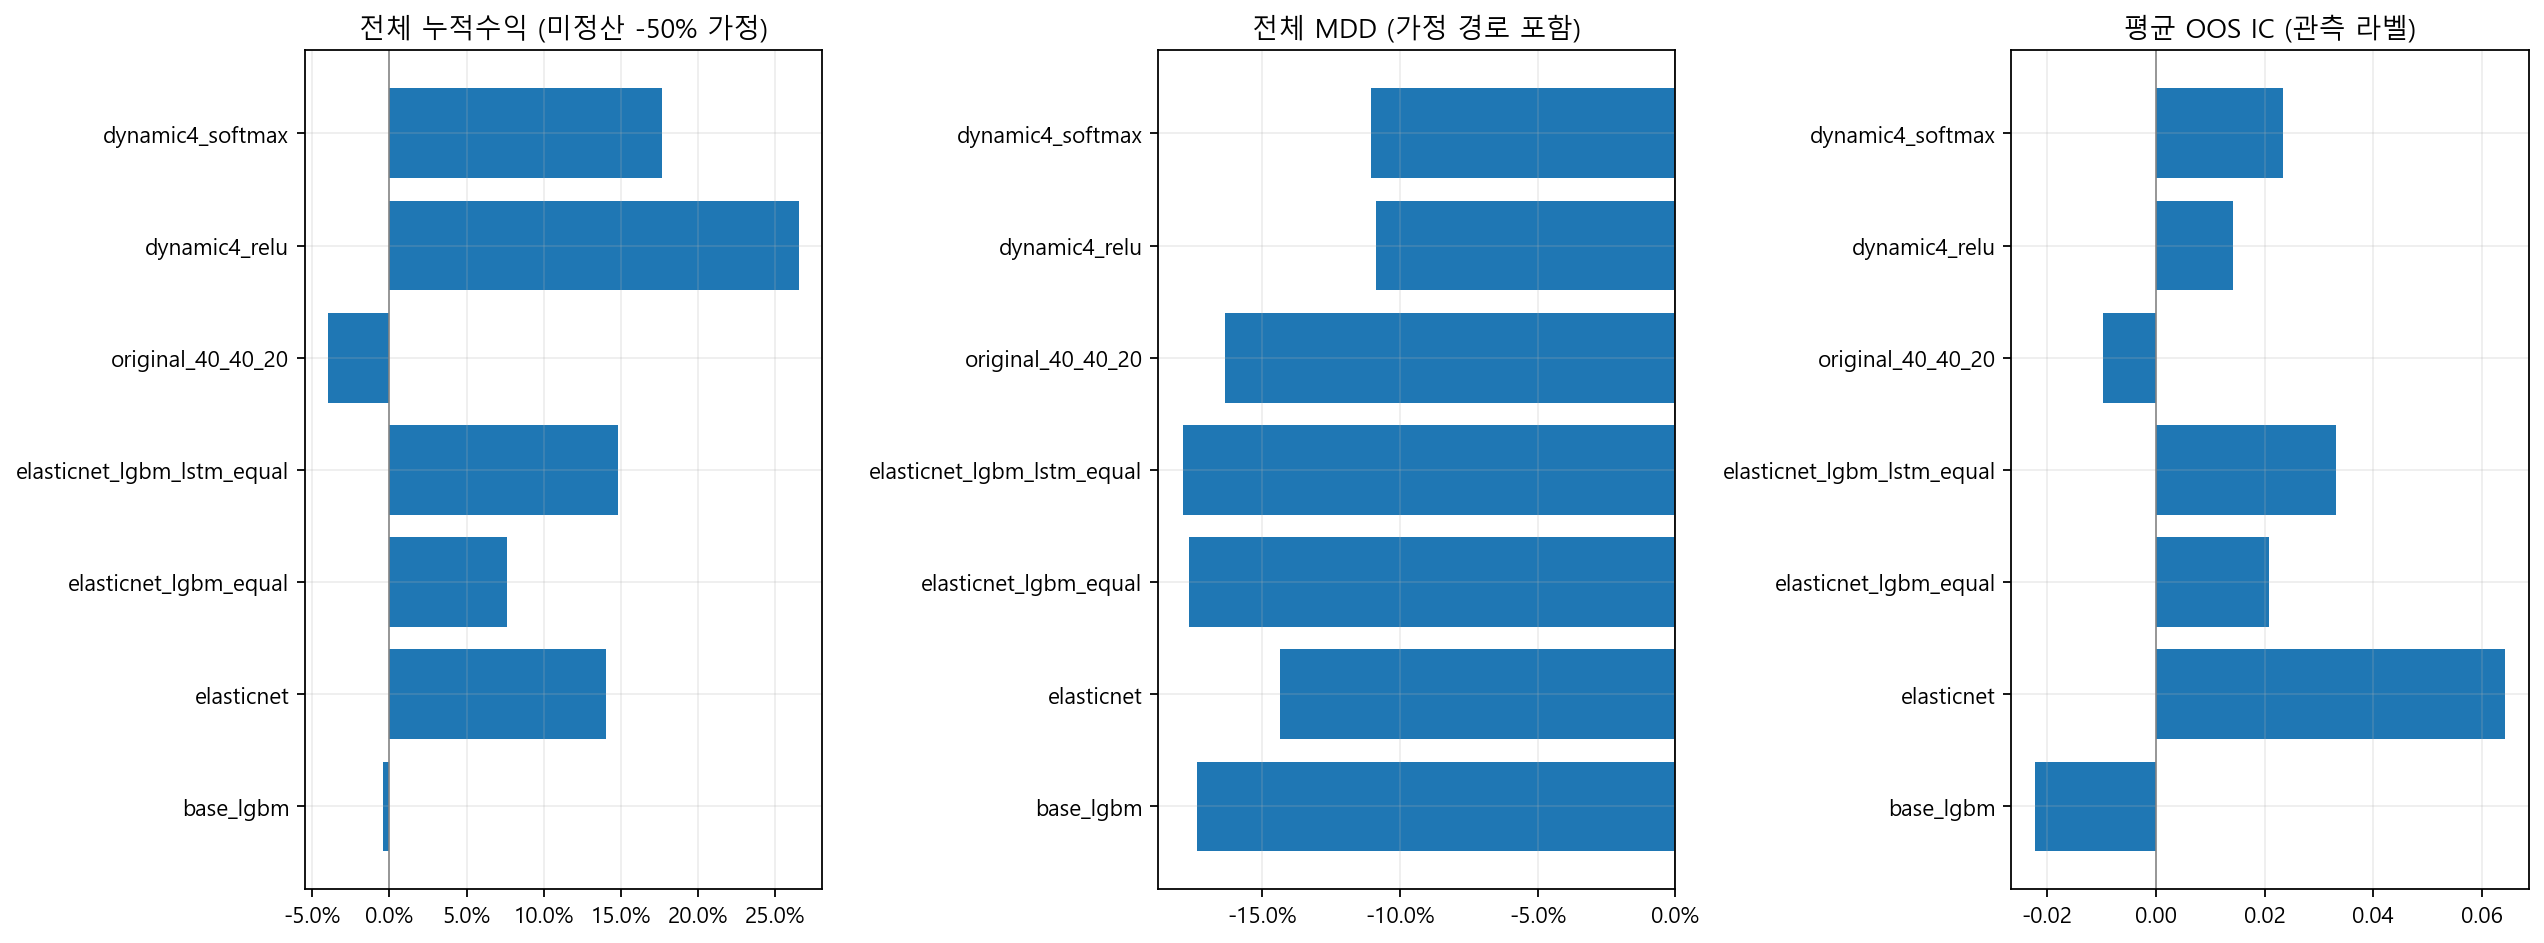

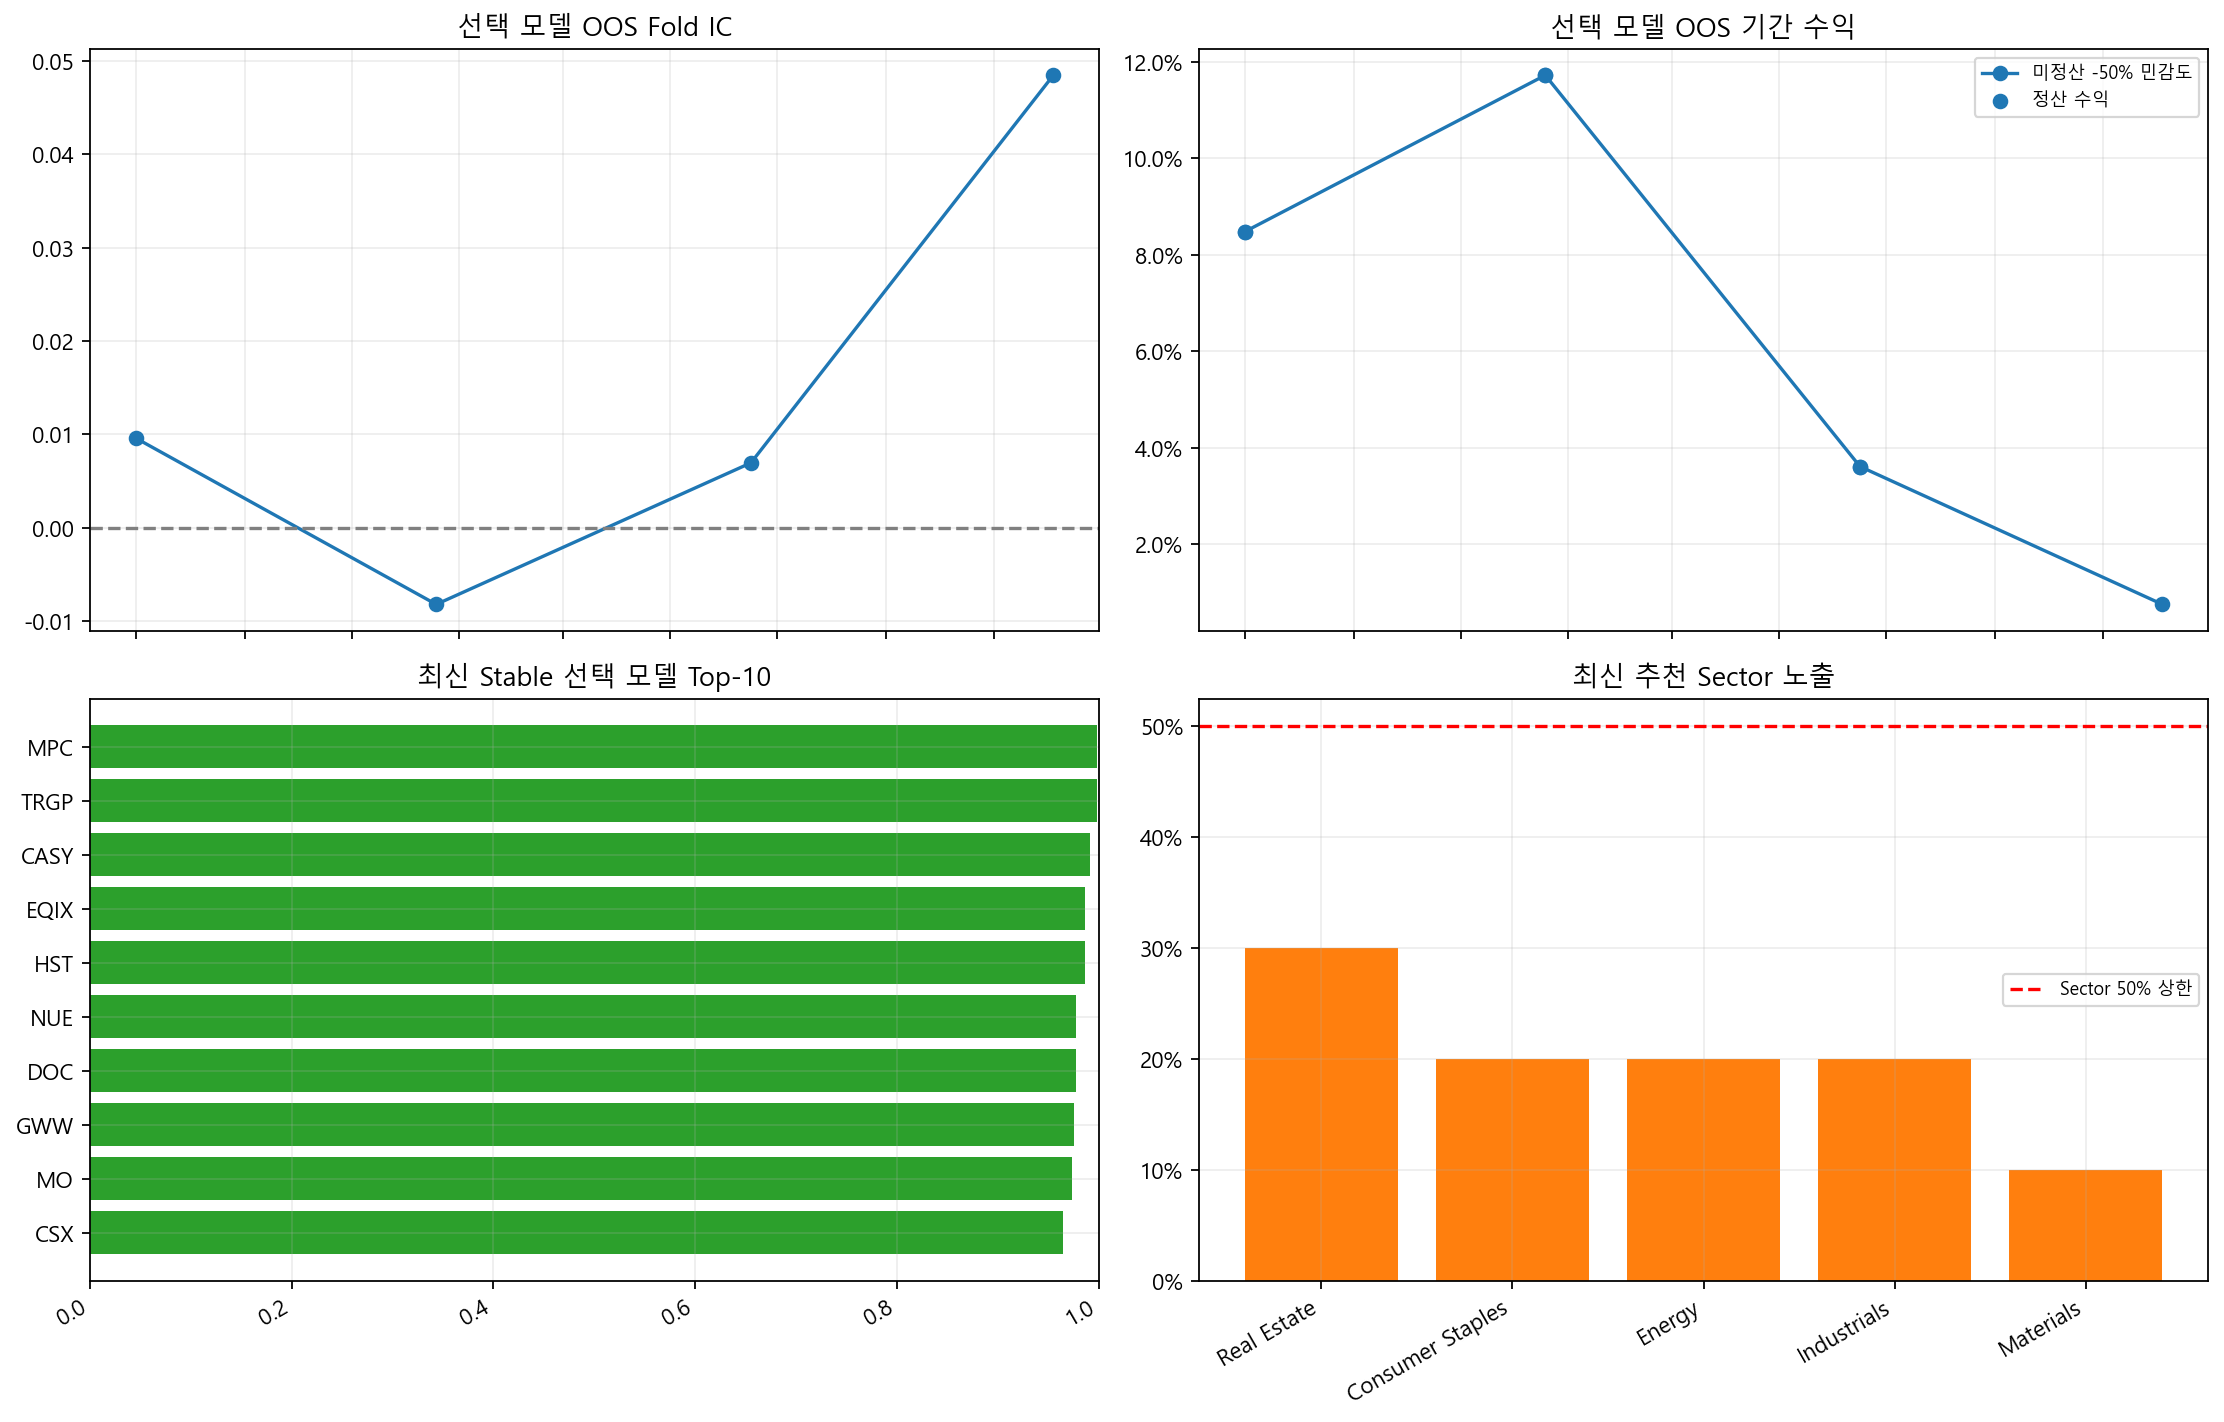

최종 비교 보고서·CSV·그래프: C:\workspaces\middle\final\outputs\20260910T115732306787Z


**모델별 과거 IC와 동적 비중**

Date,strategy,model,mean_ic,weight,history_count,latest_label_end,cash,fallback_equal
2024-07-01 00:00:00,dynamic4_relu,elasticnet,-0.0344,0.00%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_relu,mlp,0.0186,22.29%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_relu,macro,0.0251,30.10%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_relu,lstm,0.0397,47.61%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_softmax,elasticnet,-0.0344,8.63%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_softmax,mlp,0.0186,24.93%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_softmax,macro,0.0251,28.40%,3,2024-06-28 00:00:00,False,False
2024-07-01 00:00:00,dynamic4_softmax,lstm,0.0397,38.04%,3,2024-06-28 00:00:00,False,False
2024-12-19 00:00:00,dynamic4_relu,elasticnet,-0.0344,0.00%,3,2024-06-28 00:00:00,False,False
2024-12-19 00:00:00,dynamic4_relu,mlp,0.0186,22.29%,3,2024-06-28 00:00:00,False,False


**기간별 ElasticNet 대비 수익**

Date,EntryDate,ExitDate,strategy,top_n,selected,status,return_settled,mdd,missing_weight,path_coverage,assumption_flat,assumption_loss50,assumption_loss100,selection_return,selection_mdd,selection_path_status,assumed_holdings,selection_basis,cash_weight,elasticnet_return,excess_vs_elasticnet
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet,10,10,settled_path,0.1050,-0.0649,0.0000,1.0000,0.1050,0.1050,0.1050,10.50%,-0.0649,settled_path,0,observed_path,미확정 / 해당 없음,10.50%,0.00%
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,base_lgbm,10,10,settled_path,0.0391,-0.1080,0.0000,1.0000,0.0391,0.0391,0.0391,3.91%,-0.1080,settled_path,0,observed_path,미확정 / 해당 없음,10.50%,-6.59%
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet_lgbm_equal,10,10,settled_path,0.1423,-0.0827,0.0000,1.0000,0.1423,0.1423,0.1423,14.23%,-0.0827,settled_path,0,observed_path,미확정 / 해당 없음,10.50%,3.73%
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet_lgbm_lstm_equal,10,10,settled_path,0.1421,-0.0625,0.0000,1.0000,0.1421,0.1421,0.1421,14.21%,-0.0625,settled_path,0,observed_path,미확정 / 해당 없음,10.50%,3.71%
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,original_40_40_20,10,10,settled_path,0.0788,-0.0748,0.0000,1.0000,0.0788,0.0788,0.0788,7.88%,-0.0748,settled_path,0,observed_path,미확정 / 해당 없음,10.50%,-2.62%
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet,10,10,settled_path,0.0138,-0.1436,0.0000,1.0000,0.0138,0.0138,0.0138,1.38%,-0.1436,settled_path,0,observed_path,미확정 / 해당 없음,1.38%,0.00%
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,base_lgbm,10,10,settled_path,0.0533,-0.1528,0.0000,1.0000,0.0533,0.0533,0.0533,5.33%,-0.1528,settled_path,0,observed_path,미확정 / 해당 없음,1.38%,3.95%
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet_lgbm_equal,10,10,settled_path,0.0353,-0.1767,0.0000,1.0000,0.0353,0.0353,0.0353,3.53%,-0.1767,settled_path,0,observed_path,미확정 / 해당 없음,1.38%,2.15%
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet_lgbm_lstm_equal,10,10,settled_path,0.0213,-0.1789,0.0000,1.0000,0.0213,0.0213,0.0213,2.13%,-0.1789,settled_path,0,observed_path,미확정 / 해당 없음,1.38%,0.75%
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,original_40_40_20,10,10,settled_path,-0.0132,-0.1190,0.0000,1.0000,-0.0132,-0.0132,-0.0132,-1.32%,-0.1190,settled_path,0,observed_path,미확정 / 해당 없음,1.38%,-2.70%


**이전 5모델 동적 실험: 투자기간이 다른 참고 이력**

strategy,top_n,n_periods,settled_periods,path_periods,mean_period_return_available,cumulative_return,mdd,annualized_volatility,mdd_15_preference,status,observed_settled_periods,assumed_holdings,selection_basis,invested_periods,mean_ic,eligible,risk_preference_met,selected,selection_status,evaluation_role,independent_holdout,selection_scope,comparison_role
dynamic_relu,10,4,4,4,0.0037,1.40%,-12.07%,0.0920,met_observed_path,complete_path,4,0,observed_path,2,0.0567,True,True,False,exploratory_selected,exploratory_reused_oos,False,dynamic_final,historical_only_cold_start_2_of_4_periods
dynamic_softmax,10,4,4,4,0.0085,3.41%,-11.57%,0.0909,met_observed_path,complete_path,4,0,observed_path,2,0.0564,True,True,True,exploratory_selected,exploratory_reused_oos,False,dynamic_final,historical_only_cold_start_2_of_4_periods


**전체 앙상블 실험 비교: comparison_role 확인**

strategy,top_n,n_periods,settled_periods,path_periods,mean_period_return_available,cumulative_return,mdd,annualized_volatility,mdd_15_preference,status,observed_settled_periods,assumed_holdings,selection_basis,mean_ic,eligible,risk_preference_met,selected,selection_status,evaluation_role,independent_holdout,selection_scope,invested_periods,return_difference_vs_elasticnet,mdd_difference_vs_elasticnet,comparison_role
base_lgbm,10,4,4,4,0.0005,-0.41%,-17.37%,0.1661,not_met,complete_path,4,0,observed_path,-0.0223,True,False,False,exploratory_selected,exploratory_reused_oos,False,fixed_reference,4,-0.1446,-0.0301,same_four_investment_periods
elasticnet,10,4,4,4,0.0351,14.04%,-14.36%,0.1603,met_observed_path,complete_path,4,0,observed_path,0.0643,True,True,False,exploratory_selected,exploratory_reused_oos,False,fixed_reference,4,0.0000,0.0000,same_four_investment_periods
elasticnet_lgbm_equal,10,4,4,4,0.0214,7.61%,-17.67%,0.1706,not_met,complete_path,3,1,loss50_terminal_scenario,0.0209,True,False,False,exploratory_selected,exploratory_reused_oos,False,fixed_reference,4,-0.0644,-0.0332,same_four_investment_periods
elasticnet_lgbm_lstm_equal,10,4,4,4,0.0370,14.79%,-17.89%,0.1692,not_met,complete_path,4,0,observed_path,0.0331,True,False,False,exploratory_selected,exploratory_reused_oos,False,fixed_reference,4,0.0075,-0.0354,same_four_investment_periods
original_40_40_20,10,4,4,4,-0.0087,-3.96%,-16.37%,0.1470,not_met,complete_path,2,2,loss50_terminal_scenario,-0.0097,True,False,False,exploratory_selected,exploratory_reused_oos,False,fixed_reference,4,-0.1800,-0.0202,same_four_investment_periods
dynamic4_relu,10,4,4,4,0.0614,26.52%,-10.86%,0.1442,met_observed_path,complete_path,3,1,loss50_terminal_scenario,0.0142,True,True,True,exploratory_selected,exploratory_reused_oos,False,dynamic_final,4,0.1248,0.0349,same_four_investment_periods
dynamic4_softmax,10,4,4,4,0.0425,17.66%,-11.06%,0.1437,met_observed_path,complete_path,4,0,observed_path,0.0234,True,True,False,exploratory_selected,exploratory_reused_oos,False,dynamic_final,4,0.0362,0.0329,same_four_investment_periods
dynamic_relu,10,4,4,4,0.0037,1.40%,-12.07%,0.0920,met_observed_path,complete_path,4,0,observed_path,0.0567,True,True,False,exploratory_selected,exploratory_reused_oos,False,dynamic_final,2,미확정 / 해당 없음,미확정 / 해당 없음,historical_only_cold_start_2_of_4_periods
dynamic_softmax,10,4,4,4,0.0085,3.41%,-11.57%,0.0909,met_observed_path,complete_path,4,0,observed_path,0.0564,True,True,True,exploratory_selected,exploratory_reused_oos,False,dynamic_final,2,미확정 / 해당 없음,미확정 / 해당 없음,historical_only_cold_start_2_of_4_periods


In [57]:
DYNAMIC_RATIONALE = '## 4모델 동적 앙상블: 동일 투자기간 직접 비교\n\n### 구성과 비교 범위\n동적 앙상블에는 ElasticNet, MLP, Macro-LightGBM, LSTM만 사용한다. 기본 LightGBM은 동적 구성에서 제외하지만 기존 단독·고정 앙상블 실험의 비교 결과는 보존한다. 현재 4모델 ReLU·Softmax와 기존 5개 기준안을 같은 4개 신호일·진입일·청산일에서 비교한다. 이전 5모델 동적 실험은 초기 2기간 현금이었으므로 별도 역사 비교표에 표시하고 같은 투자조건의 결과로 섞지 않는다.\n\n### 첫 시점부터 투자하기 위한 IC 사전 이력\n첫 OOS 신호일보다 청산일이 앞선 과거 120거래일 구간 3개를 만든다. 각 과거 신호일 이전에 종료·확정된 라벨만으로 4개 모델을 새로 학습하고 공통 Stable 표본을 예측하여 만기 IC를 계산한다. 이는 학습 적합값이 아니라 과거 시점별 외부 예측이다. 3개 신호는 120거래일 간격이고 가장 최근 구간의 청산일은 첫 OOS 신호일 직전 거래일이다. 초기 IC 이력은 투자성과에 연결하지 않고 가중치 초기화에만 사용한다.\n\n### 동적 비중과 전 기간 투자 조건\n각 신호일의 가중치는 그날 이전에 만기된 최근 최대 3개 IC 평균으로 계산한다. ReLU는 양수 IC만 정규화하고 Softmax는 tau=0.05로 안정화된 지수 정규화를 한다. 동일 투자기간 비교를 위해 ReLU의 양수 IC 합이 0이면 사전 고정한 4모델 동일가중(각 25%)으로 대체하며 fallback_equal로 기록한다. 이 25%는 모델 비중이고 종목 비중이 아니다. 과거 IC가 결측이면 현금으로 생략하지 않고 오류를 내어 비교를 중단한다. 이는 과거 현금 대기형 ReLU와 다른 항상 투자형 정책이다.\n\n### 정산·통제·선정 규칙\nTop10 종목은 각 10%, 단일 섹터 최대 50%를 유지한다. 미래 결과 결측으로 추천 모집단을 줄이지 않는다. 미정산 또는 불완전 가격 경로 종목은 기존 함수로 초기 투자금 대비 청산일 -50%를 가정하며 중간 결측은 직전 관측값을 유지한다. 관측 정산과 가정 경로 수익·MDD를 구분한다. 날짜별 Stable 정의, 공통 피처·시퀀스 표본, 학습 라벨 마감, 체결·보유 조건은 ElasticNet 비교와 동일하다. 모든 4기간에 투자하고 전체 평가 경로가 있으며 MDD >= -15%인 동적 후보 중 누적수익 최대를 선택한다. 적격 후보가 없으면 보류하며 동률은 MDD, 평균 IC, 이름 순이다.\n\n### 결과 해석\n누적수익·MDD뿐 아니라 각 동일 보유기간의 ElasticNet 대비 수익 차이도 저장한다. 기존 모든 고정 앙상블을 같은 표에 표시한다. 동적 후보 내 선정은 전체 후보에서 최고라는 뜻이 아니며 ElasticNet을 이기지 못하면 그 사실을 그대로 보고한다. 사전 이력이 있어도 모델 구성·IC 창·방식의 사후 선택편향, 120일 정답 지연, 생존편향, 거래비용 미반영, 정산 가정은 남는다. -50%는 실제 정산의 증거나 항상 보수적인 손실 하한이 아니다.\n'
DYNAMIC_MODELS = ['elasticnet','mlp','macro','lstm']
IC_WINDOW, SOFTMAX_TAU = 3, 0.05
data_archive_root = Path(PROJECT_ROOT)/'outputs/20260910T060632303125Z'

def calculate_ic_weights(ic_dict, method='relu', tau=SOFTMAX_TAU):
    if method not in ('relu','softmax'): raise ValueError('Unknown method')
    if not np.isfinite(tau) or tau<=0: raise ValueError('Invalid tau')
    x=np.array(list(ic_dict.values()),dtype=float); valid=np.isfinite(x); w=np.zeros(len(x))
    if valid.any():
        w[valid]=np.maximum(x[valid],0) if method=='relu' else np.exp((x[valid]-x[valid].max())/tau)
        if w.sum()>0: w/=w.sum()
    return dict(zip(ic_dict,map(float,w)))

def latest_component_predictions(data,policy,signal_day=None):
    from src import profitability as pf
    from sklearn.linear_model import ElasticNet
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import RobustScaler
    import lightgbm as lgb
    d,cal,cols=protocol.make_horizon_labels(data.frame,120,1)
    macro=pf._macro_by_date(data.macro,cal)
    for c in pf.MACRO_COLS: d[c]=d.Date.map(macro[c]).astype('float32')
    d['future_price']=np.nan
    features=list(dict.fromkeys(pf.MICRO_COLS+pf.MACRO_COLS))
    latest=d.loc[d.eligible_signal,'Date'].max() if signal_day is None else pd.Timestamp(signal_day)
    cache=pf.StabilityLabelCache(data.frame,policy); bank=pf._SequenceBank(data.frame,cal)
    tr,te=pf._prepare_control_fold(d,cache,latest,cols,features)
    tr,te=bank.filter(tr),bank.filter(te)
    tr=tr.loc[np.isfinite(tr[features+[cols['target']]].to_numpy(float)).all(axis=1)]
    assert tr[cols['end']].lt(latest).all() and tr.label_available_at.lt(latest).all()
    te=te.copy(); te['Sector']=te.Ticker.map(pf._sector_map(data.sectors)).fillna('UNKNOWN')
    models={'elasticnet':(pf.BASE,make_pipeline(RobustScaler(),ElasticNet(alpha=.001,l1_ratio=.5,max_iter=5000))),
        'mlp':(pf.BASE,pf._final_ensemble_mlp()),'macro':(features,lgb.LGBMRegressor(**pf.LGBM_PARAMS,force_col_wise=True))}
    for name,(inputs,model) in models.items():
        print('Dynamic latest fit:',name,flush=True)
        with threadpool_limits(limits=4): te[name]=pf._fit_predict(tr,te,inputs,cols['target'],model)
    print('Dynamic latest fit: lstm',flush=True)
    te['lstm'],_,_=pf._fit_final_ensemble_lstm(tr,te,bank,cols['target'])
    assert np.isfinite(te[DYNAMIC_MODELS].to_numpy()).all()
    te.attrs['training_audit'] = dict(Date=latest, train_rows=len(tr), max_train_label_end=tr[cols['end']].max(), max_label_available=tr.label_available_at.max())
    return te

def run_dynamic_comparison(data,fixed,policy):
    from src import profitability as pf
    pred=fixed['profit_candidate_predictions'].copy(); pred.Date=pd.to_datetime(pred.Date)
    periods=fixed['profit_candidate_periods'].copy()
    for c in ['Date','EntryDate','ExitDate']: periods[c]=pd.to_datetime(periods[c])
    schedule=periods[['Date','EntryDate','ExitDate']].drop_duplicates().sort_values('Date')
    target='target_excess_simple_120d_next_close'; simple='target_simple_120d_next_close'
    # 첫 평가일 이전에 이미 만기된 3개 과거 외부 예측을 별도로 생성한다.
    cal=pd.DatetimeIndex(data.calendar)
    first_pos=cal.get_loc(schedule.Date.iloc[0])
    warm_positions=[first_pos-122-120*k for k in reversed(range(IC_WINDOW))]
    if min(warm_positions)<0: raise ValueError('Insufficient pre-OOS calendar for IC warm-up')
    warm_predictions=[]; warm_audit=[]; history=[]
    for pos in warm_positions:
        signal,end=cal[pos],cal[pos+121]
        assert end<schedule.Date.iloc[0]
        print('Pre-OOS IC warm-up:',signal.date(),'->',end.date(),flush=True)
        warm=latest_component_predictions(data,policy,signal)
        warm_audit.append(warm.attrs['training_audit'])
        warm_predictions.append(warm[['Date','Ticker',target,simple]+DYNAMIC_MODELS].copy())
        for model in DYNAMIC_MODELS:
            v=warm.loc[np.isfinite(warm[[model,target]].to_numpy(float)).all(axis=1)]
            ic=v[model].corr(v[target],method='spearman') if len(v)>=3 else np.nan
            history.append(dict(Date=signal,available_at=end,model=model,daily_ic=ic,n_evaluated=len(v),source='pre_oos_warmup'))
        del warm
        gc.collect()
    for row in schedule.itertuples():
        g=pred.loc[pred.Date.eq(row.Date)]
        for model in DYNAMIC_MODELS:
            v=g.loc[np.isfinite(g[[model,target]].to_numpy(float)).all(axis=1)]
            ic=v[model].corr(v[target],method='spearman') if len(v)>=3 else np.nan
            history.append(dict(Date=row.Date,available_at=row.ExitDate,model=model,daily_ic=ic,n_evaluated=len(v),source='evaluation_oos'))
    history=pd.DataFrame(history); weights_log=[]
    def at(day,method):
        past=history.loc[history.available_at.lt(day)]
        recent=past.Date.drop_duplicates().sort_values().tail(IC_WINDOW)
        past=past.loc[past.Date.isin(recent)]
        means=past.groupby('model').daily_ic.mean().reindex(DYNAMIC_MODELS)
        if not np.isfinite(means.to_numpy()).all():
            raise ValueError(f'Incomplete past IC history at {day}; do not silently shorten investment period')
        weights=calculate_ic_weights(means.to_dict(),method)
        fallback=sum(weights.values())==0
        if fallback:
            # 항상 투자하는 비교 설계: ReLU가 모두 0이면 사전 고정 1/4씩 배분.
            weights={m:1/len(DYNAMIC_MODELS) for m in DYNAMIC_MODELS}
        for model in DYNAMIC_MODELS:
            h=past.loc[past.model.eq(model)&past.daily_ic.notna()]
            weights_log.append(dict(Date=day,strategy='dynamic4_'+method,model=model,mean_ic=means[model],
                weight=weights[model],history_count=len(h),latest_label_end=h.available_at.max(),cash=False,fallback_equal=fallback))
        assert past.empty or past.available_at.max()<day
        return weights
    cal=pd.DatetimeIndex(data.calendar); prices=data.frame.pivot(index='Date',columns='Ticker',values='Close')
    mapping=pf._sector_map(data.sectors); stats=[]; metrics=[]; holdings=[]; paths={}
    for row in schedule.itertuples():
        g=pred.loc[pred.Date.eq(row.Date)].copy(); g['Sector']=g.Ticker.map(mapping).fillna('UNKNOWN'); g['stable']=True
        ranks=g[DYNAMIC_MODELS].rank(pct=True)
        for method in ['relu','softmax']:
            name='dynamic4_'+method; weights=at(row.Date,method); cash=sum(weights.values())==0
            if cash:
                wealth=pd.Series(1.,index=cal[(cal>=row.EntryDate)&(cal<=row.ExitDate)])
                stat=dict(selected=0,status='cash',return_settled=0.,mdd=0.,missing_weight=0.,selection_return=0.,
                    selection_mdd=0.,selection_path_status='settled_path',assumed_holdings=0,selection_basis='cash_zero_interest')
                rep={'daily_ic':np.nan}
            else:
                g['pred']=sum(ranks[m]*weights[m] for m in DYNAMIC_MODELS)
                rep,_,_=pf.qv.evaluation(g,'pred',target)
                picked=pf._choose_top(g,'pred',10).copy()
                stat,wealth=candidate_module.settle_with_loss50(picked,cal,prices,row.EntryDate,row.ExitDate,simple,10)
                picked['strategy']=name; picked['weight']=.1; holdings.append(picked)
            stats.append(dict(Date=row.Date,EntryDate=row.EntryDate,ExitDate=row.ExitDate,strategy=name,top_n=10,cash_weight=float(cash),**stat))
            metrics.append(dict(Date=row.Date,strategy=name,**rep))
            if wealth is not None: paths[(name,10,row.Date)]=wealth
    stats=pd.DataFrame(stats); metrics=pd.DataFrame(metrics)
    summary=candidate_module.summarize_selection(stats,paths)
    summary['invested_periods']=summary.strategy.map(stats.groupby('strategy').cash_weight.apply(lambda x:int(x.eq(0).sum())))
    summary.loc[summary.invested_periods.ne(len(schedule)),'status']='investment_period_mismatch'
    summary,winner=candidate_module.select_candidate(summary,metrics,len(schedule))
    latest=data.frame.loc[data.frame.eligible_signal,'Date'].max()
    live={m:at(latest,m) for m in ['relu','softmax']}; recommendation=pd.DataFrame()
    if winner and sum(live[winner.replace('dynamic4_','')].values())>0:
        te=latest_component_predictions(data,policy); weights=live[winner.replace('dynamic4_','')]
        te['pred']=sum(te[m].rank(pct=True)*weights[m] for m in DYNAMIC_MODELS)
        recommendation=pf._choose_top(te,'pred',10).copy()
        recommendation['strategy']=winner; recommendation['weight']=.1
        recommendation['signal_date']=latest; recommendation['recommendation_status']='unsettled_live_signal'
        del te
    rule=pd.DataFrame([dict(selected_strategy=winner or 'NONE',status='exploratory_selected' if winner else 'selection_deferred',
        latest_signal=latest,latest_cash=recommendation.empty,ic_window=IC_WINDOW,tau=SOFTMAX_TAU,
        evaluation_role='exploratory_reused_oos',independent_holdout=False,
        rule='Dynamic4 only: complete paths, all four periods invested, MDD >= -15%, max return; ties MDD/IC/name')])
    baseline=fixed['profit_candidate_summary'].copy(); baseline['selected']=False; baseline['selection_scope']='fixed_reference'
    baseline['invested_periods']=baseline.n_periods
    summary['selection_scope']='dynamic_final'; combined=pd.concat([baseline,summary],ignore_index=True)
    h=pd.concat(holdings,ignore_index=True) if holdings else pd.DataFrame(columns=['strategy'])
    result=dict(fixed)
    result.update(profit_candidate_summary=combined,profit_candidate_selection=rule,
        profit_candidate_metrics=pd.concat([fixed['profit_candidate_metrics'],metrics],ignore_index=True),
        profit_candidate_periods=pd.concat([periods,stats],ignore_index=True),
        dynamic_warmup_predictions=pd.concat(warm_predictions,ignore_index=True),dynamic_warmup_audit=pd.DataFrame(warm_audit),
        dynamic_model_ic_history=history,dynamic_weights=pd.DataFrame(weights_log),dynamic_summary=summary,dynamic_holdings=h,
        profit_final_ensemble_protocol=rule,profit_final_ensemble_summary=summary.loc[summary.selected],
        profit_final_ensemble_metrics=metrics.loc[metrics.strategy.eq(winner)],profit_final_ensemble_periods=stats.loc[stats.strategy.eq(winner)],
        profit_final_ensemble_holdings=h.loc[h.strategy.eq(winner)],profit_final_ensemble_recommendation=recommendation,
        profit_final_ensemble_sector_exposure=recommendation.groupby('Sector',as_index=False).weight.sum() if len(recommendation) else pd.DataFrame(columns=['Sector','weight']))
    # 기간별 ElasticNet과 직접 차이를 비교한다. 같은 진입·청산일인지 검사한다.
    comparison=result['profit_candidate_periods'].copy()
    reference=comparison.loc[comparison.strategy.eq('elasticnet'),['Date','EntryDate','ExitDate','selection_return']].rename(columns={'selection_return':'elasticnet_return'})
    paired=comparison.merge(reference,on=['Date','EntryDate','ExitDate'],how='left',validate='many_to_one')
    assert paired.elasticnet_return.notna().all()
    paired['excess_vs_elasticnet']=paired.selection_return-paired.elasticnet_return
    result['ensemble_vs_elasticnet_periods']=paired
    reference_summary=baseline.loc[baseline.strategy.eq('elasticnet')].iloc[0]
    combined['return_difference_vs_elasticnet']=combined.cumulative_return-reference_summary.cumulative_return
    combined['mdd_difference_vs_elasticnet']=combined.mdd-reference_summary.mdd
    result['profit_candidate_summary']=combined
    # 이전 5모델 cold-start 동적 실험은 동일투자 비교가 아닌 이력으로 별도 보존.
    archive=Path(data_archive_root)/'tables/dynamic_summary.csv'
    if archive.exists():
        historical=pd.read_csv(archive)
        archive_manifest=json.loads((Path(data_archive_root)/'manifest.json').read_text(encoding='utf-8'))
        if archive_manifest.get('input_sha256')!=data.input_hashes: raise ValueError('Historical comparison input hashes differ')
        historical['comparison_role']='historical_only_cold_start_2_of_4_periods'
        result['historical_dynamic5_comparison']=historical
        result['all_ensemble_experiment_comparison']=pd.concat([combined.assign(comparison_role='same_four_investment_periods'),historical],ignore_index=True)
    gc.collect()
    return result

# 모듈화된 실행과 동일한 데이터·Stable·후보 비교·-50% 정산 가정
import gc
import importlib
from src.config import ProjectConfig
from src.data_pipeline import load_analysis_data
from src.stability import StabilityPolicy
from src import candidate_comparison as candidate_module
from src.reporting import save_run
importlib.reload(candidate_module)
gc.collect()
final_config = ProjectConfig.discover()
final_policy = StabilityPolicy()
final_data = load_analysis_data(final_config)
try:
    FINAL_RESULTS = candidate_module.run_comparison(
        final_data.frame, final_data.calendar, final_data.sectors,
        final_data.macro, final_policy)
    FINAL_RESULTS = run_dynamic_comparison(final_data, FINAL_RESULTS, final_policy)
    FINAL_INPUT_HASHES = final_data.input_hashes.copy()
finally:
    del final_data
    gc.collect()
TABLES.update(FINAL_RESULTS)
for name in ['candidate_comparison.py','profitability.py','data_pipeline.py','stability.py']:
    SOURCE_HASHES[name] = rd.fingerprint(PROJECT_ROOT/'src'/name)
SOURCE_HASHES['test_validation_report.ipynb'] = rd.fingerprint(PROJECT_ROOT/'test_validation_report.ipynb')
final_top10 = FINAL_RESULTS['profit_final_ensemble_recommendation']
ensemble_summary = FINAL_RESULTS['profit_final_ensemble_summary']
ensemble_periods_df = FINAL_RESULTS['profit_final_ensemble_periods']
show('고정 5개 및 동적 2개 비교: 미정산 -50% 가정 포함',
     FINAL_RESULTS['profit_candidate_summary'], percent=['cumulative_return','mdd'])
show('선정 규칙 및 결과', FINAL_RESULTS['profit_candidate_selection'])
show('최신 추천 (미정산 실시간 신호)', final_top10, percent=['weight'])
show('선택 모델 섹터 노출', FINAL_RESULTS['profit_final_ensemble_sector_exposure'], percent=['weight'])
FINAL_RUN_DIR = save_run(final_config, final_policy, FINAL_RESULTS, {
    'run_scope': 'notebook_dynamic_candidate_comparison',
    'input_sha256': FINAL_INPUT_HASHES, 'source_sha256': SOURCE_HASHES,
    'evaluation_role': 'exploratory_reused_oos',
    'missing_settlement_policy': 'loss50_terminal_scenario'})
from IPython.display import Image
for filename in ['figure_8_candidate_comparison.png','figure_7_final_ensemble.png']:
    figure_path = FINAL_RUN_DIR/'figures'/filename
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
print('최종 비교 보고서·CSV·그래프:', FINAL_RUN_DIR)

show('모델별 과거 IC와 동적 비중',FINAL_RESULTS['dynamic_weights'],percent=['weight'])
text_report='# 동적 앙상블 비교 보고서\n\n'+DYNAMIC_RATIONALE+'\n\n'
for title,key in [('7개 후보 비교','profit_candidate_summary'),('동적 최종 선정','profit_candidate_selection'),('시점별 모델 비중','dynamic_weights'),('기간별 ElasticNet 직접 비교','ensemble_vs_elasticnet_periods')]:
    text_report+='## '+title+'\n\n```text\n'+FINAL_RESULTS[key].to_string(index=False)+'\n```\n\n'
text_report+='![후보 비교](figures/figure_8_candidate_comparison.png)\n'
(FINAL_RUN_DIR/'UNIFIED_VALIDATION_REPORT.md').write_text(text_report,encoding='utf-8')

show("기간별 ElasticNet 대비 수익",FINAL_RESULTS["ensemble_vs_elasticnet_periods"],percent=["selection_return","elasticnet_return","excess_vs_elasticnet"])
if "historical_dynamic5_comparison" in FINAL_RESULTS:
    show("이전 5모델 동적 실험: 투자기간이 다른 참고 이력",FINAL_RESULTS["historical_dynamic5_comparison"],percent=["cumulative_return","mdd"])
    show("전체 앙상블 실험 비교: comparison_role 확인",FINAL_RESULTS["all_ensemble_experiment_comparison"],percent=["cumulative_return","mdd"])
    text_report+='\n## 전체 실험 이력 (투자기간 차이 주의)\n\n```text\n'+FINAL_RESULTS['all_ensemble_experiment_comparison'].to_string(index=False)+'\n```\n'
    (FINAL_RUN_DIR/'UNIFIED_VALIDATION_REPORT.md').write_text(text_report,encoding='utf-8')


## 현재 추천 종목의 과거수익 역추적 제외

2026-06-30 현재 정보로 선정한 `final_top10`의 직전 120거래일 수익률은 최종 모델의 OOS 성능으로 사용하지 않는다. 현재 시점의 모멘텀 정보로 종목을 고른 뒤 같은 과거 구간의 수익을 평가하면 사후 선택 편향이 생기기 때문이다.

최종 성능 평가는 반드시 과거 신호일에 당시 이용 가능했던 데이터만으로 종목을 먼저 선택한 후, 다음 거래일부터 120거래일 동안의 미래 경로를 정산하는 walk-forward 결과만 사용한다. 현재 추천은 **미정산 실시간 신호**이며, 독립 확증 검증은 2026-06-30 이후 새 데이터가 확보된 뒤 수행한다.


## 동일 4개 OOS 기간 직접 비교
아래는 위 공통 비교에서 생성된 기간별 결과다. 기존 고정 40/40/20의 별도 마지막 만기 구간 재학습 셀은 이 비교표로 대체한다. 서로 다른 신호일의 성과를 같은 비교로 혼합하지 않는다.


In [58]:
show('후보별 기간 정산: 실제값과 -50% 가정값 분리',
     FINAL_RESULTS['profit_candidate_periods'],
     percent=['return_settled','mdd','selection_return','selection_mdd','missing_weight'])
show('후보별 관측 라벨 IC', FINAL_RESULTS['profit_candidate_metrics'])
show('학습 라벨 시점 감사', FINAL_RESULTS['profit_candidate_audit'])
selection = FINAL_RESULTS['profit_candidate_selection'].iloc[0]
if selection['status'] == 'selection_deferred':
    display(Markdown('위험 조건을 충족하는 후보가 없어 선정을 보류합니다.'))
else:
    winner = FINAL_RESULTS['profit_candidate_summary'].loc[lambda x: x.selected].iloc[0]
    display(Markdown(
        f"선택 후보: **{winner['strategy']}** — 누적수익 {winner['cumulative_return']:.2%}, "
        f"MDD {winner['mdd']:.2%}. 미정산 -50% 가정을 포함한 위험 제약하의 탐색적 선정이며 독립 검증이 아닙니다."))
gc.collect()


**후보별 기간 정산: 실제값과 -50% 가정값 분리**

Date,EntryDate,ExitDate,strategy,top_n,selected,status,return_settled,mdd,missing_weight,path_coverage,assumption_flat,assumption_loss50,assumption_loss100,selection_return,selection_mdd,selection_path_status,assumed_holdings,selection_basis,cash_weight
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet,10,10,settled_path,10.50%,-6.49%,0.00%,1.0000,0.1050,0.1050,0.1050,10.50%,-6.49%,settled_path,0,observed_path,미확정 / 해당 없음
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,base_lgbm,10,10,settled_path,3.91%,-10.80%,0.00%,1.0000,0.0391,0.0391,0.0391,3.91%,-10.80%,settled_path,0,observed_path,미확정 / 해당 없음
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet_lgbm_equal,10,10,settled_path,14.23%,-8.27%,0.00%,1.0000,0.1423,0.1423,0.1423,14.23%,-8.27%,settled_path,0,observed_path,미확정 / 해당 없음
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,elasticnet_lgbm_lstm_equal,10,10,settled_path,14.21%,-6.25%,0.00%,1.0000,0.1421,0.1421,0.1421,14.21%,-6.25%,settled_path,0,observed_path,미확정 / 해당 없음
2024-07-01 00:00:00,2024-07-02 00:00:00,2024-12-20 00:00:00,original_40_40_20,10,10,settled_path,7.88%,-7.48%,0.00%,1.0000,0.0788,0.0788,0.0788,7.88%,-7.48%,settled_path,0,observed_path,미확정 / 해당 없음
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet,10,10,settled_path,1.38%,-14.36%,0.00%,1.0000,0.0138,0.0138,0.0138,1.38%,-14.36%,settled_path,0,observed_path,미확정 / 해당 없음
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,base_lgbm,10,10,settled_path,5.33%,-15.28%,0.00%,1.0000,0.0533,0.0533,0.0533,5.33%,-15.28%,settled_path,0,observed_path,미확정 / 해당 없음
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet_lgbm_equal,10,10,settled_path,3.53%,-17.67%,0.00%,1.0000,0.0353,0.0353,0.0353,3.53%,-17.67%,settled_path,0,observed_path,미확정 / 해당 없음
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,elasticnet_lgbm_lstm_equal,10,10,settled_path,2.13%,-17.89%,0.00%,1.0000,0.0213,0.0213,0.0213,2.13%,-17.89%,settled_path,0,observed_path,미확정 / 해당 없음
2024-12-19 00:00:00,2024-12-20 00:00:00,2025-06-17 00:00:00,original_40_40_20,10,10,settled_path,-1.32%,-11.90%,0.00%,1.0000,-0.0132,-0.0132,-0.0132,-1.32%,-11.90%,settled_path,0,observed_path,미확정 / 해당 없음


**후보별 관측 라벨 IC**

Date,fold,strategy,daily_ic,ic_std,ic_ir,hit_rate,q_spread,q_spread_available,q_spread_settled_days,overall_ic,n_days,n_obs,n_input,n_missing_evaluation,evaluation_coverage
2024-07-01 00:00:00,1.0000,elasticnet,0.1187,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,0.0654,0.0654,1,0.1187,1,348,350,2,0.9943
2024-07-01 00:00:00,1.0000,base_lgbm,-0.0848,미확정 / 해당 없음,미확정 / 해당 없음,0.0000,미확정 / 해당 없음,-0.0369,0,-0.0848,1,348,350,2,0.9943
2024-07-01 00:00:00,1.0000,elasticnet_lgbm_equal,0.0124,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,미확정 / 해당 없음,-0.0063,0,0.0124,1,348,350,2,0.9943
2024-07-01 00:00:00,1.0000,elasticnet_lgbm_lstm_equal,0.0292,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,미확정 / 해당 없음,0.0164,0,0.0292,1,348,350,2,0.9943
2024-07-01 00:00:00,1.0000,original_40_40_20,-0.0121,미확정 / 해당 없음,미확정 / 해당 없음,0.0000,미확정 / 해당 없음,-0.0063,0,-0.0121,1,348,350,2,0.9943
2024-12-19 00:00:00,2.0000,elasticnet,0.0059,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,-0.0208,-0.0208,1,0.0059,1,364,364,0,1.0000
2024-12-19 00:00:00,2.0000,base_lgbm,0.0254,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,0.0233,0.0233,1,0.0254,1,364,364,0,1.0000
2024-12-19 00:00:00,2.0000,elasticnet_lgbm_equal,0.0158,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,-0.0058,-0.0058,1,0.0158,1,364,364,0,1.0000
2024-12-19 00:00:00,2.0000,elasticnet_lgbm_lstm_equal,0.0081,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,-0.0027,-0.0027,1,0.0081,1,364,364,0,1.0000
2024-12-19 00:00:00,2.0000,original_40_40_20,0.0019,미확정 / 해당 없음,미확정 / 해당 없음,1.0000,0.0033,0.0033,1,0.0019,1,364,364,0,1.0000


**학습 라벨 시점 감사**

Date,train_rows,candidates,max_train_label_end,max_label_available,selected_epochs,inner_train_rows,inner_validation_rows,inner_validation_start,inner_max_label_end
2024-07-01 00:00:00,72657,350,2024-06-24 00:00:00,2024-06-24 00:00:00,3,56958,10785,2022-12-28 00:00:00,2022-12-22 00:00:00
2024-12-19 00:00:00,79392,364,2024-12-12 00:00:00,2024-12-12 00:00:00,2,61872,13354,2023-06-21 00:00:00,2023-06-16 00:00:00
2025-06-16 00:00:00,86481,236,2025-06-09 00:00:00,2025-06-09 00:00:00,3,66038,14546,2023-12-11 00:00:00,2023-12-07 00:00:00
2025-12-05 00:00:00,93831,254,2025-11-28 00:00:00,2025-11-28 00:00:00,1,71935,15444,2024-06-06 00:00:00,2024-05-31 00:00:00


선택 후보: **dynamic4_relu** — 누적수익 26.52%, MDD -10.86%. 미정산 -50% 가정을 포함한 위험 제약하의 탐색적 선정이며 독립 검증이 아닙니다.

26362

### 동일기간 실행 결과 및 선정 이유 — 2026-09-10 실행 스냅샷

`outputs/20260910T061640997206Z`에 저장한 결과다. 이후 재실행하면 위 코드의 최신 출력이 우선한다. 데이터 신호 기준일은 2026-06-30이다.

| 후보 | 누적수익률 | MDD | 투자 기간 |
|---|---:|---:|---:|
| ElasticNet 단독 | 14.04% | -14.36% | 4/4 |
| 기본 LightGBM 단독 | -0.41% | -17.37% | 4/4 |
| ElasticNet+LightGBM 동일가중 | 7.61% | -17.67% | 4/4 |
| ElasticNet+LightGBM+LSTM 동일가중 | 14.79% | -17.89% | 4/4 |
| 기존 MLP/Macro/LSTM 40/40/20 | -3.96% | -16.38% | 4/4 |
| **4모델 동적 ReLU** | **26.52%** | **-10.86%** | **4/4** |
| 4모델 동적 Softmax | 17.66% | -11.06% | 4/4 |

두 동적 방식 모두 낙폭 조건을 충족했고 ReLU의 누적수익이 더 높아 선택됐다. 이 실행에서 ReLU는 ElasticNet보다 누적수익이 약 12.48%p 높고 최대낙폭도 약 3.49%p 작았다. 이는 같은 표본에서의 관측 비교이지 독립 검증이나 유의성 증명이 아니다.

최신 ReLU 모델 비중은 ElasticNet 48.15%, LSTM 51.85%, MLP와 Macro-LightGBM은 0%다. 최근 IC가 음수인 모델은 ReLU 규칙으로 제외된 것이며 두 모델을 영구적으로 배제한 것이 아니다. 이번 실행에서는 동일가중 fallback이 발생하지 않았다. 추천 종목 비중은 모델 비중과 별개로 각 10%다.

이전 5모델 동적 Softmax 3.41%·ReLU 1.40%는 초기 두 기간 현금 대기 결과다. 현재 실험과 조건이 달라 역사 비교표에 별도로 저장했다. 새로운 사전 IC 구간은 2023-01-20, 2023-07-14, 2024-01-04 신호이며 모두 첫 OOS 전에 만기됐다.

입력 해시가 같은 기존 고정 후보 예측을 재사용했고 사전 IC용 모델과 최신 추천 모델은 재학습했다. 4모델 구성, 모든 가중치 합계 1, 과거 IC 만기일 < 신호일, 사전 학습 라벨 마감, 동일한 4개 투자기간, 28개 후보-기간 비교, 최신 Top10 및 섹터 상한을 검사했다. 노트북 전체 가설 실험을 재실행한 것은 아니다.


# 재현 방법과 산출물

이 노트북을 지정 프로젝트에서 커널 재시작 후 전체 실행한다. 코드는 기존 데이터와 모듈을 읽고 실행별 폴더에 표·그림·설정·추천 목록을 저장한다. 추가 통제 함수는 노트북 안에 포함되어 별도 새 모듈 설치가 필요하지 않다.

실험 설정은 데이터와 결과를 보기 전에 이번 실행에서 고정했지만 연구 자체는 기존 평가기간을 확인한 뒤 설계한 탐색 연구다. 새로운 최종 홀드아웃은 아니다. 보고서의 성공 기준은 검증 가능한 비교와 한계를 투명하게 보여주는 것이며, ‘안전한 최대 수익’의 보장이 아니다.
전체 실행 산출물은 최종 비교 셀에서 생성한 `outputs/<실행시각>/` 한 곳에 모은다. CSV는 `tables/`, 그림은 `figures/`에 저장하며 노트북 그림은 `notebook_figure_` 접두사로 공통 모듈 그림과 구분한다. `UNIFIED_VALIDATION_REPORT.md`는 최종 비교 보고서이고, 앞선 가설 해석은 이 노트북과 함께 읽는다. `VALIDATION_OUTPUT_DIR`를 지정하면 두 저장 단계에 같은 경로가 적용된다. 기존 `validation_runs/` 결과는 보존한다.


In [59]:
from datetime import datetime,timezone
from importlib.metadata import version
# 최종 비교 셀에서 만든 실행 폴더를 재사용한다. 별도 실행 폴더를 만들지 않는다.
if 'FINAL_RUN_DIR' not in globals():
    raise RuntimeError('최종 후보 비교 셀을 먼저 실행하세요.')
RUN_DIR=Path(FINAL_RUN_DIR)
TABLE_DIR=RUN_DIR/'tables'
FIGURE_DIR=RUN_DIR/'figures'
TABLE_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
for name,table in TABLES.items():table.to_csv(TABLE_DIR/f'{name}.csv',index=False,encoding='utf-8-sig')
for i,fig in enumerate(FIGURES,1):fig.savefig(FIGURE_DIR/f'notebook_figure_{i}.png',dpi=130,bbox_inches='tight')
for h,r in BY_HORIZON.items():
    for key in ['periods','holdings','fold_log']:r[key].to_csv(TABLE_DIR/f'h{h}_{key}.csv',index=False,encoding='utf-8-sig')
CONTROLS['holdings'].to_csv(TABLE_DIR/'controlled_holdings.csv',index=False,encoding='utf-8-sig')
CONTROLS['predictions'].to_csv(TABLE_DIR/'controlled_predictions.csv',index=False,encoding='utf-8-sig')
metadata={'project_root':str(PROJECT_ROOT),'input_sha256':INPUT_HASHES,'source_sha256':SOURCE_HASHES,
    'horizons':[20,60,120],'fixed_parameters':PARAMS,'common_ablation_features':COMMON,
    'cv_years':[2020,2021,2022],'cv_direction':CONTROLS['direction'],
    'h3_3_features':CONTROLS['direction_features'],
    'elasticnet_settings':{'alpha':.001,'l1_ratio':.5,'max_iter':5000,'tol':1e-5},
    'python':sys.version,'packages':{p:version(p) for p in ['numpy','pandas','scikit-learn','lightgbm','torch','yfinance']},
    'lstm_settings':{'lookback':20,'features':BASE,'hidden':32,'layers':2,'max_epochs':12,'patience':3,'seed':42},
    'macro_features':MACRO_COLS,'macro_lag_sessions':1,'missing_holding_return_assumption':-.5,
    'limitations':['reused_OOS','missing_settlements','static_sectors','price_vs_adjusted_benchmark']}
for tag,result in [('macro',MACRO_RESULT),('lstm',LSTM_RESULT)]:
    result['holdings'].to_csv(TABLE_DIR/f'{tag}_holdings.csv',index=False,encoding='utf-8-sig')
# 공통 모듈의 manifest를 보존하고 노트북 실험 설정을 별도 항목으로 추가한다.
manifest=json.loads((RUN_DIR/'manifest.json').read_text(encoding='utf-8'))
manifest['run_scope']='notebook_full_validation'
manifest['notebook_experiments']=metadata
manifest['figure_files']=sorted(str(p.relative_to(RUN_DIR)).replace('\\','/') for p in FIGURE_DIR.glob('*.png'))
manifest['table_files']=sorted(str(p.relative_to(RUN_DIR)).replace('\\','/') for p in TABLE_DIR.glob('*.csv'))
(RUN_DIR/'manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
(RUN_DIR/'SUCCESS.txt').write_text('Notebook experiments and final comparison saved together; not a claim of significant alpha.',encoding='utf-8')
print('전체 실험 및 최종 비교 산출물:',RUN_DIR)


전체 실험 및 최종 비교 산출물: C:\workspaces\middle\final\outputs\20260910T115732306787Z


In [60]:
# 최종 추천 종목 확인 (이전 셀의 지역 학습 변수 tr에 의존하지 않음)
final_top10.get('Ticker', pd.Series(dtype=str)).unique()


array(['MPC', 'TRGP', 'CASY', 'EQIX', 'HST', 'NUE', 'DOC', 'GWW', 'MO',
       'CSX'], dtype=object)

In [61]:
final_top10.columns

Index(['Date', 'Ticker', 'Close', 'eligible_signal', 'label_available_at',
       'target_entry_120d_next_close', 'target_end_120d_next_close',
       'target_excess_simple_120d_next_close', 'target_simple_120d_next_close',
       'future_price', 'momentum_252d', 'beta_120d', 'ma_gap_120d',
       'momentum_120d', 'relative_momentum_120d', 'rsi_56d',
       'downside_vol_120d', 'sortino_120d', 'Yield_Curve_Spread',
       'Yield_Curve_Change_20d', 'VIX_Level', 'VIX_Change_20d', 'DXY_Ret_60d',
       'Oil_Ret_60d', 'HYG_Ret_60d', 'risk_rank', 'stability_group', 'stable',
       'Sector', 'elasticnet', 'mlp', 'macro', 'lstm', 'pred', 'strategy',
       'weight', 'signal_date', 'recommendation_status'],
      dtype='object')

In [62]:
RESULT_LIST = ['Ticker', 'Close', 'future_price', 'momentum_252d', 'beta_120d', 'ma_gap_120d',
       'momentum_120d', 'relative_momentum_120d', 'rsi_56d',
       'downside_vol_120d', 'sortino_120d', 'Yield_Curve_Spread',
       'Yield_Curve_Change_20d', 'VIX_Level', 'VIX_Change_20d', 'DXY_Ret_60d',
       'Oil_Ret_60d', 'HYG_Ret_60d', 'risk_rank', 'stability_group', 'stable',
       'Sector', 'pred', 'strategy', 'weight', 'signal_date',
       'recommendation_status', 'holding_horizon_trading_days',
       'intended_entry']

In [63]:
import numpy as np
import pandas as pd

def calculate_ic_weights(ic_dict: dict[str, float], method: str = "relu") -> dict[str, float]:
    """
    각 모델의 최근 IC를 바탕으로 앙상블 가중치를 산출합니다.
    
    Parameters:
    - ic_dict: {'model_name': mean_ic_value} 형태의 딕셔너리
    - method: 'relu' (음수 배제) 또는 'softmax' (연속형 축소)
    """
    models = list(ic_dict.keys())
    ics = np.array([ic_dict[m] for m in models], dtype=np.float64)

    if method == "relu":
        # 1) IC가 0 이하인 모델은 가중치를 0으로 클리핑
        pos_ics = np.maximum(0.0, ics)
        total = np.sum(pos_ics)
        
        # 모든 모델의 IC가 음수일 경우 예외 처리 (현금화 신호로 활용 가능)
        if total == 0:
            return {m: 0.0 for m in models}
        weights = pos_ics / total

    elif method == "softmax":
        # 2) 온도 파라미터(tau)를 둔 소프트맥스 (스케일 정규화)
        tau = 0.05  # IC 스케일에 맞춘 온도 계수
        exp_ics = np.exp(ics / tau)
        weights = exp_ics / np.sum(exp_ics)

    else:
        raise ValueError("Invalid method: choose 'relu' or 'softmax'")

    return {m: round(float(w), 4) for m, w in zip(models, weights)}


# 백테스트 결과 IC 적용 테스트
mean_ics = {
    "elasticnet": 0.064285,
    "base_lgbm": -0.022251,
    "base_lstm": 0.045000  # 예시 추정치
}

print("ReLU 기반 가중치 (음수 완전 배제):")
print(calculate_ic_weights(mean_ics, method="relu"))

print("\nSoftmax 기반 가중치 (온도 계수 0.05 적용):")
print(calculate_ic_weights(mean_ics, method="softmax"))

ReLU 기반 가중치 (음수 완전 배제):
{'elasticnet': 0.5882, 'base_lgbm': 0.0, 'base_lstm': 0.4118}

Softmax 기반 가중치 (온도 계수 0.05 적용):
{'elasticnet': 0.5385, 'base_lgbm': 0.0954, 'base_lstm': 0.3661}


# 추가 실험 — CV 고정 가중치 앙상블의 순수 OOS 평가

기존 최종 앙상블 및 동적 앙상블 셀은 수정하지 않는다. 이 추가 실험은 **OOS 성과로 모델 비중을 고르는 선택편향을 줄이는 것**만을 목표로 별도 수행한다.

## 사전 고정 프로토콜

- 구성 모델은 ElasticNet, MLP, Macro-LightGBM, LSTM 네 개다.
- 내부 CV는 2020·2021·2022년 각 첫 거래일을 학습 마감점으로 하고, 이후 첫 120거래일에서 20거래일 간격의 6개 스냅샷을 평가한다. 각 연도 모델은 검증창 시작 전에 종료·확정된 라벨로만 한 번 학습한다.
- 네 모델 모두 같은 Stable 후보, 거시·시퀀스 가용 표본과 동일한 타깃을 사용한다. IC는 각 스냅샷의 종목 횡단면 Spearman 순위상관이다.
- 최종 비중은 18개 내부 CV 스냅샷의 모델별 평균 IC에 `max(IC, 0)`을 적용해 합이 1이 되도록 정규화한다. 전부 0 이하일 때만 사전에 정한 동일가중 25%를 사용한다.
- Softmax(`tau=0.05`) 비중도 CV 민감도 자료로 계산하지만, OOS 결과를 본 뒤 ReLU와 Softmax 중 선택하지 않는다. 최종 검증 대상은 **CV-ReLU 고정 비중 한 개**다.
- 확정한 비중은 2024-07-01 이후 네 OOS 신호일에서 다시 계산하거나 변경하지 않는다. OOS 정답·수익·MDD는 가중치 계산에 들어가지 않는다.
- OOS Top10은 종목당 10%, 섹터 최대 50%다. 미정산·불완전 가격 경로 종목은 청산일에 초기 투자금 대비 -50%로 가정하며 실제 정산값과 가정 경로를 분리한다.
- 동일 네 기간의 ElasticNet 단독, 기존 고정 앙상블, 앞선 동적 앙상블 결과와 나란히 비교한다. 최종 평가는 비용 차감 전 탐색적 OOS다.

## 해결되는 범위와 남는 한계

가중치의 수치 자체는 OOS 결과와 분리되므로 **OOS 성과를 보고 비율을 정한 직접적인 가중치 선택편향**은 제거된다. 그러나 네 모델 구성, 피처, 하이퍼파라미터, ReLU 방식, CV 기간이 과거의 OOS 분석을 본 뒤 정해졌다면 연구 전체의 선택편향까지 사라지는 것은 아니다. 내부 CV 구간도 모델 개발에 반복 사용하면 CV 과적합이 생긴다. 세 연도·18개 스냅샷은 시간적으로 중첩되고 독립 표본이 아니며, LSTM 불안정성·생존편향·정적 섹터·거래비용·-50% 정산 가정도 남는다. 따라서 아래 OOS는 기존보다 정직한 비교지만 완전히 새로운 사전등록 holdout은 아니다.


In [64]:
# CV에서만 비중을 확정하고 OOS에서는 고정하는 추가 실험
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
import lightgbm as lgb
from threadpoolctl import threadpool_limits
from src.config import ProjectConfig
from src.data_pipeline import load_analysis_data
from src.stability import StabilityPolicy
from src import profitability as pf
from src import research_protocol as rp
from src import candidate_comparison as cc

CV_LOCKED_MODELS = ['elasticnet', 'mlp', 'macro', 'lstm']
CV_YEARS = [2020, 2021, 2022]
CV_SNAPSHOT_STRIDE = 20
CV_WINDOW = 120
CV_SOFTMAX_TAU = 0.05


def cv_ic_weights(ic_by_model, method='relu', tau=CV_SOFTMAX_TAU):
    names = list(ic_by_model)
    values = np.asarray([ic_by_model[x] for x in names], dtype=float)
    if not np.isfinite(values).all():
        raise ValueError('모든 모델의 내부 CV 평균 IC가 확정되어야 합니다.')
    if method == 'relu':
        raw = np.maximum(values, 0.0)
        fallback = raw.sum() == 0
        if fallback:
            raw = np.ones_like(raw)
    elif method == 'softmax':
        if not np.isfinite(tau) or tau <= 0:
            raise ValueError('tau는 양의 유한값이어야 합니다.')
        raw = np.exp((values - values.max()) / tau)
        fallback = False
    else:
        raise ValueError("method는 'relu' 또는 'softmax'여야 합니다.")
    weights = raw / raw.sum()
    return dict(zip(names, map(float, weights))), fallback


def run_cv_component_predictions(data, policy):
    labelled, cal, cols = rp.make_horizon_labels(data.frame, 120, 1)
    macro = pf._macro_by_date(data.macro, cal)
    for column in pf.MACRO_COLS:
        labelled[column] = labelled.Date.map(macro[column]).astype('float32')
    labelled['future_price'] = np.nan  # 비교 함수의 컬럼 계약용이며 입력 피처가 아니다.
    features = list(dict.fromkeys(pf.MICRO_COLS + pf.MACRO_COLS))
    cache = pf.StabilityLabelCache(data.frame, policy)
    bank = pf._SequenceBank(data.frame, cal)
    predictions, audits, lstm_losses = [], [], []
    for year in CV_YEARS:
        year_dates = cal[cal.year == year]
        if len(year_dates) < CV_WINDOW:
            raise ValueError(f'{year}년 CV 거래일이 부족합니다.')
        fold_start = year_dates[0]
        test_days = year_dates[:CV_WINDOW:CV_SNAPSHOT_STRIDE]
        train, _ = pf._prepare_control_fold(labelled, cache, fold_start, cols, features)
        train = bank.filter(train)
        train = train.loc[np.isfinite(train[features + [cols['target']]].to_numpy(float)).all(axis=1)].copy()
        tests = []
        for day in test_days:
            unused_train, test = pf._prepare_control_fold(labelled, cache, day, cols, features)
            del unused_train
            tests.append(test)
        test = bank.filter(pd.concat(tests, ignore_index=True))
        test = test.loc[np.isfinite(test[features].to_numpy(float)).all(axis=1)].copy()
        if len(train) < 50 or test.empty:
            raise ValueError(f'{year}년 공통 CV 표본이 부족합니다.')
        assert train[cols['end']].lt(fold_start).all()
        assert train.label_available_at.lt(fold_start).all()
        scores = pd.DataFrame(index=test.index)
        estimators = {
            'elasticnet': (pf.BASE, make_pipeline(RobustScaler(), ElasticNet(
                alpha=.001, l1_ratio=.5, max_iter=5000, selection='cyclic'))),
            'mlp': (pf.BASE, pf._final_ensemble_mlp()),
            'macro': (features, lgb.LGBMRegressor(**pf.LGBM_PARAMS, force_col_wise=True)),
        }
        for model, (inputs, estimator) in estimators.items():
            print(f'CV {year}: {model}', flush=True)
            with threadpool_limits(limits=4):
                scores[model] = pf._fit_predict(train, test, inputs, cols['target'], estimator)
        print(f'CV {year}: lstm', flush=True)
        scores['lstm'], lstm_audit, history = pf._fit_final_ensemble_lstm(
            train, test, bank, cols['target'])
        assert np.isfinite(scores[CV_LOCKED_MODELS].to_numpy()).all()
        out = pd.concat([test[['Date', 'Ticker', cols['target'], cols['simple']]], scores], axis=1)
        predictions.append(out)
        audits.append(dict(cv_year=year, fold_start=fold_start, train_rows=len(train),
            test_rows=len(test), test_dates=test.Date.nunique(),
            max_train_label_end=train[cols['end']].max(),
            max_label_available=train.label_available_at.max(), **lstm_audit))
        lstm_losses.extend(dict(cv_year=year, **row) for row in history)
        del train, test, tests, scores, out
        gc.collect()
    return pd.concat(predictions, ignore_index=True), pd.DataFrame(audits), pd.DataFrame(lstm_losses), cols


def evaluate_cv_locked_oos(data, stored, weights, cols):
    predictions = stored['profit_candidate_predictions'].copy()
    predictions['Date'] = pd.to_datetime(predictions.Date)
    reference_periods = stored['profit_candidate_periods'].copy()
    for column in ['Date', 'EntryDate', 'ExitDate']:
        reference_periods[column] = pd.to_datetime(reference_periods[column])
    schedule = reference_periods[['Date', 'EntryDate', 'ExitDate']].drop_duplicates().sort_values('Date')
    cal = pd.DatetimeIndex(data.calendar)
    prices = data.frame.pivot(index='Date', columns='Ticker', values='Close')
    sectors = pf._sector_map(data.sectors)
    rows, metrics, holdings, paths = [], [], [], {}
    for fold, item in enumerate(schedule.itertuples(), 1):
        group = predictions.loc[predictions.Date.eq(item.Date)].copy()
        group['Sector'] = group.Ticker.map(sectors).fillna('UNKNOWN')
        group['stable'] = True  # 저장 예측은 이미 공통 Stable 후보군이다.
        ranks = group[CV_LOCKED_MODELS].rank(pct=True)
        group['pred'] = sum(ranks[m] * weights[m] for m in CV_LOCKED_MODELS)
        report, _, _ = pf.qv.evaluation(group, 'pred', cols['target'])
        picked = pf._choose_top(group, 'pred', 10).copy()
        stat, wealth = cc.settle_with_loss50(
            picked, cal, prices, item.EntryDate, item.ExitDate, cols['simple'], 10)
        name = 'cv_locked_relu_4model'
        rows.append(dict(Date=item.Date, EntryDate=item.EntryDate, ExitDate=item.ExitDate,
                         strategy=name, top_n=10, **stat))
        metrics.append(dict(Date=item.Date, fold=fold, strategy=name, **report))
        picked['strategy'] = name
        picked['weight'] = .1
        holdings.append(picked)
        if wealth is not None:
            paths[(name, 10, item.Date)] = wealth
    periods = pd.DataFrame(rows)
    summary = cc.summarize_selection(periods, paths)
    summary['mean_ic'] = pd.DataFrame(metrics).daily_ic.mean()
    return summary, periods, pd.DataFrame(metrics), pd.concat(holdings, ignore_index=True)


if 'FINAL_RESULTS' not in globals():
    raise RuntimeError('기존 최종 앙상블 비교 셀을 먼저 실행하세요. 기존 결과는 변경하지 않습니다.')
cv_config = ProjectConfig.discover()
cv_policy = StabilityPolicy()
cv_data = load_analysis_data(cv_config)
CV_COMPONENT_PREDICTIONS, CV_COMPONENT_AUDIT, CV_LSTM_LOSSES, CV_COLS = run_cv_component_predictions(cv_data, cv_policy)
cv_ic_rows = []
for day, group in CV_COMPONENT_PREDICTIONS.groupby('Date'):
    for model in CV_LOCKED_MODELS:
        valid = group[[model, CV_COLS['target']]].dropna()
        ic = valid[model].corr(valid[CV_COLS['target']], method='spearman') if len(valid) >= 3 else np.nan
        cv_ic_rows.append(dict(Date=day, model=model, daily_ic=ic, n_evaluated=len(valid)))
CV_COMPONENT_IC = pd.DataFrame(cv_ic_rows)
CV_MEAN_IC = CV_COMPONENT_IC.groupby('model').daily_ic.mean().reindex(CV_LOCKED_MODELS)
CV_RELU_WEIGHTS, CV_RELU_FALLBACK = cv_ic_weights(CV_MEAN_IC.to_dict(), 'relu')
CV_SOFTMAX_WEIGHTS, _ = cv_ic_weights(CV_MEAN_IC.to_dict(), 'softmax')
CV_WEIGHT_TABLE = pd.DataFrame({
    'model': CV_LOCKED_MODELS,
    'mean_cv_ic': [CV_MEAN_IC[m] for m in CV_LOCKED_MODELS],
    'selected_relu_weight': [CV_RELU_WEIGHTS[m] for m in CV_LOCKED_MODELS],
    'softmax_sensitivity_weight': [CV_SOFTMAX_WEIGHTS[m] for m in CV_LOCKED_MODELS],
})
CV_WEIGHT_TABLE['selection_source'] = 'internal_cv_2020_2022_only'
CV_WEIGHT_TABLE['relu_equal_fallback'] = CV_RELU_FALLBACK
CV_OOS_SUMMARY, CV_OOS_PERIODS, CV_OOS_METRICS, CV_OOS_HOLDINGS = evaluate_cv_locked_oos(
    cv_data, FINAL_RESULTS, CV_RELU_WEIGHTS, CV_COLS)
# 같은 네 OOS 기간의 기존 실험 전체와 직접 비교한다.
fixed_summary = FINAL_RESULTS['profit_candidate_summary'].copy()
CV_OOS_COMPARISON = pd.concat([fixed_summary, CV_OOS_SUMMARY], ignore_index=True, sort=False)
CV_OOS_COMPARISON['same_oos_dates'] = True
CV_OOS_COMPARISON['missing_policy'] = 'loss50_terminal_scenario'
CV_OOS_COMPARISON['weight_source'] = np.where(
    CV_OOS_COMPARISON.strategy.eq('cv_locked_relu_4model'),
    'internal_cv_only_fixed_before_oos', 'existing_experiment')
# 기간별 ElasticNet 대비 수익 차이도 같은 날짜 키로 계산한다.
elastic = FINAL_RESULTS['profit_candidate_periods'].loc[
    lambda x: x.strategy.eq('elasticnet'),
    ['Date', 'EntryDate', 'ExitDate', 'selection_return']
].copy()
for column in ['Date', 'EntryDate', 'ExitDate']:
    elastic[column] = pd.to_datetime(elastic[column])
elastic = elastic.rename(columns={'selection_return': 'elasticnet_selection_return'})
CV_OOS_VS_ELASTICNET = CV_OOS_PERIODS.merge(
    elastic, on=['Date', 'EntryDate', 'ExitDate'], how='left', validate='one_to_one')
CV_OOS_VS_ELASTICNET['return_difference'] = (
    CV_OOS_VS_ELASTICNET.selection_return - CV_OOS_VS_ELASTICNET.elasticnet_selection_return)
assert len(CV_OOS_VS_ELASTICNET) == 4
assert CV_OOS_VS_ELASTICNET.elasticnet_selection_return.notna().all()
assert (pd.to_datetime(CV_COMPONENT_AUDIT.max_train_label_end) < pd.to_datetime(CV_COMPONENT_AUDIT.fold_start)).all()
assert (pd.to_datetime(CV_COMPONENT_AUDIT.max_label_available) < pd.to_datetime(CV_COMPONENT_AUDIT.fold_start)).all()
assert np.isclose(sum(CV_RELU_WEIGHTS.values()), 1.0)

show('CV 모델별 IC와 OOS 적용 고정 비중', CV_WEIGHT_TABLE,
     percent=['selected_relu_weight', 'softmax_sensitivity_weight'])
show('CV 고정 앙상블과 기존 전체 실험의 동일 OOS 비교', CV_OOS_COMPARISON,
     percent=['cumulative_return', 'mdd', 'return_difference_vs_elasticnet'])
show('CV 고정 앙상블의 기간별 ElasticNet 직접 비교', CV_OOS_VS_ELASTICNET,
     percent=['selection_return', 'selection_mdd', 'elasticnet_selection_return', 'return_difference'])
show('CV 학습·라벨 시점 감사', CV_COMPONENT_AUDIT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
chart = CV_OOS_COMPARISON.dropna(subset=['cumulative_return', 'mdd']).copy()
axes[0].barh(chart.strategy, chart.cumulative_return)
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title('동일 4개 OOS 누적수익 (-50% 가정 포함)')
axes[1].barh(chart.strategy, chart.mdd)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title('동일 4개 OOS MDD (가정 경로 포함)')
for ax in axes:
    ax.axvline(0, color='gray', linewidth=.8)
    ax.grid(alpha=.2)
fig.tight_layout()
record_figure(fig)
cv_figure_dir = Path(FINAL_RUN_DIR) / 'figures'
cv_figure_dir.mkdir(exist_ok=True)
fig.savefig(cv_figure_dir / 'cv_locked_oos_comparison.png', dpi=130, bbox_inches='tight')

CV_ONLY_TABLES = {
    'cv_locked_component_predictions': CV_COMPONENT_PREDICTIONS,
    'cv_locked_component_ic': CV_COMPONENT_IC,
    'cv_locked_weights': CV_WEIGHT_TABLE,
    'cv_locked_training_audit': CV_COMPONENT_AUDIT,
    'cv_locked_lstm_losses': CV_LSTM_LOSSES,
    'cv_locked_oos_summary': CV_OOS_SUMMARY,
    'cv_locked_oos_periods': CV_OOS_PERIODS,
    'cv_locked_oos_metrics': CV_OOS_METRICS,
    'cv_locked_oos_holdings': CV_OOS_HOLDINGS,
    'cv_locked_oos_comparison': CV_OOS_COMPARISON,
    'cv_locked_oos_vs_elasticnet': CV_OOS_VS_ELASTICNET,
}
TABLES.update(CV_ONLY_TABLES)
# 기존 앙상블 산출물은 덮어쓰지 않고 별도 파일명으로 추가 저장한다.
cv_table_dir = Path(FINAL_RUN_DIR) / 'tables'
cv_table_dir.mkdir(exist_ok=True)
for name, table in CV_ONLY_TABLES.items():
    table.to_csv(cv_table_dir / f'{name}.csv', index=False, encoding='utf-8-sig')
cv_report = Path(FINAL_RUN_DIR) / 'CV_LOCKED_OOS_REPORT.md'
cv_report.write_text(
    '# CV 고정 가중치 앙상블 OOS 보고서\n\n' +
    '가중치 산출에는 2020~2022 내부 CV만 사용했고 2024년 이후 OOS에서는 고정했다.\n\n' +
    '## CV 비중\n\n```text\n' + CV_WEIGHT_TABLE.to_string(index=False) + '\n```\n\n' +
    '## 동일 OOS 결과 비교\n\n```text\n' + CV_OOS_COMPARISON.to_string(index=False) + '\n```\n\n' +
    '## 기간별 ElasticNet 비교\n\n```text\n' + CV_OOS_VS_ELASTICNET.to_string(index=False) + '\n```\n',
    encoding='utf-8')
cv_manifest_path = Path(FINAL_RUN_DIR) / 'manifest.json'
cv_manifest = json.loads(cv_manifest_path.read_text(encoding='utf-8'))
cv_manifest['cv_locked_weight_experiment'] = {
    'models': CV_LOCKED_MODELS, 'cv_years': CV_YEARS,
    'cv_snapshot_stride': CV_SNAPSHOT_STRIDE, 'cv_window': CV_WINDOW,
    'selected_method': 'relu_fixed_before_oos',
    'oos_weight_updates': 0, 'missing_policy': 'loss50_terminal_scenario'}
cv_manifest['table_files'] = sorted(str(x.relative_to(FINAL_RUN_DIR)).replace('\\', '/') for x in cv_table_dir.glob('*.csv'))
cv_manifest['figure_files'] = sorted(str(x.relative_to(FINAL_RUN_DIR)).replace('\\', '/') for x in cv_figure_dir.glob('*.png'))
cv_manifest_path.write_text(json.dumps(cv_manifest, ensure_ascii=False, indent=2), encoding='utf-8')
print('CV-only 고정 가중치 OOS 추가 실험 저장:', cv_report)
del cv_data
gc.collect()


CV 2020: elasticnet
CV 2020: mlp
CV 2020: macro
CV 2020: lstm


C:\Users\itwill\miniconda3\envs\colab\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CV 2021: elasticnet
CV 2021: mlp
CV 2021: macro


C:\Users\itwill\miniconda3\envs\colab\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CV 2021: lstm
CV 2022: elasticnet
CV 2022: mlp
CV 2022: macro
CV 2022: lstm


...

**CV 학습·라벨 시점 감사**

cv_year,fold_start,train_rows,test_rows,test_dates,max_train_label_end,max_label_available,selected_epochs,inner_train_rows,inner_validation_rows,inner_validation_start,inner_max_label_end
2020,2020-01-02 00:00:00,27588,1105,6,2019-12-24 00:00:00,2019-12-24 00:00:00,4,16439,7536,2018-07-03 00:00:00,2018-06-28 00:00:00
2021,2021-01-04 00:00:00,36860,1226,6,2020-12-29 00:00:00,2020-12-29 00:00:00,1,24271,9272,2019-07-08 00:00:00,2019-07-05 00:00:00
2022,2022-01-03 00:00:00,47357,1114,6,2021-12-27 00:00:00,2021-12-27 00:00:00,4,31779,10736,2020-07-06 00:00:00,2020-07-01 00:00:00


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


CV-only 고정 가중치 OOS 추가 실험 저장: C:\workspaces\middle\final\outputs\20260910T115732306787Z\CV_LOCKED_OOS_REPORT.md


63

## 이 추가 실험을 읽는 방법과 실행 결과

`cv_locked_weights.csv`가 OOS 진입 전에 고정된 모델 비중이다. `cv_locked_training_audit.csv`에서 각 CV fold의 최대 학습 라벨 종료일과 이용 가능일이 fold 시작일보다 앞서는지 확인한다. `cv_locked_oos_comparison.csv`는 기존 앙상블과 동일한 네 OOS 기간 비교이며, `cv_locked_oos_vs_elasticnet.csv`는 기간별 직접 차이다.

### 2026-09-10 실행 스냅샷

내부 CV 평균 IC로 확정한 ReLU 비중은 MLP 64.30%, ElasticNet 33.35%, LSTM 2.35%, Macro-LightGBM 0%다. 동일 비중을 네 OOS 기간 내내 고정한 결과 누적수익률은 16.87%, MDD는 -11.27%, 평균 OOS IC는 +0.0098이었다. 4개 기간 모두 투자했으며 미정산 종목 1개에는 -50% 가정이 반영됐다.

같은 기간의 ElasticNet 단독은 누적수익률 14.04%, MDD -14.36%였다. CV 고정 앙상블은 누적수익률이 약 2.83%p 높고 MDD가 약 3.09%p 작았다. 기간별 수익 차이는 -10.57%p, +8.37%p, -6.60%p, +10.97%p로 일관되게 우월하지는 않았다.

앞선 OOS-동적 ReLU는 26.52%, -10.86%로 더 높았지만 OOS 만기 IC를 순차적으로 가중치에 사용했고 그 결과를 보고 후보를 선택했다. 반면 이 추가 실험의 16.87%, -11.27%는 2020~2022 CV에서 비중을 완전히 고정한 후 평가했으므로, 가중치 수치에 관한 OOS 선택편향은 더 적다. 기존 MLP/Macro/LSTM 40/40/20은 -3.96%, -16.38%였다.

OOS 결과가 좋더라도 비중 산식이나 모델 구성을 다시 바꾸면 이 OOS는 더 이상 확증 표본이 아니다. 또한 이번 4모델 구성과 ReLU 방식 자체가 앞선 OOS 관찰 이후 정해졌으므로 연구 전체의 OOS 선택편향이 완전히 제거됐다고 표현해서는 안 된다. 이 결과를 최종 설계로 잠근 뒤 2026-06-30 이후 새 데이터에서 검증해야 한다.


# 추가 실험 — CAPM 및 가용 다요인 프록시 알파 검증

CV 고정 4모델 앙상블의 원수익률이 시장보다 낮더라도 낮은 시장 베타를 감안한 알파가 존재하는지 검증한다. 기존 앙상블과 앞선 OOS 결과는 수정하지 않는다.

## 검증 설계

- `cv_locked_relu_4model`의 네 OOS 구간 Top10을 초기 동일가중 buy-and-hold로 연결해 일별 포트폴리오 수익률을 만든다.
- 미정산 종목은 앞선 실험과 동일하게 관측 가격을 유지한 뒤 청산일에 초기 투자금 대비 -50%로 평가한다. 이 인위적 청산 손실도 일별 회귀수익에 포함한다.
- 무위험수익률은 로컬 `^IRX` 연율을 일별 복리수익으로 환산한다. 시장수익률은 로컬 S&P 500 가격지수 수익률을 사용한다.
- CAPM은 `포트폴리오 초과수익 = alpha + beta × 시장 초과수익 + 오차`로 추정한다.
- 가용 다요인 프록시는 시장 초과수익에 VIX·DXY·유가·HYG의 일별 변화율을 추가한다. 이는 Fama–French SMB/HML/RMW/CMA가 아니므로 “거시 프록시 통제 알파”라고 부른다.
- 표준오차는 일별 자기상관과 이분산을 고려한 Newey–West HAC를 사용하고 주 분석 lag는 20일로 사전 고정한다. lag 5·20·60의 민감도도 제시한다.
- 알파는 일별 절편과 연환산 선형값(`alpha × 252`), 95% 신뢰구간, t값, p값을 함께 보고한다. 유의수준 5%에서 양의 알파의 하한이 0보다 커야 통계적으로 양의 알파라고 판단한다.

이 회귀는 사후 성과 귀속이다. 선택된 10종목과 가중치가 OOS 전에 완전히 사전등록된 독립 실험이 아니므로, 양의 결과가 나오더라도 확증적 알파 증명으로 해석하지 않는다.


In [65]:
# CV 고정 앙상블의 CAPM·거시 프록시 알파
import statsmodels.api as sm
from src.config import ProjectConfig
from src.data_pipeline import load_analysis_data
from src import candidate_comparison as cc

if 'CV_OOS_HOLDINGS' not in globals() or 'CV_OOS_PERIODS' not in globals():
    raise RuntimeError('바로 앞의 CV 고정 가중치 OOS 실험 셀을 먼저 실행하세요.')
alpha_config = ProjectConfig.discover()
alpha_data = load_analysis_data(alpha_config)
alpha_calendar = pd.DatetimeIndex(alpha_data.calendar)
alpha_prices = alpha_data.frame.pivot(index='Date', columns='Ticker', values='Close')
segments = []
capital = 1.0
last_date = None
path_audit = []
for period in CV_OOS_PERIODS.sort_values('Date').itertuples():
    picked = CV_OOS_HOLDINGS.loc[CV_OOS_HOLDINGS.Date.eq(period.Date)].copy()
    stat, wealth = cc.settle_with_loss50(
        picked, alpha_calendar, alpha_prices, period.EntryDate, period.ExitDate,
        'target_simple_120d_next_close', 10)
    if wealth is None:
        raise ValueError(f'{period.Date}: 알파 회귀용 일별 경로를 만들 수 없습니다.')
    chained = wealth * capital
    segments.append(chained if last_date is None else chained.iloc[1:])
    capital = float(chained.iloc[-1])
    last_date = chained.index[-1]
    path_audit.append(dict(Date=period.Date, EntryDate=period.EntryDate,
        ExitDate=period.ExitDate, selection_return=stat['selection_return'],
        selection_mdd=stat['selection_mdd'], assumed_holdings=stat['assumed_holdings'],
        selection_basis=stat['selection_basis']))
ALPHA_PORTFOLIO_WEALTH = pd.concat(segments).rename('portfolio_wealth')
if ALPHA_PORTFOLIO_WEALTH.index.has_duplicates:
    raise ValueError('연결 포트폴리오 경로에 중복 날짜가 있습니다.')
portfolio_return = ALPHA_PORTFOLIO_WEALTH.pct_change().dropna().rename('portfolio_return')
market_raw = pd.read_parquet(alpha_config.benchmark_path)
market_raw['Date'] = pd.to_datetime(market_raw.Date)
market_return = market_raw.sort_values('Date').set_index('Date').Close.pct_change().rename('market_return')
macro_raw = pd.read_csv(alpha_config.macro_path, parse_dates=['Date']).sort_values('Date').set_index('Date')
macro = macro_raw.reindex(alpha_calendar).ffill(limit=3)
regression = pd.DataFrame(index=portfolio_return.index)
regression['portfolio_return'] = portfolio_return
regression['market_return'] = market_return
regression['rf_daily'] = (1 + macro['^IRX'].clip(lower=0) / 100) ** (1 / 252) - 1
regression['portfolio_excess'] = regression.portfolio_return - regression.rf_daily
regression['market_excess'] = regression.market_return - regression.rf_daily
regression['vix_change'] = macro['^VIX'].pct_change()
regression['dxy_return'] = macro['DX-Y.NYB'].pct_change()
regression['oil_return'] = macro['CL=F'].pct_change()
regression['hyg_return'] = macro['HYG'].pct_change()
regression = regression.replace([np.inf, -np.inf], np.nan).dropna()
if len(regression) < 100:
    raise ValueError('알파 회귀의 공통 일별 표본이 부족합니다.')

def fit_alpha(name, factors, hac_lag):
    fitted = sm.OLS(
        regression.portfolio_excess,
        sm.add_constant(regression[factors], has_constant='add')
    ).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lag})
    interval = fitted.conf_int().loc['const']
    summary = dict(model=name, observations=int(fitted.nobs), hac_lag=hac_lag,
        alpha_daily=fitted.params['const'], alpha_annualized_linear=fitted.params['const'] * 252,
        alpha_ci95_low_annualized=interval.iloc[0] * 252,
        alpha_ci95_high_annualized=interval.iloc[1] * 252,
        alpha_t=fitted.tvalues['const'], alpha_p=fitted.pvalues['const'],
        market_beta=fitted.params['market_excess'], r_squared=fitted.rsquared,
        positive_significant_5pct=bool(interval.iloc[0] > 0 and fitted.pvalues['const'] < .05))
    coefficients = pd.DataFrame({'factor': fitted.params.index,
        'coefficient': fitted.params.values, 'std_error_hac': fitted.bse.values,
        't_value': fitted.tvalues.values, 'p_value': fitted.pvalues.values})
    coefficients.insert(0, 'model', name)
    coefficients['hac_lag'] = hac_lag
    return summary, coefficients

CAPM_FACTORS = ['market_excess']
PROXY_FACTORS = ['market_excess', 'vix_change', 'dxy_return', 'oil_return', 'hyg_return']
alpha_rows, coefficient_tables = [], []
for name, factors in [('CAPM', CAPM_FACTORS), ('market_macro_proxy', PROXY_FACTORS)]:
    row, coef = fit_alpha(name, factors, 20)
    alpha_rows.append(row)
    coefficient_tables.append(coef)
ALPHA_SUMMARY = pd.DataFrame(alpha_rows)
ALPHA_COEFFICIENTS = pd.concat(coefficient_tables, ignore_index=True)
sensitivity = []
for lag in [5, 20, 60]:
    for name, factors in [('CAPM', CAPM_FACTORS), ('market_macro_proxy', PROXY_FACTORS)]:
        row, _ = fit_alpha(name, factors, lag)
        sensitivity.append(row)
ALPHA_HAC_SENSITIVITY = pd.DataFrame(sensitivity)
ALPHA_PATH_AUDIT = pd.DataFrame(path_audit)
# 동일 일별 구간의 시장 누적수익과 MDD를 참고로 계산한다.
market_wealth = (1 + regression.market_return).cumprod()
ALPHA_DESCRIPTIVE = pd.DataFrame([dict(
    start=regression.index.min(), end=regression.index.max(), trading_returns=len(regression),
    portfolio_cumulative_return=ALPHA_PORTFOLIO_WEALTH.iloc[-1] / ALPHA_PORTFOLIO_WEALTH.iloc[0] - 1,
    portfolio_mdd=(ALPHA_PORTFOLIO_WEALTH / ALPHA_PORTFOLIO_WEALTH.cummax() - 1).min(),
    market_cumulative_return=market_wealth.iloc[-1] - 1,
    market_mdd=(market_wealth / market_wealth.cummax() - 1).min(),
    unresolved_holdings=ALPHA_PATH_AUDIT.assumed_holdings.sum(),
    benchmark='S&P500 price index', risk_free='IRX annual yield converted to daily')])
show('CAPM 및 거시 프록시 알파 결과', ALPHA_SUMMARY,
     percent=['alpha_annualized_linear','alpha_ci95_low_annualized','alpha_ci95_high_annualized'])
show('HAC lag 민감도', ALPHA_HAC_SENSITIVITY,
     percent=['alpha_annualized_linear','alpha_ci95_low_annualized','alpha_ci95_high_annualized'])
show('회귀 계수', ALPHA_COEFFICIENTS)
show('포트폴리오·시장 기술통계', ALPHA_DESCRIPTIVE,
     percent=['portfolio_cumulative_return','portfolio_mdd','market_cumulative_return','market_mdd'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_wealth = pd.concat([
    ALPHA_PORTFOLIO_WEALTH / ALPHA_PORTFOLIO_WEALTH.iloc[0],
    market_wealth.rename('market_wealth')
], axis=1).dropna()
axes[0].plot(plot_wealth.index, plot_wealth.portfolio_wealth, label='CV-locked portfolio')
axes[0].plot(plot_wealth.index, plot_wealth.market_wealth, label='S&P 500 price index')
axes[0].set_title('OOS cumulative wealth')
axes[0].legend(); axes[0].grid(alpha=.2)
colors = ['tab:green' if x > 0 else 'tab:red' for x in ALPHA_SUMMARY.alpha_annualized_linear]
axes[1].bar(ALPHA_SUMMARY.model, ALPHA_SUMMARY.alpha_annualized_linear, color=colors)
low = ALPHA_SUMMARY.alpha_annualized_linear - ALPHA_SUMMARY.alpha_ci95_low_annualized
high = ALPHA_SUMMARY.alpha_ci95_high_annualized - ALPHA_SUMMARY.alpha_annualized_linear
axes[1].errorbar(ALPHA_SUMMARY.model, ALPHA_SUMMARY.alpha_annualized_linear,
                 yerr=np.vstack([low, high]), fmt='none', color='black', capsize=4)
axes[1].axhline(0, color='gray', linewidth=.8)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title('Annualized alpha and HAC 95% CI')
fig.autofmt_xdate(); fig.tight_layout()
record_figure(fig)
alpha_figure_dir = Path(FINAL_RUN_DIR) / 'figures'
alpha_figure_dir.mkdir(exist_ok=True)
fig.savefig(alpha_figure_dir / 'cv_locked_alpha_validation.png', dpi=130, bbox_inches='tight')

ALPHA_TABLES = {'alpha_daily_regression_data': regression.reset_index(names='Date'),
    'alpha_summary': ALPHA_SUMMARY, 'alpha_coefficients': ALPHA_COEFFICIENTS,
    'alpha_hac_sensitivity': ALPHA_HAC_SENSITIVITY,
    'alpha_path_audit': ALPHA_PATH_AUDIT, 'alpha_descriptive': ALPHA_DESCRIPTIVE}
TABLES.update(ALPHA_TABLES)
alpha_table_dir = Path(FINAL_RUN_DIR) / 'tables'
for name, table in ALPHA_TABLES.items():
    table.to_csv(alpha_table_dir / f'{name}.csv', index=False, encoding='utf-8-sig')
alpha_report = Path(FINAL_RUN_DIR) / 'ALPHA_VALIDATION_REPORT.md'
alpha_report.write_text(
    '# CAPM 및 거시 프록시 알파 검증\n\n' +
    '## 알파 요약\n\n```text\n' + ALPHA_SUMMARY.to_string(index=False) + '\n```\n\n' +
    '## HAC 민감도\n\n```text\n' + ALPHA_HAC_SENSITIVITY.to_string(index=False) + '\n```\n\n' +
    '## 기술통계\n\n```text\n' + ALPHA_DESCRIPTIVE.to_string(index=False) + '\n```\n\n' +
    '다요인은 Fama-French가 아니라 로컬 시장·거시 프록시다. 양의 알파는 95% 신뢰구간 하한이 0보다 큰 경우에만 지지한다.\n',
    encoding='utf-8')
alpha_manifest_path = Path(FINAL_RUN_DIR) / 'manifest.json'
alpha_manifest = json.loads(alpha_manifest_path.read_text(encoding='utf-8'))
alpha_manifest['alpha_validation'] = {'portfolio':'cv_locked_relu_4model',
    'models':['CAPM','market_macro_proxy'], 'hac_primary_lag':20,
    'hac_sensitivity_lags':[5,20,60], 'benchmark':'S&P500 price index',
    'risk_free':'IRX', 'missing_policy':'loss50_terminal_scenario'}
alpha_manifest['table_files'] = sorted(str(x.relative_to(FINAL_RUN_DIR)).replace('\\','/') for x in alpha_table_dir.glob('*.csv'))
alpha_manifest['figure_files'] = sorted(str(x.relative_to(FINAL_RUN_DIR)).replace('\\','/') for x in alpha_figure_dir.glob('*.png'))
alpha_manifest_path.write_text(json.dumps(alpha_manifest, ensure_ascii=False, indent=2), encoding='utf-8')
print('알파 검증 저장:', alpha_report)
del alpha_data, alpha_prices
_ = gc.collect()


**CAPM 및 거시 프록시 알파 결과**

model,observations,hac_lag,alpha_daily,alpha_annualized_linear,alpha_ci95_low_annualized,alpha_ci95_high_annualized,alpha_t,alpha_p,market_beta,r_squared,positive_significant_5pct
CAPM,480,20,0.0000,0.73%,-16.32%,17.79%,0.0842,0.9329,0.2979,0.1464,False
market_macro_proxy,480,20,-0.0000,-1.00%,-16.39%,14.39%,-0.1274,0.8986,0.1850,0.1681,False


**HAC lag 민감도**

model,observations,hac_lag,alpha_daily,alpha_annualized_linear,alpha_ci95_low_annualized,alpha_ci95_high_annualized,alpha_t,alpha_p,market_beta,r_squared,positive_significant_5pct
CAPM,480,5,0.0000,0.73%,-16.10%,17.57%,0.0853,0.9320,0.2979,0.1464,False
market_macro_proxy,480,5,-0.0000,-1.00%,-17.47%,15.47%,-0.1191,0.9052,0.1850,0.1681,False
CAPM,480,20,0.0000,0.73%,-16.32%,17.79%,0.0842,0.9329,0.2979,0.1464,False
market_macro_proxy,480,20,-0.0000,-1.00%,-16.39%,14.39%,-0.1274,0.8986,0.1850,0.1681,False
CAPM,480,60,0.0000,0.73%,-14.75%,16.22%,0.0927,0.9261,0.2979,0.1464,False
market_macro_proxy,480,60,-0.0000,-1.00%,-14.05%,12.05%,-0.1502,0.8806,0.1850,0.1681,False


**회귀 계수**

model,factor,coefficient,std_error_hac,t_value,p_value,hac_lag
CAPM,const,0.0000,0.0003,0.0842,0.9329,20
CAPM,market_excess,0.2979,0.0414,7.1957,0.0000,20
market_macro_proxy,const,-0.0000,0.0003,-0.1274,0.8986,20
market_macro_proxy,market_excess,0.1850,0.0886,2.0873,0.0369,20
market_macro_proxy,vix_change,-0.0034,0.0076,-0.4474,0.6546,20
market_macro_proxy,dxy_return,-0.1879,0.1393,-1.3492,0.1773,20
market_macro_proxy,oil_return,0.0096,0.0135,0.7106,0.4773,20
market_macro_proxy,hyg_return,0.3780,0.2655,1.4238,0.1545,20


**포트폴리오·시장 기술통계**

start,end,trading_returns,portfolio_cumulative_return,portfolio_mdd,market_cumulative_return,market_mdd,unresolved_holdings,benchmark,risk_free
2024-07-03 00:00:00,2026-06-02 00:00:00,480,16.87%,-11.27%,38.13%,-18.90%,1,S&P500 price index,IRX annual yield converted to daily


C:\Users\itwill\AppData\Local\Temp\ipykernel_16188\1494526047.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  FIGURES.append(fig);plt.show()


알파 검증 저장: C:\workspaces\middle\final\outputs\20260910T115732306787Z\ALPHA_VALIDATION_REPORT.md


## 알파 검증 실행 결과 — 2026-09-10 스냅샷

480개 일별 OOS 수익률을 사용했다. CAPM 시장 베타는 약 0.298로, 포트폴리오가 시장 움직임에 상대적으로 덜 민감했다는 설명과 일치한다. CAPM 연환산 알파는 약 **+0.73%**였지만 HAC(20일) t값은 약 0.08, p값은 약 0.93이고 95% 신뢰구간이 0을 넓게 포함했다. 따라서 양의 CAPM 알파가 있다고 판단할 수 없다.

시장·VIX·달러·유가·HYG를 통제한 거시 프록시 회귀의 시장 베타는 약 0.185이고 연환산 알파는 약 **-1.00%**였다. HAC(20일) p값은 약 0.90으로 이 역시 0과 구분되지 않는다. HAC lag를 5·20·60으로 바꿔도 결론은 동일했다.

결과적으로 현재 모델은 **낮은 시장 베타를 가진 포트폴리오**라고는 말할 수 있지만, 시장 위험을 고려한 통계적으로 양의 알파 전략이라고 말할 근거는 없다. CAPM 알파의 점추정치가 양수라는 사실만으로 알파가 검증된 것은 아니다. 또한 네 평가 구간이 모두 시장 상승기였고 미정산 종목 1개의 -50% 가정이 포함됐으며, 다요인 회귀는 정식 Fama–French 요인이 아닌 가용 거시 프록시라는 한계가 있다.

정식 다요인 알파를 주장하려면 배당을 포함한 일관된 총수익 자료, Fama–French 또는 직접 구축한 시점 일치 요인, 거래비용, 더 긴 독립 OOS와 하락장 표본이 필요하다.


## 발표용 시각화 — 앙상블 비교와 가설별 근거

이 절은 수치표를 발표용 그래프로 변환한다. **CV에서 가중치를 고정한 최종 후보**와 **OOS 성과로 비중을 바꾼 탐색 결과**를 같은 색으로 표현하지 않으며, 서로 다른 평가 역할을 그래프에 명시한다. 안정성 가설은 공통 데이터 파이프라인과 공통 Stable 정의로 다시 계산한다.

시각화 범위는 다음과 같다. H1~H5는 위험축·Lookback·군집수·미래 위험·섹터 편향, H7은 추가 피처의 내부 CV IC, H8과 H9는 동일한 학습 방식/모델 구조 실험으로 통합, H10은 요인 통제 전후 IC와 알파 신뢰구간이다. H6은 Momentum(120d)과 RSI(56d)를 단독·결합한 통제 실험이 현재 파일에 없으므로 제외한다. BASE에 두 변수가 들어 있다는 사실만으로 각 변수의 독립 효과를 분리해 결론 내릴 수 없기 때문이다.


**가설별 시각화 범위와 한계**

hypothesis,visualization_status,evidence,limitation
1,시각화,위험축 산점도와 축 제거 실험,결합이 변동성 단독보다 우월한지는 별도 판단
2,시각화,Lookback별 미래 Risky 오분류율,252일은 평가시점이 18개라 120일과 표본 수가 다름
3,시각화,K별 평균 Silhouette,K=3의 해석 가능성과 통계적 최적성을 구분
4,시각화,Stable/Middle/Risky 미래 변동성·MDD,20개 평가시점의 기술통계
5,시각화,섹터별 Stable 비중,정적 섹터 매핑 사용
6,제외,Momentum120·RSI56 단독/결합 분리 실험 없음,현재 BASE 포함만으로 개별 효과를 식별할 수 없음
7,시각화,기술·거시 추가 피처의 내부 CV IC,서로 다른 실험군은 절대수준 직접 비교 주의
8,시각화,완전 정산 모델의 OOS 누적수익,4개 기간뿐이므로 일반화 주장 불가
9,8과 통합,학습 방식과 모델 구조가 H8과 중복,독립 가설로 중복 집계하지 않음
10,시각화,요인 통제 전후 IC와 알파 신뢰구간,알파 신뢰구간이 0을 포함


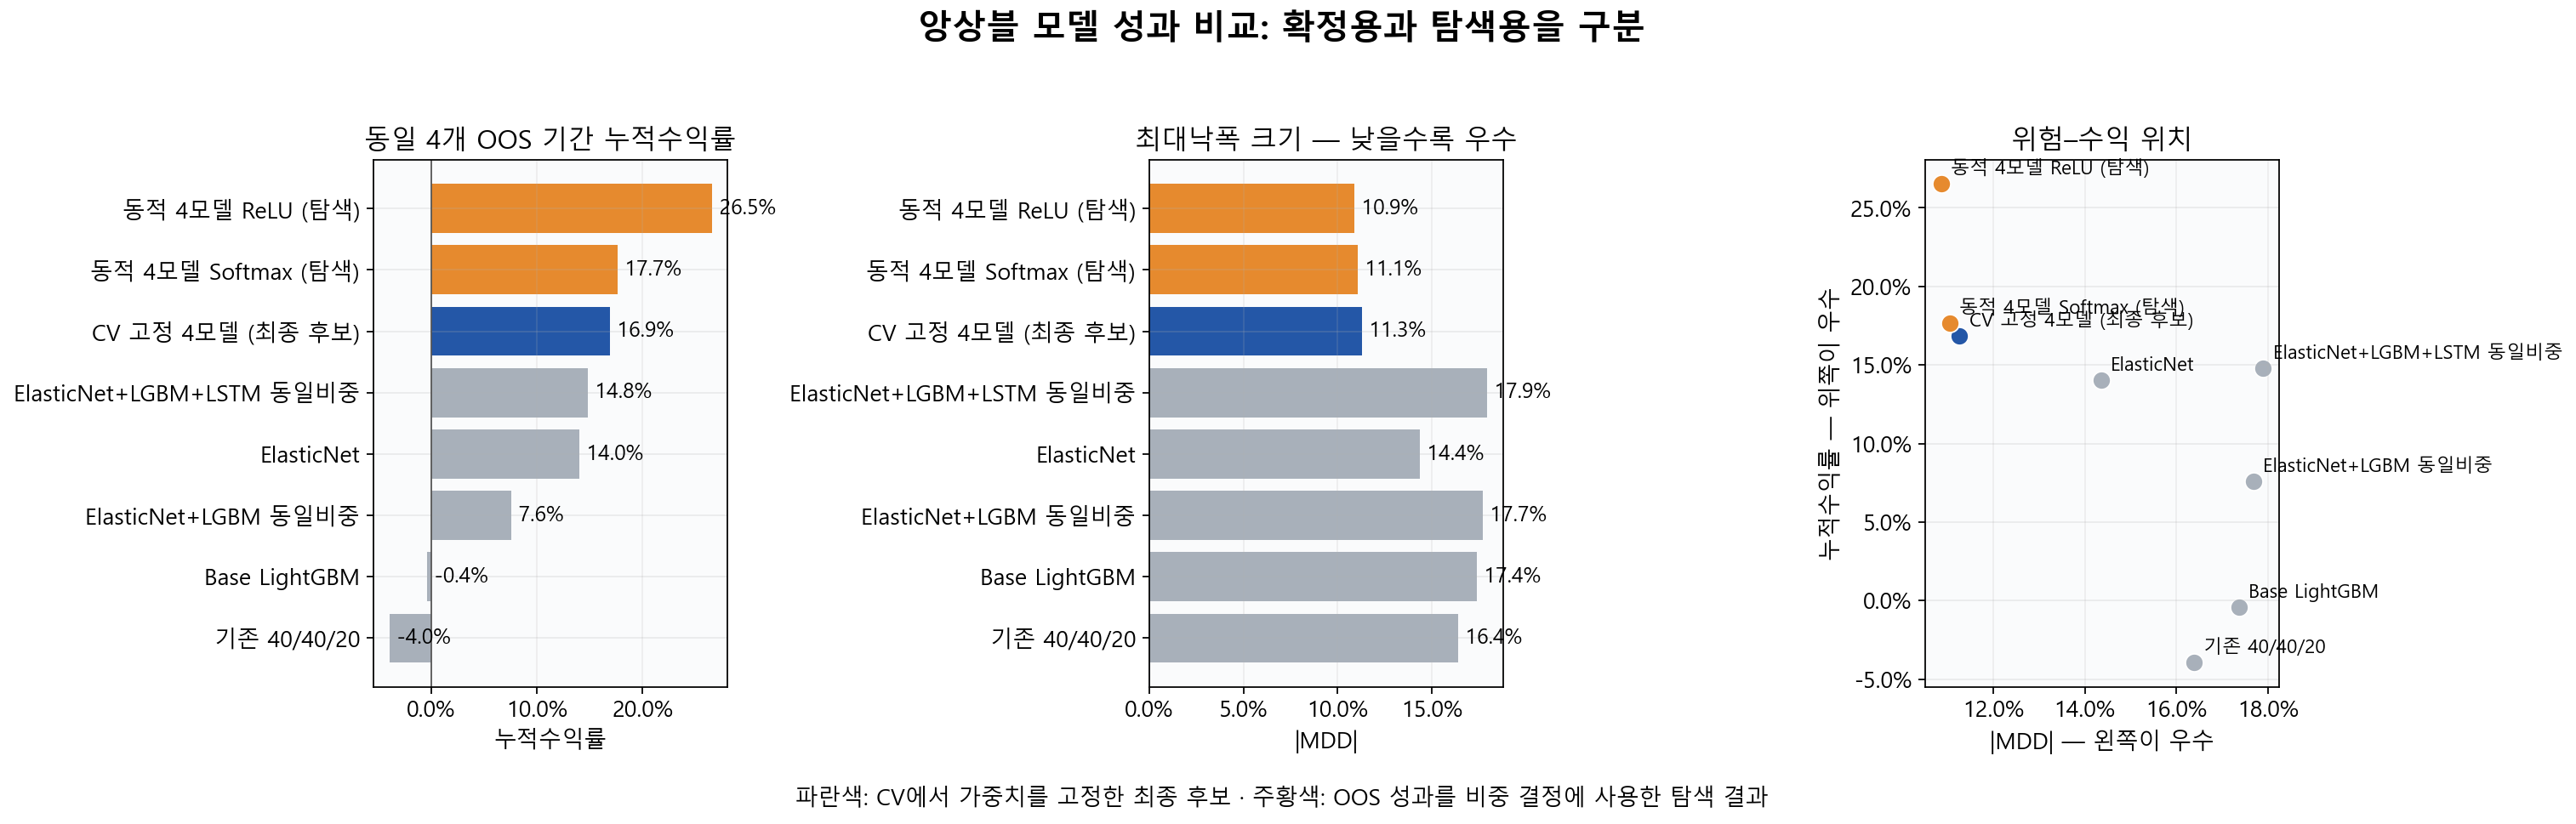

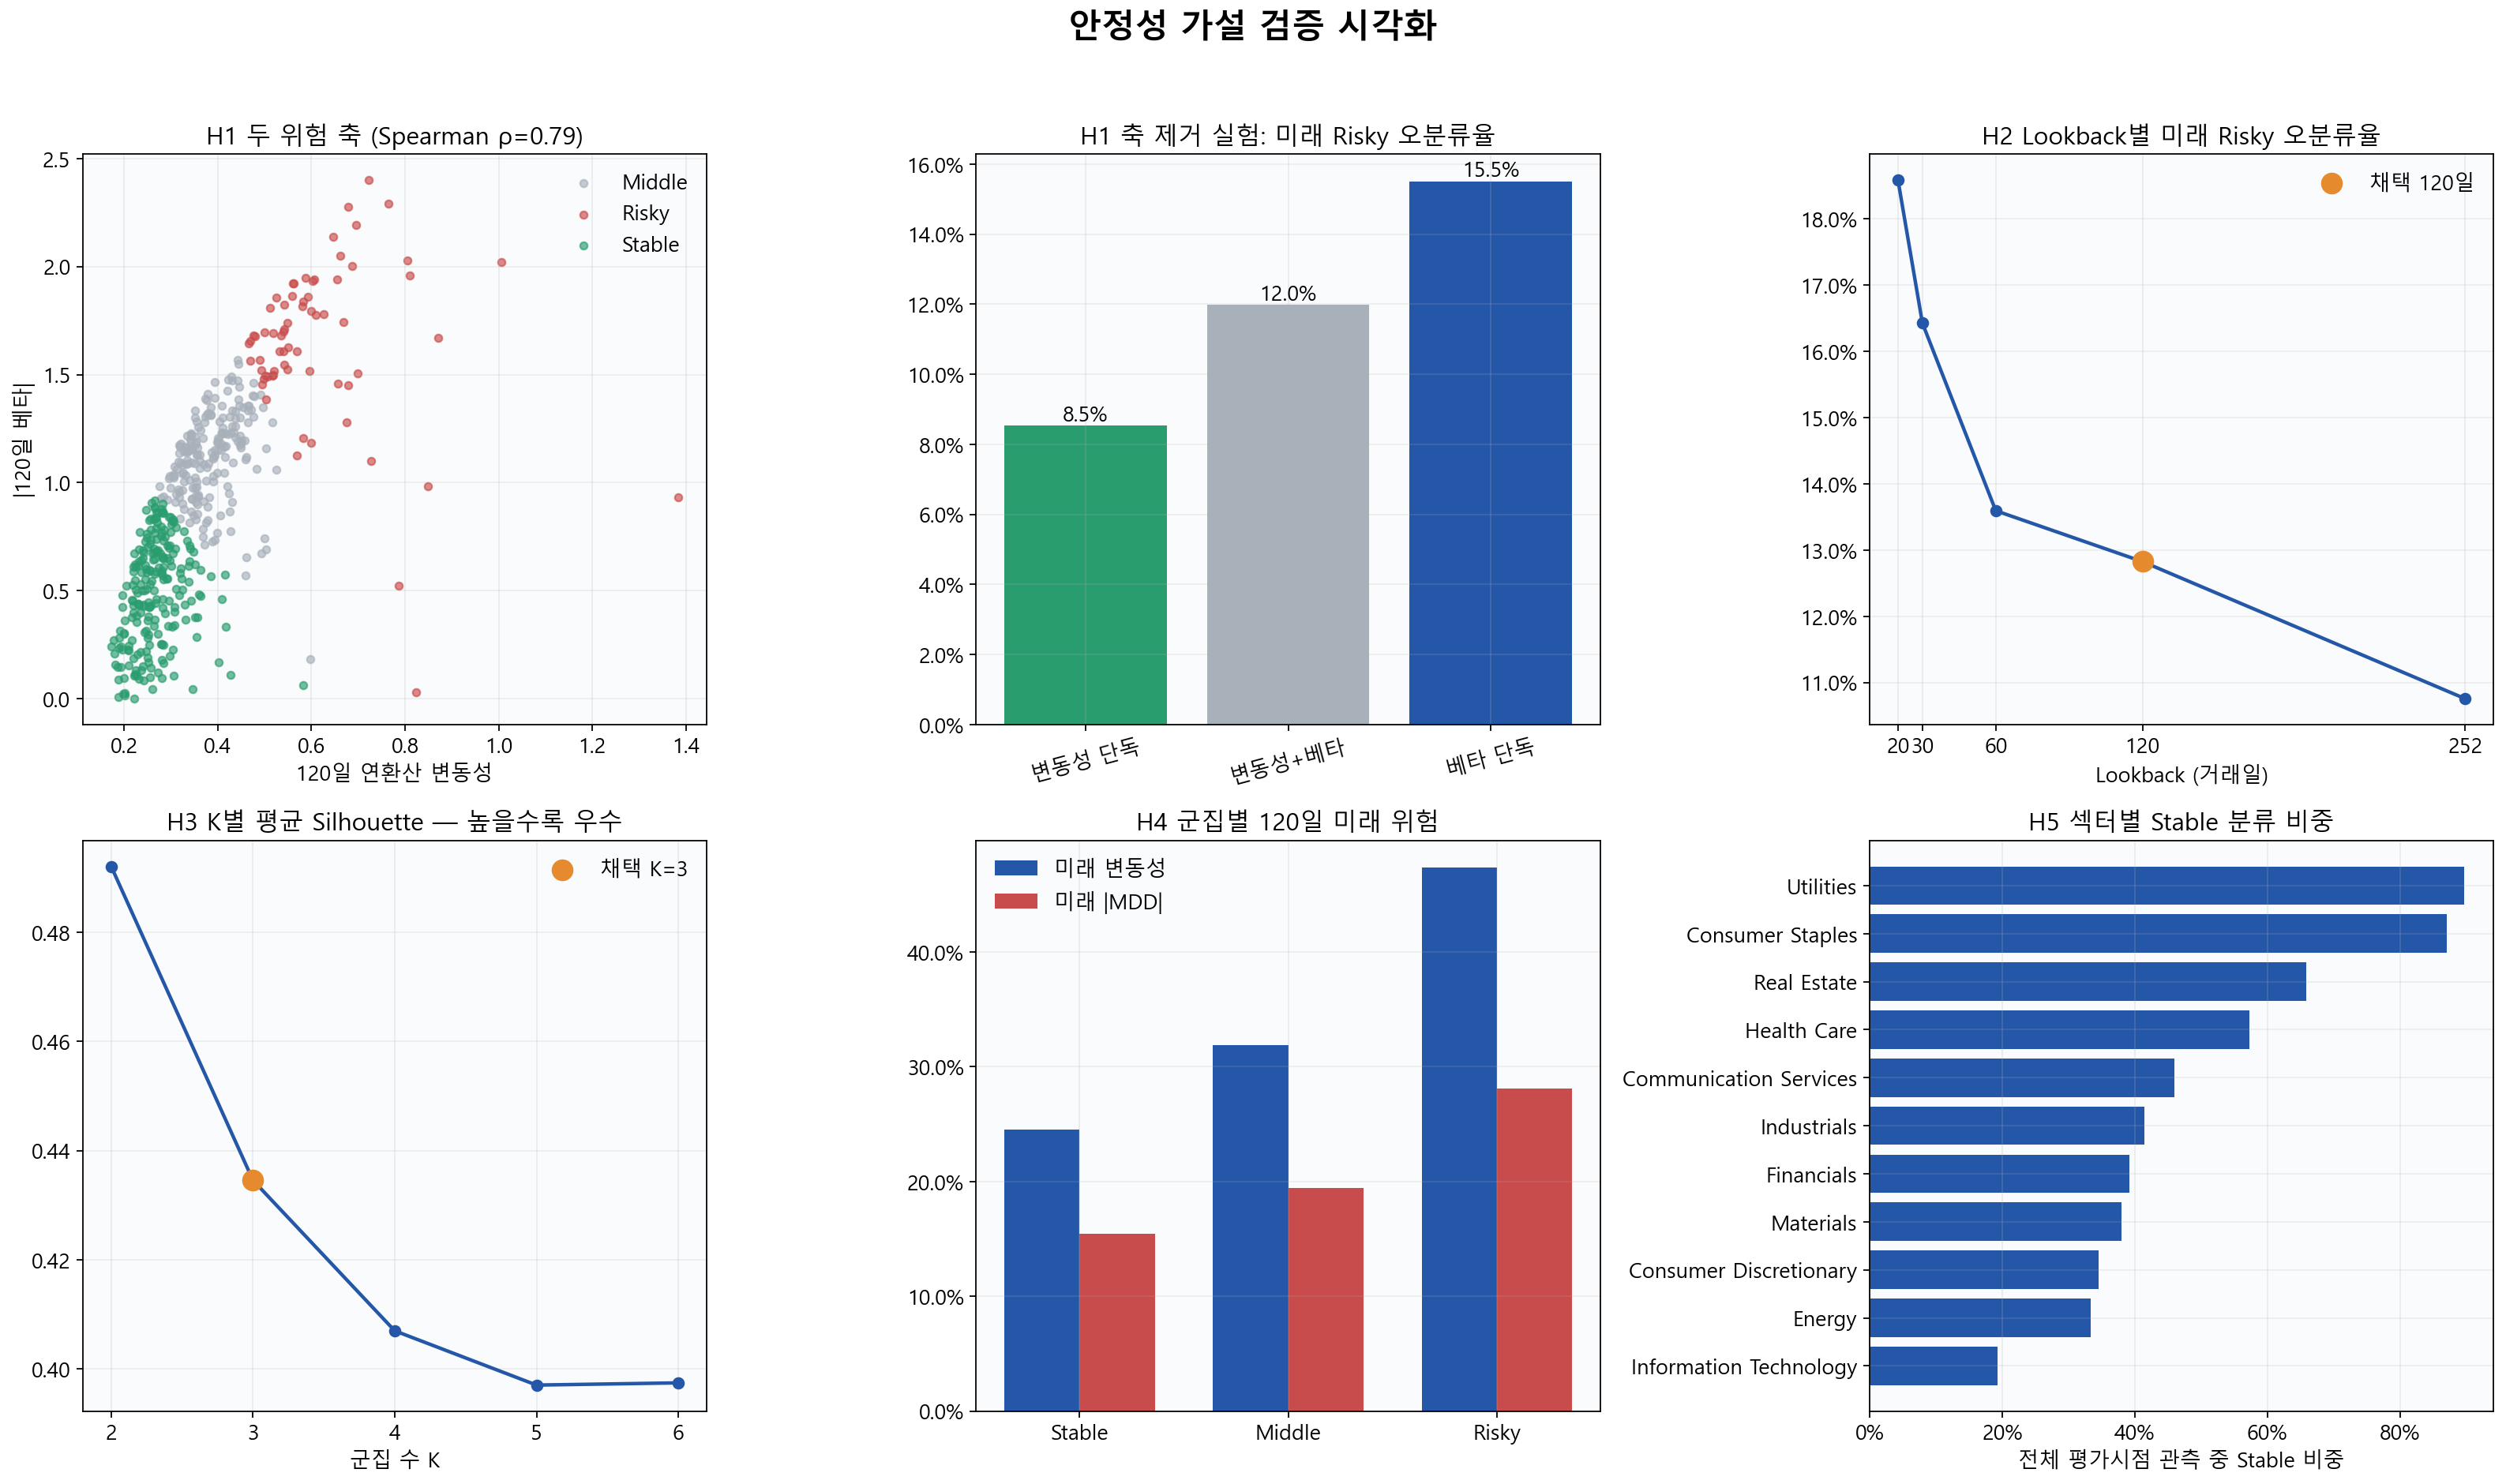

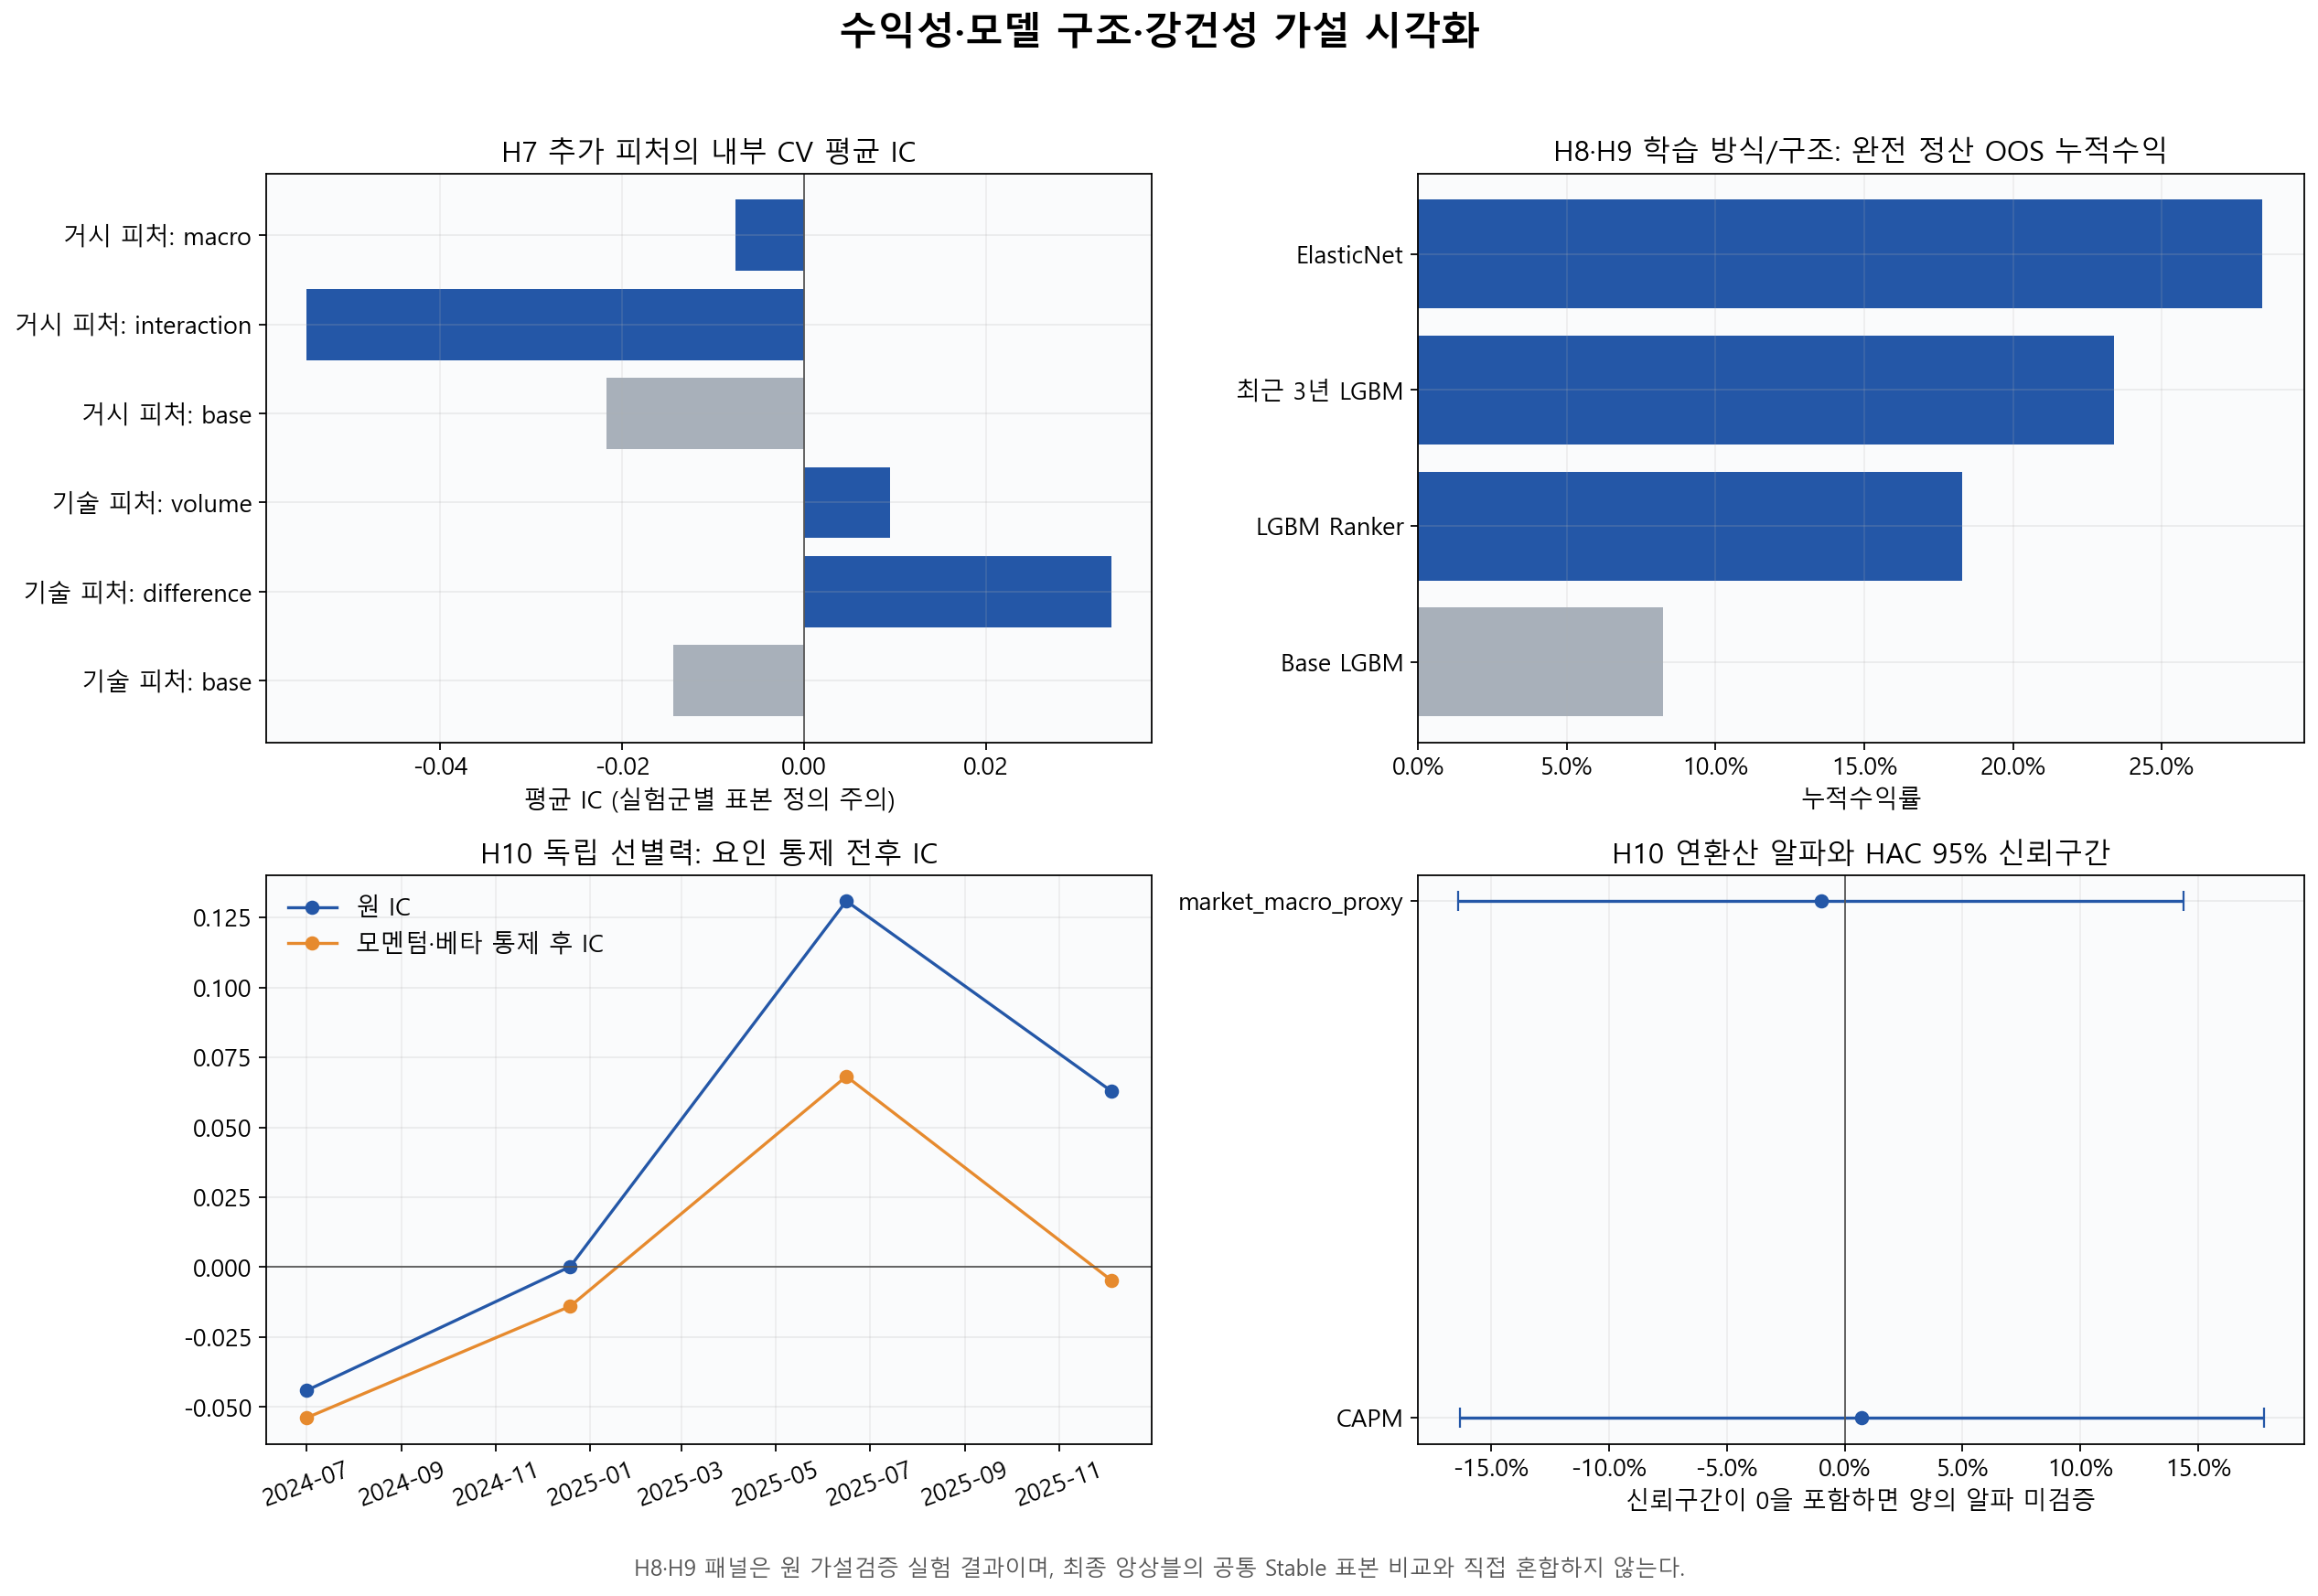

발표용 그래프·근거표 저장: C:\workspaces\middle\final\outputs\20260910T115732306787Z


In [66]:
from src import presentation_visuals as presentation_module
importlib.reload(presentation_module)
from IPython.display import Image

if 'FINAL_RUN_DIR' not in globals():
    raise RuntimeError('최종 후보 비교 셀을 먼저 실행하세요.')
alpha_for_visuals = ALPHA_SUMMARY if 'ALPHA_SUMMARY' in globals() else None
PRESENTATION_TABLES = presentation_module.build_presentation_visuals(
    run_dir=FINAL_RUN_DIR,
    project_root=PROJECT_ROOT,
    experiment_tables=TABLES,
    alpha_summary=alpha_for_visuals,
)
TABLES.update(PRESENTATION_TABLES)
show('가설별 시각화 범위와 한계', PRESENTATION_TABLES['presentation_hypothesis_coverage'])
for filename in [
    'presentation_cv_locked_final_model.png',
    'presentation_ensemble_comparison.png',
    'presentation_stability_hypotheses.png',
    'presentation_research_hypotheses.png',
]:
    path = Path(FINAL_RUN_DIR) / 'figures' / filename
    display(Image(filename=str(path)))
print('발표용 그래프·근거표 저장:', Path(FINAL_RUN_DIR))
_ = gc.collect()


### 그래프 해석 원칙

- **H1:** 변동성과 절대 베타가 완전히 같은 축은 아니어서 다면적 위험 설명에는 의미가 있다. 다만 축 제거 실험에서 결합형의 미래 Risky 오분류율이 변동성 단독보다 낮아야 '선별력이 개선됐다'고 말할 수 있다. 현재 결과는 결합의 설명적 의미는 보여도 변동성 단독 대비 성능 우월성을 지지하지 않는다.
- **H2:** 120일은 동일한 20개 평가시점을 확보한 20·30·60·120일 중 오분류율이 가장 낮고 미래 MDD도 가장 양호해 실무적 선택 근거가 있다. 252일은 오분류율이 더 낮지만 평가시점이 18개뿐이므로 '120일이 모든 후보 중 통계적으로 최적'이라고 단정하지 않는다.
- **H3:** 평균 Silhouette는 K=2가 K=3보다 높다. 따라서 K=3은 Stable/Middle/Risky의 해석 가능성과 후속 분석 편의를 위한 정책 선택이며, 군집 품질 지표만으로 최적이라고 말할 수 없다.
- **H4:** Stable 군은 Risky 군보다 이후 120일 변동성·낙폭·미래 Risky 비율이 모두 낮게 관찰된다. 이는 현재 안정군 정의에서 가장 직접적으로 지지되는 가설이다.
- **H5:** 섹터별 Stable 비중 차이가 크게 나타나 섹터 편향은 관찰된다. 이는 편향의 존재를 보여주지만 원인이나 산업중립 전략의 우월성을 증명하지는 않는다.
- **H7:** 기술 피처 차분·거래량 및 거시 피처의 내부 CV IC를 각각의 공통 표본 안에서 비교한다. 기술 피처와 거시 피처 실험은 표본 정의가 달라 절대 IC 높이를 서로 직접 순위화하지 않는다.
- **H8·H9:** 완전 정산된 모델만 단독 OOS 그래프에 포함한다. MLP와 LSTM의 단독 결과는 3/4 기간만 정산된 기존 표에서는 제외하지만, -50% 미정산 가정을 적용한 최종 4모델 앙상블 성과에는 포함된다.
- **H10:** 원 IC와 요인 통제 후 IC의 차이는 독립 선별력의 약화를 보여주며, CAPM·거시 프록시 알파의 95% 신뢰구간이 0을 포함하므로 통계적으로 양의 알파가 검증됐다고 표현하지 않는다.

모든 OOS 성과는 네 개의 120거래일 평가구간과 미정산 종목 -50% 가정을 전제로 한다. 주황색 동적 앙상블은 OOS 정보를 사용한 탐색 결과이므로, 파란색 CV 고정 앙상블과 동일한 확증 수준으로 발표하지 않는다.
